# 📓 Cas d'usage IA — [TITRE DU PROJET]

**Auteur·e** : `Joelle Germanos`  
**Promo** : Dev-id — Parcours 2 (Pros IT)  
**Date début** : `JJ/MM/AAAA`  
**Dernière mise à jour** : `JJ/MM/AAAA`


## 0. Imports & configuration

🎯 Centraliser les imports et la configuration reproductible.  
💡 `random_state=42` partout, `pd.set_option` pour l'affichage si besoin.  
⚠️ Ne pas importer en cours de notebook : tout ici.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#à vérifier 
import geopandas as gpd

from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    recall_score, make_scorer
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Python :", sys.version.split()[0])
print("Pandas :", pd.__version__)

Python : 3.12.10
Pandas : 2.2.2


## 0.5 Traçabilité de la session

🎯 Documenter ce qui rend l'analyse **reproductible** par toi (sur un autre poste) ou par un collègue qui reprendrait le notebook dans 3 mois.

💡 Trois choses à figer :
- la **version du dataset** (source, date d'extraction, hash si possible),
- les **versions des libs** (cf. `requirements.txt` du repo associé, ou `pip freeze`),
- le **commit Git** du repo associé au notebook.

⚠️ Sans ces 3 éléments, ton analyse n'est pas reproductible. C'est un attendu pro fort, et c'est noté en certif.

In [2]:
import sys
import subprocess
from datetime import datetime

# --- Métadonnées du dataset ---
DATASET_NAME = "dataset_trajectoire_emploi"          # ex: "UCI Student Performance" ou "FastIA maintenance v1"
DATASET_SOURCE = "../data/dataset_trajectoire_emploi.csv"        # URL, chemin, ou contact si fourni par le client
DATASET_VERSION = "YYYY-MM-DD"  # date d'extraction OU version explicite

# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME} (source={DATASET_SOURCE}, version={DATASET_VERSION})")

Date session : 2026-09-28T18:44
Python       : 3.12.10
NumPy        : 2.2.6
Pandas       : 2.2.2
Git commit   : 29542d0
Dataset      : dataset_trajectoire_emploi (source=../data/dataset_trajectoire_emploi.csv, version=YYYY-MM-DD)


---
## 1. Cadrage métier & problème

**Compétences** : C1 (jeux de données pour besoin métier), C2 (risques éthiques), C4 (choix modèle pertinent)

🎯 **Avant d'écrire la moindre ligne de code**, tu dois pouvoir répondre à :

- Qui est le client ? Quel est son besoin métier réel ?
- Qui sont les bénéficiaires directs et indirects de la solution ?
- Quel type de tâche IA (classification, régression, clustering, génération…) ?
- Quels critères de succès **côté métier** (pas seulement côté modèle) ?
- Quels risques éthiques, réglementaires, de biais sont pressentis ?
- Quel cadre réglementaire s'applique (RGPD, AI Act, secteur régulé) ?

⚠️ Une formulation floue du problème = un projet qui dérive. Sois précis·e.

### 1.1 Contexte client

*[Décris en 5-10 lignes le client, son secteur, le problème métier qu'il rencontre, ce qui motive le recours à l'IA.]*

### 1.2 Énoncé du problème IA

*[Reformule en termes de tâche IA : « prédire X à partir de Y », « classer Z en N catégories », etc.]*

### 1.3 Bénéficiaires & impacts

*[Direct : qui utilise la solution ? Indirect : qui subit les conséquences des prédictions ?]*

### 1.4 Critères de succès

⚠️ La cible **avant EDA** est ce que demande le client. La cible **révisée après EDA** tient compte des contraintes réelles de la donnée. Les deux doivent apparaître.

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | *[ex: réduire de X% le délai de Y]* | *[ex: -20%]* | *[à compléter après §3]* | *[ex: cible irréaliste vu le déséquilibre des classes]* |
| Modèle | *[ex: F1-score classe minoritaire]* | *[ex: ≥ 0.75]* | *[à compléter]* | … |
| Opérationnel | *[ex: temps de réponse API]* | *[ex: < 200 ms]* | *[à compléter]* | … |

### 1.5 Risques éthiques & réglementaires anticipés

*[Variables sensibles, biais possibles, RGPD, AI Act, droit sectoriel.]*

### 1.6 📝 Synthèse cadrage

*[3-5 lignes : le problème, la tâche IA retenue, le critère de succès dominant, le principal risque éthique identifié.]*

---
## 2. Identification & acquisition des données

**Compétences** : C1 (identifier un jeu de données pertinent et cohérent)

🎯 Décrire **ce qu'on a, où on l'a trouvé, et ce que ça contient**, avant tout traitement.

💡 Datasheet for datasets (Gebru et al., 2018) = bonne référence pour structurer.  
⚠️ Ne saute pas la traçabilité : provenance, version, date d'extraction, licence (cf §0.5).

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| *gence nationale de l'emploi* | *CSV* | *2 500 lignes × 10 colonnes* | *csv* | *lecture seule* | *inconnue* |


#### 2.2 Chargement

In [3]:
DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "dataset_trajectoire_emploi.csv"

if RAW_PATH is None:
    raise FileNotFoundError("CSV introuvable. Vérifier le chemin ../data/dataset_trajectoire_emploi.csv")

df = pd.read_csv(RAW_PATH)

print(f"Fichier : {RAW_PATH}")
print("Dimensions :", df.shape)
print("Variables :", df.columns.tolist())

Fichier : ..\data\dataset_trajectoire_emploi.csv
Dimensions : (2500, 10)
Variables : ['usager_id', 'age', 'niveau_diplome', 'anciennete_poste_ans', 'code_rome_vise', 'code_insee_commune', 'est_allocataire', 'nationalite_hors_ue', 'synthese_entretien', 'classe_retour_emploi']


### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `usager_id` | Identifiant unique du demandeur d'emploi | Catégoriel (identifiant) | 2500 valeurs uniques | ❌ | ⚠️ Identifiant : risque d'identification si croisé avec une autre source |
| `age` | Âge de l'usager en années | Numérique | 18 – 63 ans | ❌ | ✅ Critère de discrimination légale prohibé en droit français (art. 225-1 du Code pénal)|
| `niveau_diplome` | Plus haut niveau de diplôme obtenu | Catégoriel ordinal | Sans diplôme / Bac / Bac+2 / Bac+5 | ❌ | ⚠️ Proxy socio-économique |
| `anciennete_poste_ans` | Nombre d'années d'expérience dans le dernier emploi occupé | Numérique | 0 – 22,6 ans | ❌ | ❌ |
| `code_rome_vise` | Code à 5 caractères du Répertoire Opérationnel des Métiers et des Emplois ciblé par l'usager | Catégoriel nominal, haute cardinalité | 50 modalités (ex: D1503, G1302…) | ❌ | ❌ |
| `code_insee_commune` | Code officiel géographique INSEE de la commune de résidence | Catégoriel nominal, haute cardinalité | 2407 modalités / 2500 lignes (quasi-identifiant à cardinalité proche de 1:1) | ❌ | ⚠️ Proxy socio-économique et territorial|
| `est_allocataire` | Statut d'indemnisation de l'usager | Catégoriel binaire | 1 (Oui), 0 (Non) | ❌ | ❌ |
| `nationalite_hors_ue` | Nationalité hors Union Européenne | Catégoriel binaire | 1 = hors UE, 0 = UE | ❌ | ✅ Variable protégée |
| `synthese_entretien` | Texte libre contenant les notes textuelles du conseiller lors de l'entretien  | texte libre | 63–77 caractères | ❌ | ⚠️ Peut contenir des données sensibles non structurées - à vérifier |
| `classe_retour_emploi` | Classe de délai de retour à l'emploi constatée | Catégoriel (cible) | 0 : <6 mois  / 1 : 6-12 mois / 2 : >12 mois | ✅ | ❌ |



### 2.4 📝 Synthèse acquisition

*[Origine, volumétrie, qualité apparente, variables sensibles repérées dès cette étape.]*

**Origine**
Le jeu de données provient de l'agence nationale de l'emploi. Il s'agit vraisemblablement d'un extrait de dossiers administratifs de suivi individuel, combinant des données déclaratives (diplôme, ancienneté) et des données saisies par un tiers professionnel (synthèse d'entretien, code ROME visé).

**Volumétrie**
2500 lignes (usagers), 10 variables. Le jeu est de taille modeste, ce qui appelle une vigilance particulière sur la robustesse statistique du futur modèle (risque de surapprentissage, faible représentativité de certaines sous-populations) — d'autant plus que la cible classe_retour_emploi comporte 3 classes.

**Qualité apparente**
Cohérence globale correcte : types de variables bien identifiables, plages de valeurs plausibles (âge 18–63 ans, ancienneté 0–22,6 ans).
Un point d'attention : code_insee_commune affiche 2407 modalités pour 2500 lignes, ce qui suggère soit une forte dispersion géographique réelle, soit un niveau de granularité inadapté à l'usage statistique.
Absence apparente de documentation sur les valeurs manquantes, la méthode de collecte, et la période de constitution du jeu.
La variable texte synthese_entretien a une longueur très resserrée (63–77 caractères), ce qui interroge sur sa richesse informative réelle (probablement un champ tronqué ou un résumé automatique plutôt qu'une note libre complète).

**Variables sensibles repérées dès cette étape**
- `usager_id` : identifiant direct, risque de ré-identification par croisement (à écarter des features).
- `nationalite_hors_ue` : variable sensible explicite, critère de discrimination protégé, et à la frontière de la notion d'"origine" au sens de l'art. 9 RGPD — variable la plus - sensible juridiquement du jeu de données.
- `age` : critère de discrimination protégé par le droit français (art. 225-1 du Code pénal) — ne relève pas de l'art. 9 RGPD à proprement parler, mais reste un critère à traiter avec précaution dans un modèle décisionnel.
- `code_insee_commune` : quasi-identifiant à très haute cardinalité (proxy territorial et socio-économique), risque d'effet mosaïque en combinaison avec d'autres variables.
- `niveau_diplome`: proxys socio-économiques.
- `synthese_entretien` : texte libre pouvant contenir des données sensibles non structurées (santé, situation familiale, nationalité).

---
## 3. Exploration & analyse des données (EDA)

**Compétences** : C2 (risques éthiques détectables dans la donnée), C3 (préparation des données)

### 3.1 Premier coup d'œil

In [4]:
display(df.head())
display(df.info())
display(df.describe(include="all").T)
print("Colonnes du dataset :")
print(df.columns.tolist())

,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   object 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 195.4+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
usager_id,2500,2500,ID_2499,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2378.0,NaN,NaN,NaN,40.566442,13.225242,18.0,29.0,41.0,52.0,63.0
niveau_diplome,2416,4,Bac,966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anciennete_poste_ans,2500.0,NaN,NaN,NaN,2.9716,2.979548,0.0,0.8,2.0,4.1,22.6
code_rome_vise,2500,50,H1206,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_insee_commune,2500,2407,46283,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
est_allocataire,2456.0,NaN,NaN,NaN,0.595684,0.490859,0.0,0.0,1.0,1.0,1.0
nationalite_hors_ue,2500.0,NaN,NaN,NaN,0.118,0.322673,0.0,0.0,0.0,0.0,1.0
synthese_entretien,2419,9,Compétences à réactualiser sur les outils numé...,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classe_retour_emploi,2500.0,NaN,NaN,NaN,0.8064,0.719671,0.0,0.0,1.0,1.0,2.0


Colonnes du dataset :
['usager_id', 'age', 'niveau_diplome', 'anciennete_poste_ans', 'code_rome_vise', 'code_insee_commune', 'est_allocataire', 'nationalite_hors_ue', 'synthese_entretien', 'classe_retour_emploi']


### 3.2 Qualité des données 

#### 3.2.1 Qualité des données : manquants et doublons

In [5]:
missing = pd.DataFrame({
    "Valeurs manquantes": df.isna().sum(),
    "Pourcentage (%)": (100 * df.isna().mean()).round(2).astype(str) + " %"
}).sort_values("Valeurs manquantes", ascending=False)

display(missing)

print("Nombre de doublons :", df.duplicated().sum())
print("Nombre d'identifiants usager dupliqués :", df["usager_id"].duplicated().sum())

,Valeurs manquantes,Pourcentage (%)
age,122,4.88 %
niveau_diplome,84,3.36 %
synthese_entretien,81,3.24 %
est_allocataire,44,1.76 %
usager_id,0,0.0 %
anciennete_poste_ans,0,0.0 %
code_insee_commune,0,0.0 %
code_rome_vise,0,0.0 %
nationalite_hors_ue,0,0.0 %
classe_retour_emploi,0,0.0 %


Nombre de doublons : 0
Nombre d'identifiants usager dupliqués : 0


#### 3.2.2 Détection des valeurs aberrantes (méthode IQR) sur les variables numériques

In [6]:
def detect_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

for col in ["age", "anciennete_poste_ans"]:
    outliers, lower, upper = detect_outliers_iqr(df[col].dropna())
    print(f"\n--- {col} ---")
    print(f"Bornes IQR : [{lower:.2f}, {upper:.2f}]")
    print(f"Nombre de valeurs : {len(outliers)} ({len(outliers)/df[col].notna().sum()*100:.2f} %)")
    if len(outliers) > 0:
        print(outliers.sort_values(ascending=False).head(10))


--- age ---
Bornes IQR : [-5.50, 86.50]
Nombre de valeurs : 0 (0.00 %)

--- anciennete_poste_ans ---
Bornes IQR : [-4.15, 9.05]
Nombre de valeurs : 126 (5.04 %)
1875    22.6
1540    22.0
1075    20.2
2277    19.6
8       18.3
1313    18.2
311     17.4
2203    17.3
214     17.0
1582    16.7
Name: anciennete_poste_ans, dtype: float64


📝 **Synthèse(§3.2)**

- Valeurs manquantes modérées sur 4 variables sur 10 (`age` ~4,9 %, `niveau_diplome` ~3,4 %,
  `est_allocataire` ~1,8 %, `synthese_entretien` ~3,2 %) — taux ne remettant pas en cause
  l'exploitabilité du dataset, mais nécessitant une stratégie d'imputation explicite en **§4**.
- Aucun doublon exact détecté, ni sur l'ensemble des colonnes ni sur `usager_id`.
- La détection IQR ne révèle aucun outlier sur `age` — les valeurs extrêmes (18-63 ans) restent dans des plages parfaitement plausibles.
Sur `anciennete_poste_ans`, en revanche, la détection IQR révèle un nombre important d'outliers au-delà de ~9 ans (jusqu'à 22,6 ans d'ancienneté)
126 observations sont identifiées comme valeurs extrêmes selon la règle IQR. Elles ne sont pas supprimées à ce stade, car elles peuvent correspondre à des situations réelles et devront être examinées au regard des contraintes métier.

### 3.3 Distribution des variables

#### 3.3.1 Distribution des variables numériques

Âge :


count    2378.000000
mean       40.566442
std        13.225242
min        18.000000
25%        29.000000
50%        41.000000
75%        52.000000
max        63.000000
Name: age, dtype: float64


Ancienneté :


count    2500.000000
mean        2.971600
std         2.979548
min         0.000000
25%         0.800000
50%         2.000000
75%         4.100000
max        22.600000
Name: anciennete_poste_ans, dtype: float64

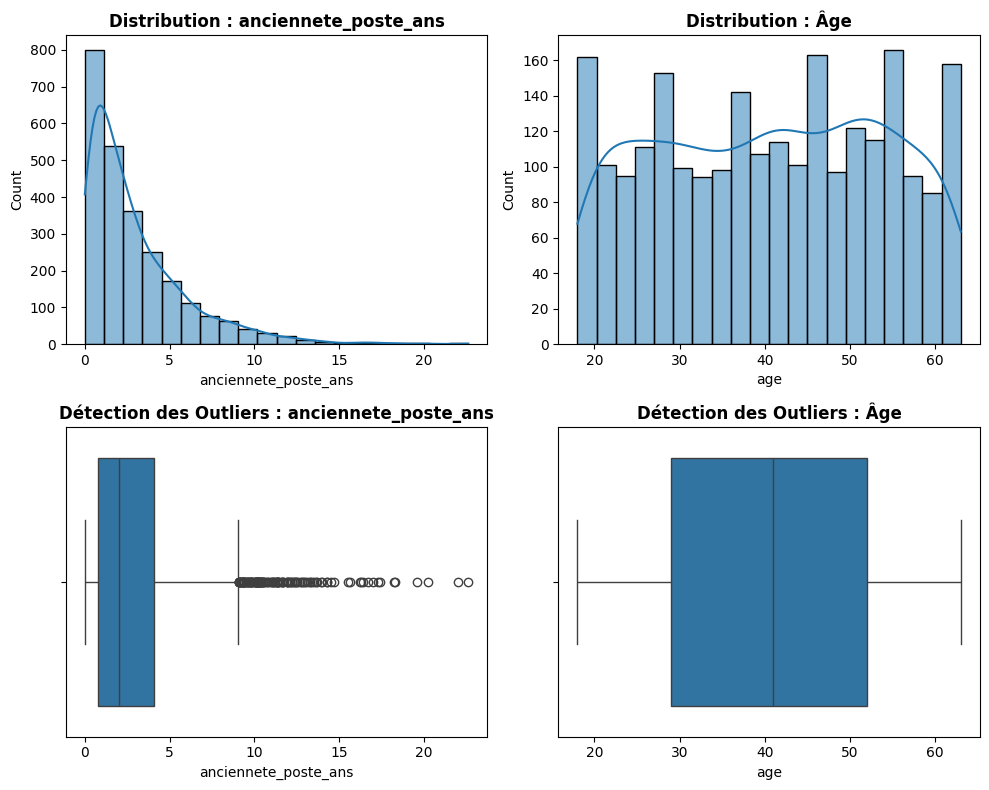

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].set_title("Distribution : anciennete_poste_ans", fontsize=12, fontweight='bold')
sns.histplot(data=df, x="anciennete_poste_ans", bins=20, kde=True, ax=axes[0, 0])

axes[0, 1].set_title("Distribution : Âge", fontsize=12, fontweight='bold')
sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[0, 1])

axes[1, 0].set_title("Détection des Outliers : anciennete_poste_ans", fontsize=12, fontweight='bold')
sns.boxplot(data=df, x="anciennete_poste_ans", ax=axes[1, 0])

axes[1, 1].set_title("Détection des Outliers : Âge", fontsize=12, fontweight='bold')
sns.boxplot(data=df, x="age", ax=axes[1, 1])

plt.tight_layout()

print("Âge :")
display(df["age"].describe())
print("\nAncienneté :")
display(df["anciennete_poste_ans"].describe())

#### 3.3.2 Analyse des variables catégorielles

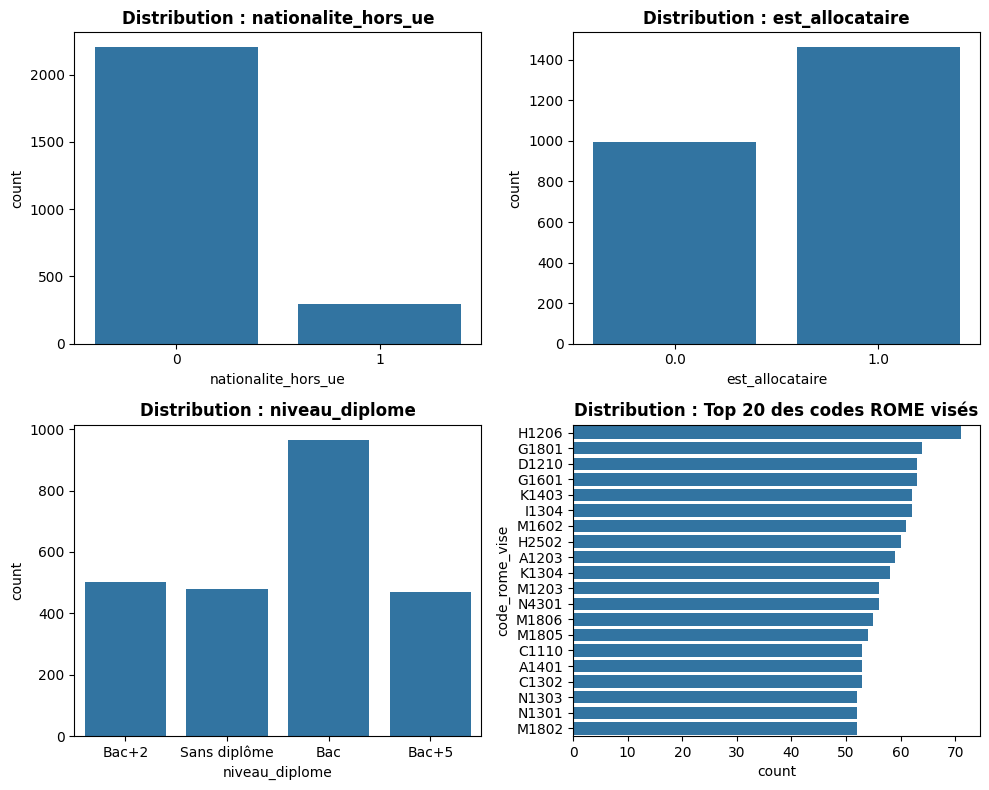

Répartition nationalite_hors_ue :
nationalite_hors_ue
0    0.882
1    0.118
Name: proportion, dtype: float64


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].set_title("Distribution : nationalite_hors_ue", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="nationalite_hors_ue", ax=axes[0, 0])

axes[0, 1].set_title("Distribution : est_allocataire", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="est_allocataire", ax=axes[0, 1])

axes[1, 0].set_title("Distribution : niveau_diplome", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="niveau_diplome", ax=axes[1, 0])

top10_rome = df["code_rome_vise"].value_counts().head(20).index
axes[1, 1].set_title("Distribution : Top 20 des codes ROME visés", fontsize=12, fontweight="bold")
sns.countplot(data=df, y="code_rome_vise", order=top10_rome, ax=axes[1, 1])

plt.tight_layout()
plt.show()

print("Répartition nationalite_hors_ue :")
print(df["nationalite_hors_ue"].value_counts(normalize=True).round(3))

#### 3.3.3 Analyse de la variable textuelle

In [9]:
# Échantillon à l'œil nu
print("\nÉchantillon de 10 synthèses d'entretien :")
for texte in df["synthese_entretien"].dropna().sample(10, random_state=RANDOM_STATE):
    print("-", texte)


Échantillon de 10 synthèses d'entretien :
- Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.
- Candidat très dynamique, mobilité nationale validée. Projet clair.
- Excellente présentation, compétences techniques à jour. Reprise rapide visée.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.
- Projet de reconversion à affiner. Besoin d'une formation complémentaire.
- Perte de confiance importante. Risque d'exclusion, barrière de la langue.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.
- Projet de reconversion à affiner. Besoin d'une formation complémentaire.
- Problème ponctuel de mobilité géographique. Zone mal desservie.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.


In [10]:
# Valeurs manquantes / vides
n_na = df["synthese_entretien"].isna().sum()
n_vide = (df["synthese_entretien"].fillna("").str.strip() == "").sum()
print(f"Valeurs manquantes : {n_na} ({n_na/len(df)*100:.1f} %)")
print(f"Chaînes vides ou blanches : {n_vide}")

Valeurs manquantes : 81 (3.2 %)
Chaînes vides ou blanches : 81


Textes uniques : 9
Doublons de texte (hors vides) : 2410



synthese_entretien
Compétences à réactualiser sur les outils numériques. Motivation correcte.       338
Problème ponctuel de mobilité géographique. Zone mal desservie.                  334
Profil autonome, recherche active, aucun frein périphérique identifié.           300
Projet de reconversion à affiner. Besoin d'une formation complémentaire.         275
Excellente présentation, compétences techniques à jour. Reprise rapide visée.    272
Candidat très dynamique, mobilité nationale validée. Projet clair.               259
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.     227
Perte de confiance importante. Risque d'exclusion, barrière de la langue.        212
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.       202
NaN                                                                               81
Name: count, dtype: int64

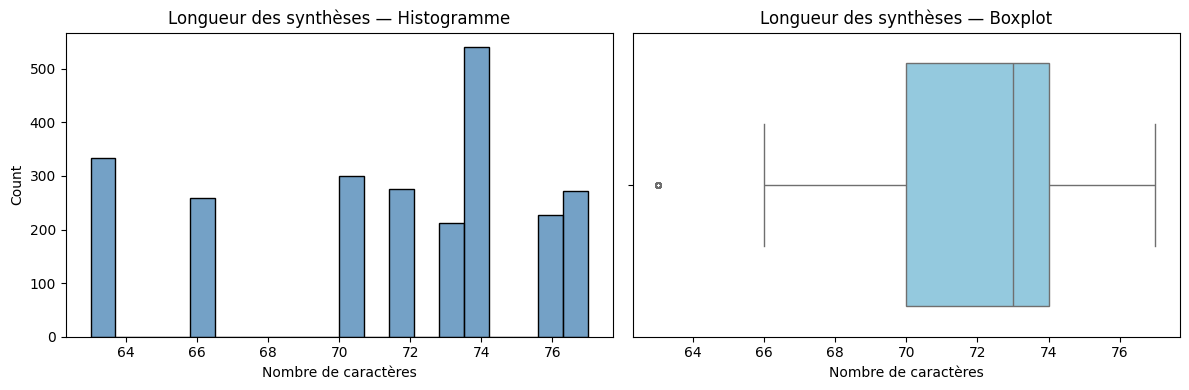

count    2419.000000
mean       71.338570
std         4.516476
min        63.000000
25%        70.000000
50%        73.000000
75%        74.000000
max        77.000000
Name: texte_len, dtype: float64


In [11]:
# Doublons
n_unique_text = df["synthese_entretien"].nunique(dropna=True)
n_dup_text = df["synthese_entretien"].dropna().duplicated().sum()

print(f"Textes uniques : {n_unique_text}")
print(f"Doublons de texte (hors vides) : {n_dup_text}\n")
display(df["synthese_entretien"].value_counts(dropna=False).head(15))

df["texte_len"] = df["synthese_entretien"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["texte_len"].dropna(), bins=20, ax=axes[0], color="steelblue")
axes[0].set_title("Longueur des synthèses — Histogramme")
axes[0].set_xlabel("Nombre de caractères")

sns.boxplot(x=df["texte_len"].dropna(), ax=axes[1], color="skyblue", fliersize=4)
axes[1].set_title("Longueur des synthèses — Boxplot")
axes[1].set_xlabel("Nombre de caractères")

plt.tight_layout()
plt.show()

print(df["texte_len"].describe())

#### 3.3.4 Exploration de regroupements potentiels

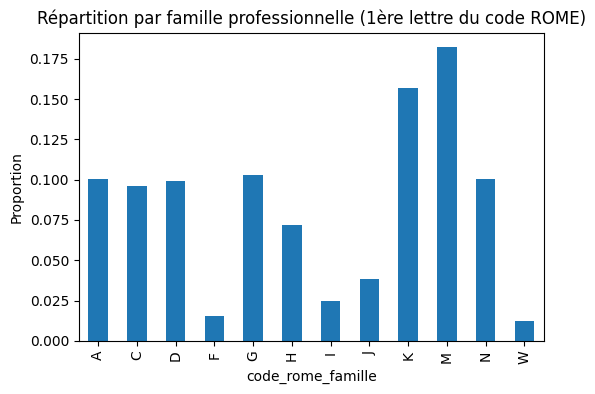

ROME uniques      : 50
Familles ROME     : 12


In [12]:
# Répartition par famille professionnelle (1ère lettre du code ROME)
df["code_rome_famille"] = df["code_rome_vise"].str[0]

# Visualisation complémentaire : répartition par famille
plt.figure(figsize=(6, 4))
df["code_rome_famille"].value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("Répartition par famille professionnelle (1ère lettre du code ROME)")
plt.ylabel("Proportion")
plt.show()
print("ROME uniques      :", df["code_rome_vise"].nunique())
print("Familles ROME     :", df["code_rome_famille"].nunique())

In [13]:
df["groupe_age"] = pd.cut(
    df["age"], bins=[0, 30, 50, 100],
    labels=["<30", "30-50", "50+"]
)

distribution = df["groupe_age"].value_counts().reindex(["<30", "30-50", "50+"])
distribution_pct = df["groupe_age"].value_counts(normalize=True).reindex(["<30", "30-50", "50+"]) * 100

tableau = pd.DataFrame({
    "effectif": distribution,
    "pourcentage": distribution_pct.round(1)
})
print(tableau)

            effectif  pourcentage
groupe_age                       
<30              671         28.2
30-50           1032         43.4
50+              675         28.4


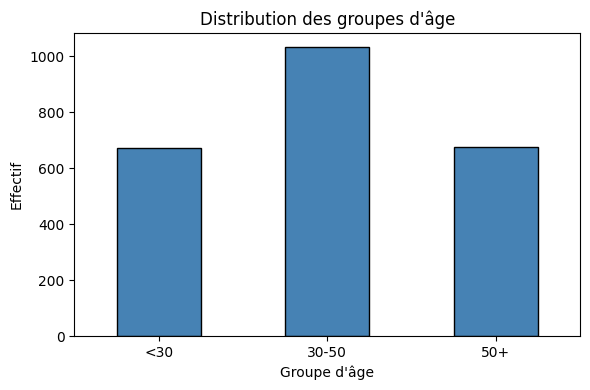

In [14]:
ordre = ["<30", "30-50", "50+"]
distribution = df["groupe_age"].value_counts().reindex(ordre)

plt.figure(figsize=(6, 4))
distribution.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribution des groupes d'âge")
plt.xlabel("Groupe d'âge")
plt.ylabel("Effectif")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Nombre de départements     : 96


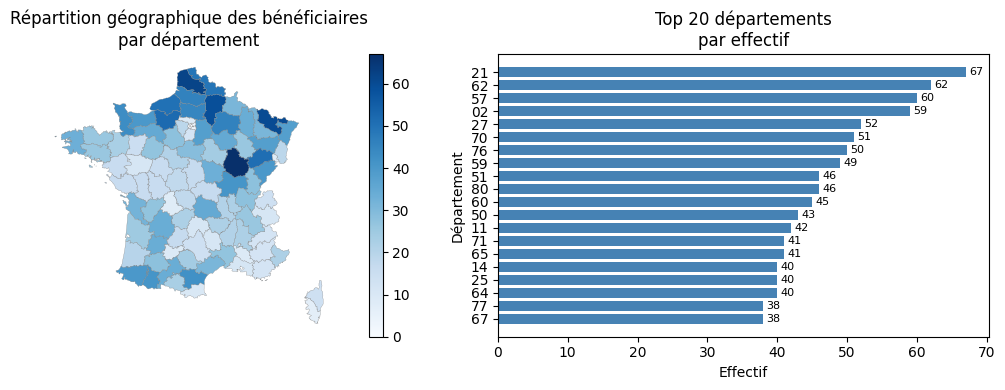

In [15]:
# Carte de répartition géographique : département + Top 20

# Comme code_insee_commune contient généralement les 5 chiffres INSEE
df["code_insee_commune"] = df["code_insee_commune"].astype(str).str.zfill(5)
df["departement"] = df["code_insee_commune"].astype(str).str[:2]
print("Nombre de départements     :", df["departement"].nunique())

# Correction DROM (codes à 3 chiffres tronqués par le str[:2])
is_drom = df["code_insee_commune"].astype(str).str.startswith("97")
df.loc[is_drom, "departement"] = df["code_insee_commune"].astype(str).str[:3]

# --- Effectifs par département ---
dep_counts = df["departement"].value_counts().reset_index()
dep_counts.columns = ["code", "effectif"]

# --- Chargement du fond de carte départemental ---
# !pip install geopandas
france = gpd.read_file("../data/departements.geojson")

# --- Carte : répartition par département ---
carte_dep = france.merge(dep_counts, left_on="code", right_on="code", how="left")
carte_dep["effectif"] = carte_dep["effectif"].fillna(0)

# --- Top 20 départements ---
top20 = dep_counts.sort_values("effectif", ascending=False).head(20)

# --- Affichage : carte + top 20 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.3, 1]})

carte_dep.plot(column="effectif", cmap="Blues", legend=True, ax=axes[0],
               edgecolor="grey", linewidth=0.2)
axes[0].set_title("Répartition géographique des bénéficiaires\npar département")
axes[0].axis("off")

axes[1].barh(top20["code"].astype(str), top20["effectif"], color="steelblue")
axes[1].invert_yaxis()  # le département le plus représenté en haut
axes[1].set_title("Top 20 départements\npar effectif")
axes[1].set_xlabel("Effectif")
axes[1].set_ylabel("Département")

for i, v in enumerate(top20["effectif"]):
    axes[1].text(v + 0.5, i, str(int(v)), va="center", fontsize=8)

plt.tight_layout()
plt.show()

📝 **Synthèse(§3.3)**

**Variables numériques :**
- `age`: Distribution quasi-uniforme entre 18 et 63 ans (moyenne 40,6, médiane 41), aucun outlier détecté (boxplot sans point aberrant). 
- `anciennete_poste_ans`: Distribution très asymétrique à droite (moyenne 2,97, médiane 2, max 22,6). Le boxplot révèle un nombre important d'outliers au-delà de ~9 ans.

**Variables catégorielles :**
- `nationalite_hors_ue` : fort déséquilibre, 88,2% / 11,8%. À anticiper pour tout test de fairness (le sous-groupe minoritaire sera statistiquement fragile, risque de sur- ou sous-performance du modèle sur cette population).
- `est_allocataire` : répartition plus équilibrée (~40% / 60%).
- `niveau_diplome` : "Bac" nettement dominant (~38%), les trois autres modalités (Sans diplôme, Bac+2, Bac+5) réparties de façon comparable (~19% chacune).
- `code_rome_vise` : 50 modalités / 12 familles professionnelles.
Le code H1206 domine nettement le top 20. La répartition par famille (1ère lettre du code ROME) montre une sur-représentation d'une ou deux familles (~15-17,5% contre ~10% pour les autres).
- `departement` : 96 départements représentés sur les 2500 usagers. Le département le plus représenté totalise ~67 usagers, sans concentration extrême (le top 20 s'échelonne de 38 à 67) — la répartition est diffuse, ce qui est plutôt rassurant pour le risque de ré-identification par la seule variable département (contrairement au niveau commune, beaucoup plus problématique).

**Variable textuelle :**
- `synthese_entretien` :
81 valeurs manquantes/vides (3,2%).
Sur les 2419 valeurs restantes, on ne compte que 9 textes uniques — malgré des doublons quasi systématiques (2410 doublons détectés).
La longueur est resserrée entre 63 et 77 caractères (cohérent avec un champ templaté, pas du texte libre spontané).
cette variable n'est pas du texte libre au sens propre, mais un champ à choix quasi-fermé (9 phrases-types récurrentes, ex. "Barrière de la langue", "Situation d'illettrisme numérique constatée", "Problème ponctuel de mobilité géographique").

**`groupe_age` : <30 ans = 28,2%, 30-50 ans = 43,4%, 50+ = 28,4% — répartition équilibrée entre les trois tranches.**

### 3.4 Variable cible : équilibre des classes / distribution

In [16]:
# 3.4 Variable cible : équilibre des classes / distribution
# df["target"].value_counts(normalize=True)

Distribution de la variable cible :


classe_retour_emploi
1    44.48%
0    37.44%
2    18.08%
Name: proportion, dtype: object

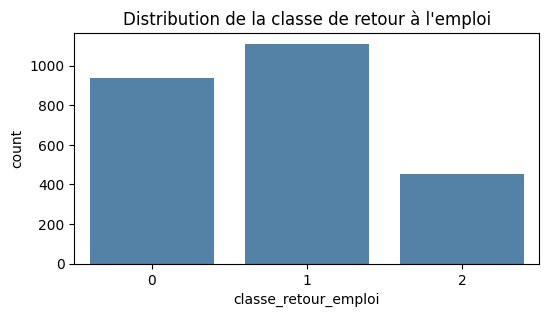

In [17]:
# Distribution de la cible
print("Distribution de la variable cible :")
display((df["classe_retour_emploi"].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

plt.figure(figsize=(6, 3))
sns.countplot(data=df, x="classe_retour_emploi",color="steelblue")
plt.title("Distribution de la classe de retour à l'emploi")
plt.show()


📝 **Synthèse (§3.4)**

Répartition observée
Classe 1 (retour 6-12 mois) : 44,48%
Classe 0 (retour <6 mois) : 37,44%
Classe 2 (retour >12 mois) : 18,08%

La cible est modérément déséquilibrée. La classe 2 (retour >12 mois) est la minoritaire, avec un peu moins de la moitié de l'effectif de la classe majoritaire (18,08% vs 44,48%).

**Implications pour la modélisation

Métrique d'évaluation : l'accuracy seule serait trompeuse (un modèle qui prédit toujours la classe 1 obtiendrait déjà ~44% de bonne classification). Privilégier F1-score macro ou pondéré, matrice de confusion par classe, et un focus particulier sur le rappel de la classe 2 — c'est souvent la 
classe la plus critique d'un point de vue métier (La classe 2 correspond aux personnes dont le délai estimé/observé de retour à l'emploi est supérieur à 12 mois et constitue donc une classe particulièrement importante à surveiller dans le cadre de l'orientation).

Stratégie de rééquilibrage à envisager : selon l'algorithme choisi, un class_weight="balanced" (scikit-learn), un sur-échantillonnage ciblé (SMOTE) sur la classe 2, ou un seuillage ajusté post-prédiction peuvent être pertinents. À tester plutôt qu'à appliquer par défaut, car un rééquilibrage agressif sur seulement 2500 lignes peut introduire du bruit.

Lien avec l'enjeu de fairness déjà identifié : le déséquilibre de la cible se combine avec le déséquilibre déjà repéré sur nationalite_hors_ue (88,2%/11,8%). Si le sous-groupe minoritaire de nationalité est aussi sur-représenté dans la classe 2 (à vérifier par un croisement), le risque de mauvaise performance différenciée entre sous-groupes est d'autant plus élevé — point à intégrer dans l'audit de biais prévu.

Action recommandée avant modélisation : croiser classe_retour_emploi avec nationalite_hors_ue, groupe_age et departement pour vérifier si le déséquilibre de classe est uniformément réparti ou concentré dans certains sous-groupes — ce croisement conditionnera le choix de la stratégie de rééquilibrage et les métriques de suivi par sous-population.**

### 3.5 Corrélations & relations entre variables

In [18]:
# 3.5 Corrélations & relations entre variables
# Matrice de corrélation, pairplot, croisements clés vs cible
# À ajouter en 3.5

#### 3.5.1 Matrice de corrélation (variables numériques)

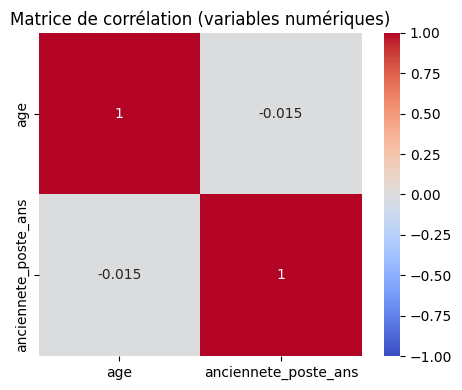

                           age  anciennete_poste_ans
age                   1.000000             -0.015234
anciennete_poste_ans -0.015234              1.000000


In [19]:
num_vars = ['age', 'anciennete_poste_ans']

corr = df[num_vars].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Matrice de corrélation (variables numériques)")
plt.tight_layout()
plt.show()
print(corr)

#### 3.5.2 Pairplot numériques par la cible

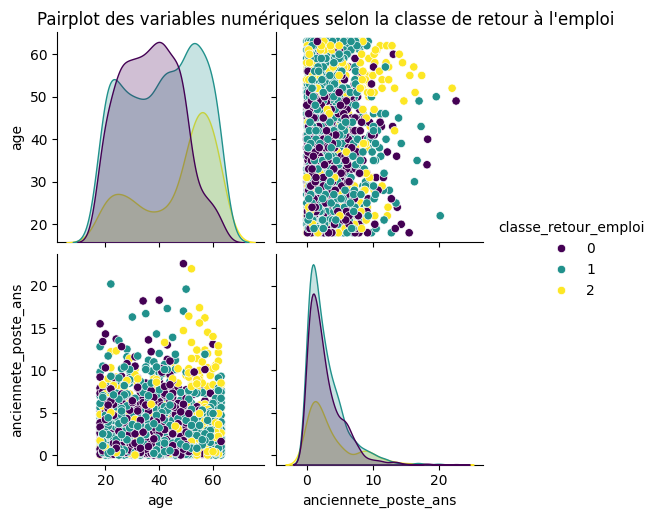

In [20]:
sns.pairplot(df[num_vars + ['classe_retour_emploi']],
             hue='classe_retour_emploi', palette='viridis', diag_kind='kde')
plt.suptitle("Pairplot des variables numériques selon la classe de retour à l'emploi", y=1.02)
plt.show()


#### 3.5.3 Croisements : numériques vs cible (moyenne par classe)


Moyenne des variables numériques par classe cible :
                            age  anciennete_poste_ans
classe_retour_emploi                                 
0                     36.791855              2.782799
1                     41.296890              2.875899
2                     46.482679              3.598009


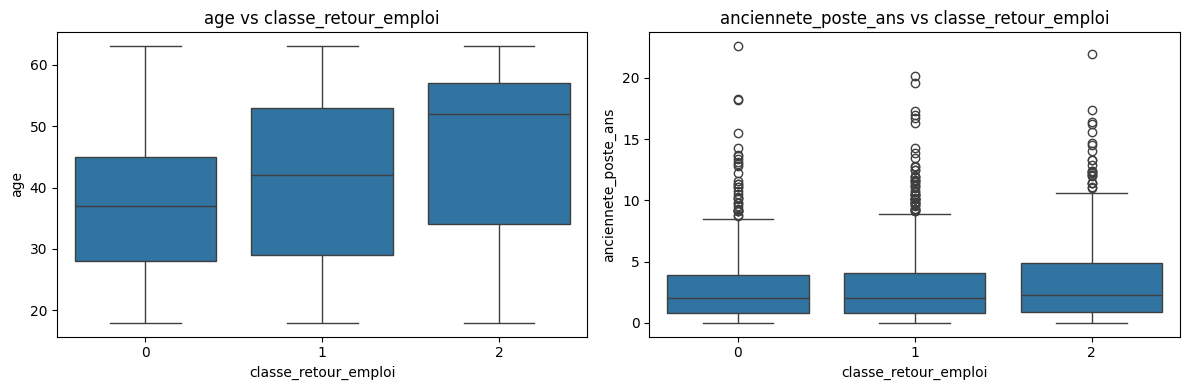

In [21]:
print("\nMoyenne des variables numériques par classe cible :")
print(df.groupby('classe_retour_emploi')[num_vars].mean())

fig, axes = plt.subplots(1, len(num_vars), figsize=(12, 4))
for i, col in enumerate(num_vars):
    sns.boxplot(x='classe_retour_emploi', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs classe_retour_emploi')
plt.tight_layout()
plt.show()

#### 3.5.3 Croisements : catégorielles vs cible

In [22]:
# BLOC 1 : Tableaux croisés + test du Chi² (calcul, pas d'affichage graphique)

pd.set_option('display.max_rows', None)  # évite toute troncature de l'affichage

cat_vars = ['niveau_diplome', 'nationalite_hors_ue', 'est_allocataire',
            'departement', 'code_rome_vise', 'synthese_entretien']

resultats_chi2 = {}  # stocke tout pour réutilisation (visualisation, rapport)

for col in cat_vars:
    ct_full = pd.crosstab(df[col], df['classe_retour_emploi'], normalize='index')
    ct_raw = pd.crosstab(df[col], df['classe_retour_emploi'])

    chi2, p, dof, expected = chi2_contingency(ct_raw)
    resultats_chi2[col] = {"chi2": chi2, "p": p, "dof": dof, "ct": ct_full}

    print(f"\n--- {col} vs classe_retour_emploi (proportions par ligne) ---")
    print(ct_full.round(3).to_string())
    print(f"Chi² = {chi2:.2f}, p-value = {p:.4f}  (n modalités = {ct_full.shape[0]})")

pd.reset_option('display.max_rows')


--- niveau_diplome vs classe_retour_emploi (proportions par ligne) ---
classe_retour_emploi      0      1      2
niveau_diplome                           
Bac                   0.377  0.481  0.142
Bac+2                 0.377  0.495  0.128
Bac+5                 0.635  0.293  0.072
Sans diplôme          0.119  0.467  0.414
Chi² = 390.63, p-value = 0.0000  (n modalités = 4)

--- nationalite_hors_ue vs classe_retour_emploi (proportions par ligne) ---
classe_retour_emploi      0      1      2
nationalite_hors_ue                      
0                     0.406  0.440  0.154
1                     0.139  0.481  0.380
Chi² = 123.67, p-value = 0.0000  (n modalités = 2)

--- est_allocataire vs classe_retour_emploi (proportions par ligne) ---
classe_retour_emploi      0      1      2
est_allocataire                          
0.0                   0.379  0.435  0.186
1.0                   0.371  0.452  0.177
Chi² = 0.74, p-value = 0.6895  (n modalités = 2)

--- departement vs classe_retour_emplo

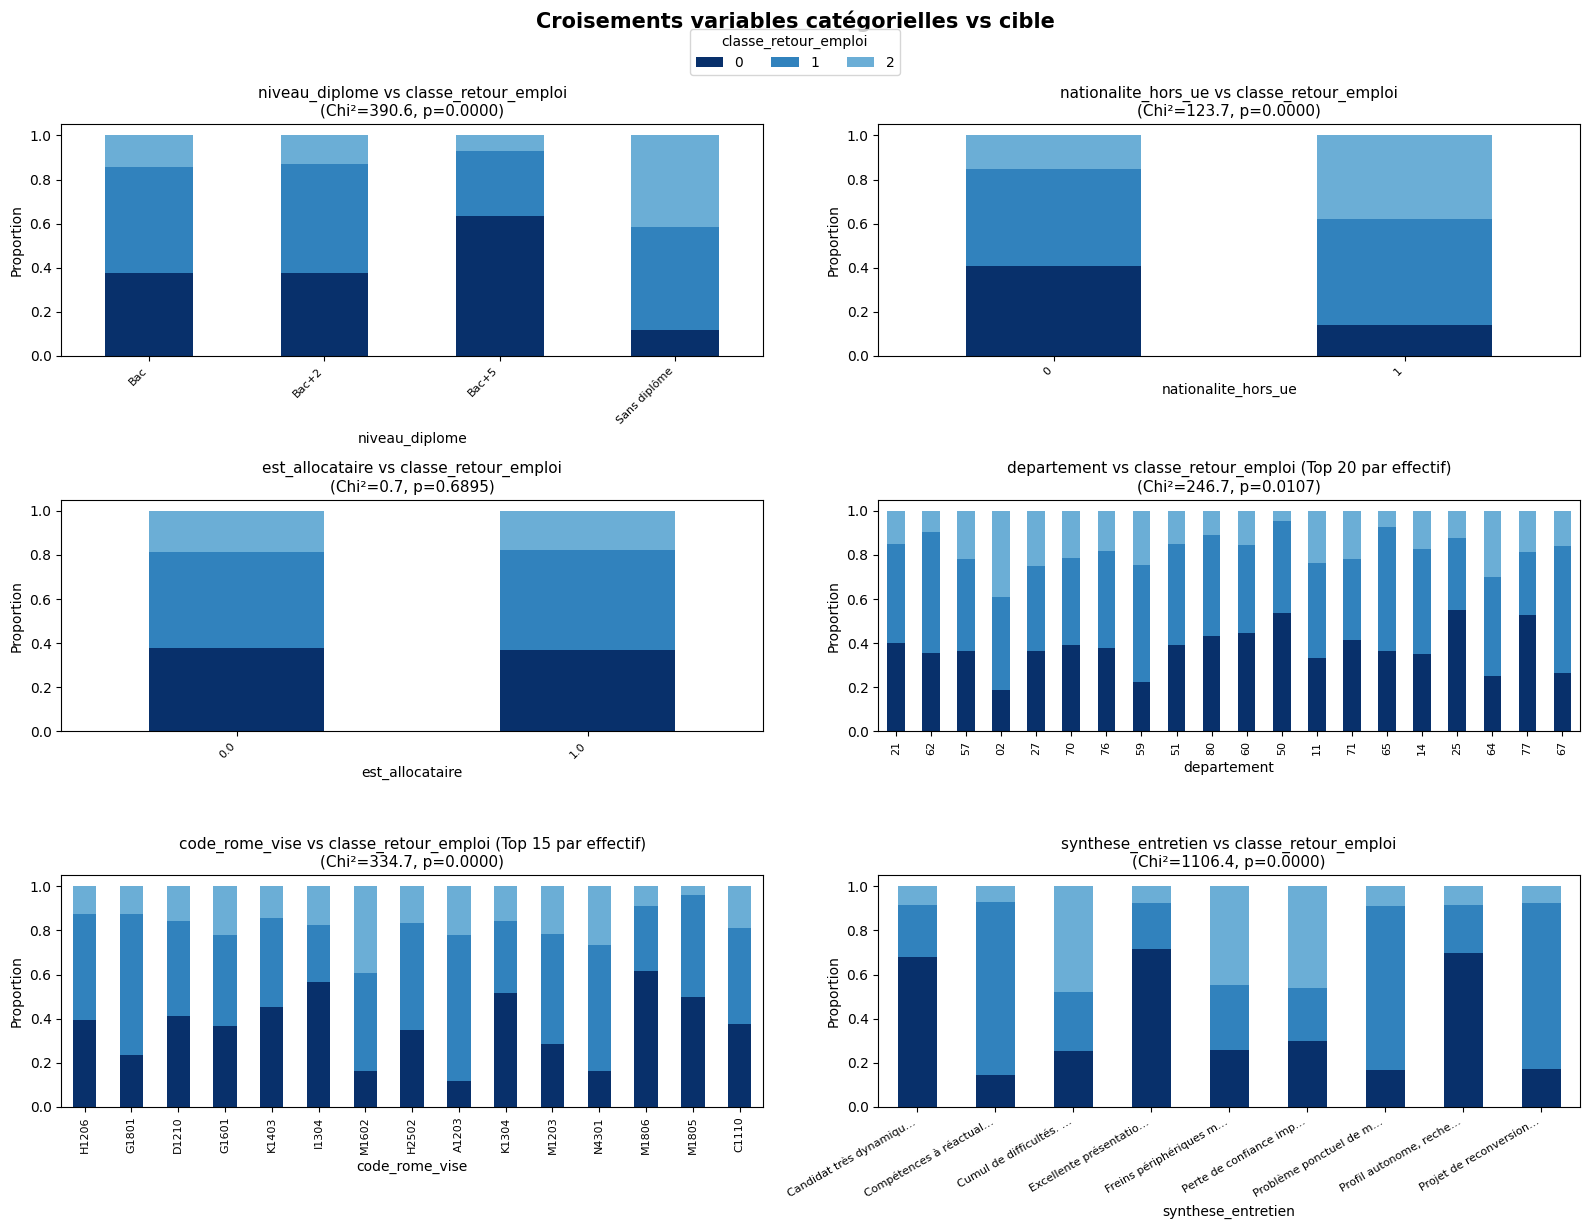

In [23]:
# ============================================================
# BLOC 2 : Visualisation (réutilise resultats_chi2 calculé au bloc 1)
# ============================================================

# Palette bleue personnalisée (du plus foncé au plus clair, clair remonté en intensité)
palette_bleue = ['#08306b', '#3182bd', '#6baed6']

n_vars = len(cat_vars)
n_cols = 2
n_rows = -(-n_vars // n_cols)  # arrondi supérieur

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    ct_full = resultats_chi2[col]["ct"]
    chi2 = resultats_chi2[col]["chi2"]
    p = resultats_chi2[col]["p"]

    # --- Cas particulier : departement (96 modalités) → Top 20 par effectif ---
    if col == "departement":
        top_n = df[col].value_counts().head(20).index
        ct = ct_full.loc[top_n]
        titre_extra = " (Top 20 par effectif)"
        rotation, ha = 90, "center"

    # --- Cas particulier : code_rome_vise (50 modalités) → Top 15 par effectif ---
    elif col == "code_rome_vise":
        top_n = df[col].value_counts().head(15).index
        ct = ct_full.loc[top_n]
        titre_extra = " (Top 15 par effectif)"
        rotation, ha = 90, "center"

    # --- Cas particulier : synthese_entretien (9 phrases longues) → labels raccourcis ---
    elif col == "synthese_entretien":
        ct = ct_full.copy()
        ct.index = [label[:22] + "…" if len(label) > 22 else label for label in ct.index]
        titre_extra = ""
        rotation, ha = 30, "right"

    else:
        ct = ct_full
        titre_extra = ""
        rotation, ha = 45, "right"

    ct.plot(kind='bar', stacked=True, color=palette_bleue, ax=axes[i], legend=False)
    axes[i].set_title(f'{col} vs classe_retour_emploi{titre_extra}\n(Chi²={chi2:.1f}, p={p:.4f})',
                       fontsize=11)
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=rotation)
    for label in axes[i].get_xticklabels():
        label.set_ha(ha)
        label.set_fontsize(8)

# Masque les sous-graphiques vides si besoin
for j in range(n_vars, len(axes)):
    axes[j].axis("off")

# Légende unique partagée
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='classe_retour_emploi',
           loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=3)

plt.suptitle("Croisements variables catégorielles vs cible", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

📝 **Synthèse (§3.5)**

**Numériques** : 
- `age` porte un vrai signal monotone (36,8 → 41,3 → 46,5 ans selon la classe) et sépare visiblement les distributions dans le pairplot ;
- `anciennete_poste_ans` n'apporte quasiment rien (2,78 → 2,88 → 3,60 ans, aucune séparation visuelle), sans colinéarité entre les deux (r=-0,015).

**Catégorielles** : L'analyse du Chi² met en évidence des associations statistiques entre certaines variables catégorielles et la classe cible. Les valeurs de χ² les plus élevées sont observées pour `synthese_entretien`, `niveau_diplome` et  `code_rome_vise`.

### 3.6 Analyse des biais & variables sensibles

*[Quelles variables peuvent porter un biais (genre, âge, origine, profession des parents…) ? La cible est-elle inégalement répartie selon ces variables ? Disparate impact ?]*

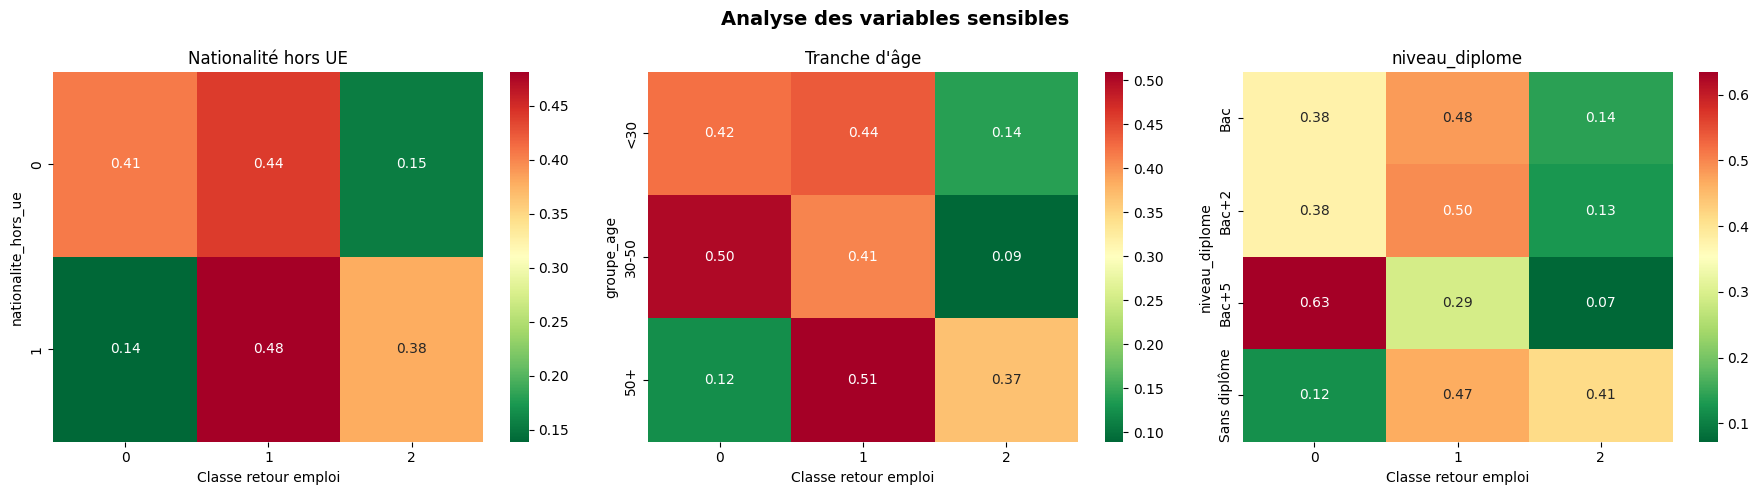

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Nationalité hors UE

ct_nat = pd.crosstab(
    df["nationalite_hors_ue"],
    df["classe_retour_emploi"],
    normalize="index"
)

sns.heatmap(
    ct_nat,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    ax=axes[0]
)

axes[0].set_title("Nationalité hors UE")
axes[0].set_xlabel("Classe retour emploi")
axes[0].set_ylabel("nationalite_hors_ue")

# 2. Groupe d'âge


ct_age = pd.crosstab(
    df["groupe_age"],
    df["classe_retour_emploi"],
    normalize="index"
)

sns.heatmap(
    ct_age,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    ax=axes[1]
)

axes[1].set_title("Tranche d'âge")
axes[1].set_xlabel("Classe retour emploi")
axes[1].set_ylabel("groupe_age")


# 3. niveau_diplome

ct_alloc = pd.crosstab(
    df["niveau_diplome"],
    df["classe_retour_emploi"],
    normalize="index"
)

sns.heatmap(
    ct_alloc,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    ax=axes[2]
)

axes[2].set_title("niveau_diplome")
axes[2].set_xlabel("Classe retour emploi")
axes[2].set_ylabel("niveau_diplome")

plt.suptitle("Analyse des variables sensibles", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [25]:
# Vérification empirique du biais lexical suspecté sur synthese_entretien (cf. §2.4)
texte = df["synthese_entretien"].fillna("").str.lower()

# Recherche de mentions explicites de critères sensibles
patterns = {
    "age_mention": r"\b(?:\d+\s*ans|jeune|âgé|senior|ans\b)",
    "origine_mention": r"\b(?:étranger|immigr|nationalité|origine)",
    "genre_mention": r"\b(?:madame|monsieur)",
}
for label, pattern in patterns.items():
    n = texte.str.contains(pattern, regex=True, na=False).sum()
    print(f"{label} : {n} occurrences sur {texte.notna().sum()} textes ({n/len(df)*100:.1f} %)")

# Le texte permet-il de prédire une variable sensible ? (signal de biais lexical implicite)
tfidf = TfidfVectorizer(max_features=200, min_df=5)
X_text = tfidf.fit_transform(texte)

for sensible_col in ["nationalite_hors_ue", "groupe_age"]:
    y = df[sensible_col]
    mask = y.notna()
    if y[mask].nunique() < 2:
        continue
    clf = LogisticRegression(max_iter=1000)  # multi_class retiré (déprécié, comportement par défaut = multinomial)
    scoring = "roc_auc_ovr" if y[mask].nunique() > 2 else "roc_auc"
    scores = cross_val_score(clf, X_text[mask.values], y[mask], cv=5, scoring=scoring)
    print(f"\nAUC texte → {sensible_col} : {scores.mean():.3f} (proche de 0.5 = pas de biais lexical détecté)")

age_mention : 0 occurrences sur 2500 textes (0.0 %)
origine_mention : 0 occurrences sur 2500 textes (0.0 %)
genre_mention : 0 occurrences sur 2500 textes (0.0 %)

AUC texte → nationalite_hors_ue : 0.542 (proche de 0.5 = pas de biais lexical détecté)

AUC texte → groupe_age : 0.543 (proche de 0.5 = pas de biais lexical détecté)


In [26]:
# Fonction de calcul du Disparate Impact (règle des 4/5)

def disparate_impact(df, sensitive_col, target_col, positive_value,
                      min_group_size=None):
    
    grp = df.groupby(sensitive_col, observed=True)[target_col]
    sizes = grp.size()
    selection_rate = grp.apply(lambda x: (x == positive_value).mean())

    n_exclus = 0
    if min_group_size is not None:
        keep = sizes[sizes >= min_group_size].index
        n_exclus = len(selection_rate) - len(keep)
        selection_rate = selection_rate.loc[keep]

    sr_min, sr_max = selection_rate.min(), selection_rate.max()
    di = sr_min / sr_max  # toujours ≤ 1 par construction (min/max)

    verdict = "⚠️ Signal" if di < 0.8 else "✅ OK"

    return {
        "Variable": sensitive_col,
        "N groupes": len(selection_rate),
        "N groupes exclus (< seuil)": n_exclus,
        "Selection Rate min": round(sr_min, 3),
        "Selection Rate max": round(sr_max, 3),
        "DI": round(di, 3),
        "Verdict": verdict
    }

In [27]:
# Critères de discrimination

sensitive_vars = ["nationalite_hors_ue", "groupe_age", "est_allocataire", "niveau_diplome"]

results = []
for var in sensitive_vars:
    results.append(
        disparate_impact(
            df=df, sensitive_col=var, target_col="classe_retour_emploi",
            positive_value=0
        )
    )

di_table = pd.DataFrame(results).sort_values(by="DI").reset_index(drop=True)
di_table

,Variable,N groupes,N groupes exclus (< seuil),Selection Rate min,Selection Rate max,DI,Verdict
0,niveau_diplome,4,0,0.119,0.635,0.188,⚠️ Signal
1,groupe_age,3,0,0.123,0.501,0.245,⚠️ Signal
2,nationalite_hors_ue,2,0,0.139,0.406,0.342,⚠️ Signal
3,est_allocataire,2,0,0.371,0.379,0.980,✅ OK


### 3.7 📝 Synthèse EDA

*[Top 5 enseignements de l'EDA. Hypothèses de travail pour la modélisation. Risques de biais identifiés. **Révision éventuelle des cibles 1.4** à la lumière de la donnée.]*

**1. La cible présente un déséquilibre modéré**

La classe 2 (>12 mois) représente environ 18 % des observations, contre 37 % pour la classe 0 et 44 % pour la classe 1. Une bonne performance globale pourrait masquer une mauvaise détection de cette classe minoritaire. Les métriques privilégiées seront donc le F1-macro, le rappel de la classe 2 et l'analyse détaillée de la matrice de confusion.

**2. L'âge apparaît comme la variable numérique la plus informative**

L'âge moyen augmente de façon monotone entre les trois classes (36,8 → 41,3 → 46,5 ans), ce qui suggère un fort pouvoir discriminant. À l'inverse, l'ancienneté du dernier poste semble apporter un signal plus limité. L'apport réel de ces variables sera confirmé par la modélisation et non uniquement par l'EDA.

**3. Plusieurs variables catégorielles présentent une association forte avec la cible**

Les variables synthese_entretien, niveau_diplome, code_rome_vise, departement et nationalite_hors_ue présentent des associations statistiquement significatives avec la cible. Elles constituent des candidates pertinentes pour la modélisation, sous réserve d'une analyse complémentaire de leurs implications éthiques et réglementaires.

**4. La variable textuelle constitue une source d'information importante mais atypique**

La variable synthese_entretien présente le niveau d'association le plus élevé avec la cible. Cependant, elle ne contient que neuf formulations distinctes réutilisées sur l'ensemble du jeu de données. Elle sera comparée à des scénarios sans texte afin de mesurer sa contribution réelle et d'écarter un éventuel risque de fuite d'information ou de surapprentissage.

**5. Des risques de biais significatifs sont identifiés**

L'analyse de fairness met en évidence des signaux de disparité pour l'âge (DI = 0,245) et la nationalité (DI = 0,342), tandis que le statut d'allocataire ne présente pas de déséquilibre notable. En outre, le département et le niveau de diplôme peuvent agir comme variables proxy de caractéristiques socio-économiques ou démographiques. Plusieurs scénarios de modélisation seront donc comparés afin d'évaluer le compromis entre performance prédictive et réduction des risques de discrimination.

**Hypothèses de travail pour la modélisation**
- Le scénario complet devrait offrir la meilleure performance prédictive.
- La suppression de nationalite_hors_ue pourrait avoir un impact limité sur les performances tout en réduisant le risque juridique.
- La suppression simultanée des variables sensibles et des principaux proxies (age, nationalite_hors_ue, departement, éventuellement niveau_diplome) permettra d'évaluer le coût réel d'une approche d'IA plus responsable.
- La comparaison entre scénarios tabulaires et textuels permettra de quantifier l'apport spécifique de la variable synthese_entretien.
- Le choix final sera effectué sur la base d'un compromis entre performance, robustesse, explicabilité et équité.

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | Taux d'erreur critique de sous-classement (Faux Négatifs Classe 2) | Minimum possible (aiguillage fiable) | Taux d'erreur Classe 2 → Classe 0 < 5% | Classer un usager à risque de longue durée (Classe 2) en retour rapide (Classe 0) est l'erreur la plus grave : elle prive l'usager d'un accompagnement renforcé indispensable, avec un coût humain et financier majeur. Seuils de décision et pondération des classes seront ajustés pour pénaliser spécifiquement cette erreur. |
| Modèle | Recall (rappel) de la Classe 2 | Non spécifié explicitement | Recall Classe 2 ≥ 0.85 | Métrique technique directement liée à la contrainte métier ci-dessus : un recall élevé sur la Classe 2 garantit que la majorité des usagers réellement à risque de longue durée sont détectés comme tels. Le seuil se déduit de la tolérance d'erreur < 5% fixée par le métier, à ajuster après les premiers entraînements. Seuils de décision et pondération des classes seront ajustés pour maximiser ce recall, quitte à sacrifier un peu de précision sur cette classe. |
| Modèle | F1-score macro | Non spécifié explicitement | F1-score macro ≥ 0.75 | L'EDA a révélé un déséquilibre modéré des classes (Classe 2 = 18,1%), rendant l'accuracy seule trompeuse. Le F1-macro est retenu pour garantir une performance équitable sur les trois classes, notamment la classe minoritaire à risque. |
| Modèle | Accuracy globale | Maximale | Accuracy ≥ 0.80 | Baseline de cohérence exigée par le sujet : l'accuracy doit rester élevée pour valider la performance sur les classes majoritaires (0 et 1), mais reste secondaire au recall Classe 2, au F1-macro et à la matrice de confusion. |
| Éthique & Légal | Disparate Impact (règle des 4/5) | Non spécifié (conformité RGPD) | DI ≥ 0.80, mesuré sur les prédictions du modèle en production | L'EDA sur les données brutes révèle un déséquilibre du taux de retour rapide selon l'âge (DI=0.245) et la nationalité (DI=0.342), reflet de facteurs socio-économiques structurels préexistants. Le scénario retenu (Scénario 2, sans variables sensibles) devra être audité pour vérifier que ses prédictions ne reproduisent ni n'amplifient ce déséquilibre — fondement : RGPD (art. 5/6/22, licéité et décision automatisée), art. 225-1 du Code pénal (critères de discrimination), et AI Act (système à haut risque, accès à l'emploi). |
| Opérationnel | Temps de réponse de l'API (inférence) | Latence acceptable en face-à-face | Latence p95 < 200 ms | Le conseiller utilise l'application en direct avec l'usager lors de l'entretien. L'inférence multimodale (tabulaire + texte) via l'API doit être quasi-instantanée pour ne pas ralentir l'échange. |

recall Classe 2 est la métrique de pilotage du critère métier, et le F1-macro/accuracy des métriques de validation globale — cette articulation (métrique métier → métrique technique → métrique de cohérence globale) montre une vraie maîtrise de la traduction besoin métier → spécification ML

---
## 4. Préparation des données

**Compétences** : C3 (préparer les données pour renforcer intégrité et pertinence)

🎯 Construire un **pipeline reproductible** de préprocessing (pas de transformations one-shot dispersées).

💡 `sklearn.compose.ColumnTransformer` + `sklearn.pipeline.Pipeline` = base obligatoire.  
⚠️ Le **train/test split DOIT précéder** tout calcul d'imputation/normalisation, sinon fuite de données.

## 4.1 Train/test split

In [28]:
import sys

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

%load_ext autoreload
%autoreload 2

# Import depuis preprocess.py (pas pipeline_tabulaire)
from preprocess import load_dataset, build_preprocessor, get_all_features, SENSITIVE_FEATURES, PROXY_FEATURES

In [29]:
from train import load_scenario_dataset, split_train_holdout
from config import TEST_SIZE, RANDOM_STATE, SCENARIOS 

# Charger les données + split stratify
resultats_par_scenario = {}
print(f"{'Scénario':25s} | {'X_train':12s} | {'X_holdout':12s} | {'N.col':6s} | Description")
print("-" * 110)

for scenario_name in SCENARIOS.keys():
    X, y = load_scenario_dataset(data_path=RAW_PATH, scenario_name=scenario_name)
    X_train, X_holdout, y_train, y_holdout = split_train_holdout(X=X, y=y)
    resultats_par_scenario[scenario_name] = {
        "X_train": X_train, "X_holdout": X_holdout,
        "y_train": y_train, "y_holdout": y_holdout,
    }
    description = SCENARIOS[scenario_name].get("description", "")
    print(
        f"{scenario_name:25s} | {str(X_train.shape):12s} | {str(X_holdout.shape):12s} "
        f"| {X_train.shape[1]:6d} | {description}"
    )
    print(f"{'':25s} | Colonnes : {list(X_train.columns)}")
    print()

print("TEST_SIZE =", TEST_SIZE)
print("RANDOM_STATE =", RANDOM_STATE)
print("-" * 110)

Scénario                  | X_train      | X_holdout    | N.col  | Description
--------------------------------------------------------------------------------------------------------------
multimodal_complet        | (2000, 8)    | (500, 8)     |      8 | Variables tabulaires, texte et variables sensibles.
                          | Colonnes : ['age', 'anciennete_poste_ans', 'niveau_diplome', 'code_rome_vise', 'departement', 'est_allocataire', 'nationalite_hors_ue', 'synthese_entretien']

multimodal_ethique        | (2000, 6)    | (500, 6)     |      6 | Variables tabulaires et texte sans variables sensibles.
                          | Colonnes : ['anciennete_poste_ans', 'niveau_diplome', 'code_rome_vise', 'departement', 'est_allocataire', 'synthese_entretien']

multimodal_ethique_renforce | (2000, 4)    | (500, 4)     |      4 | S2 bis : variables tabulaires et texte sans variables sensibles ni variables proxy (ethique renforce).
                          | Colonnes : ['anciennete_

## 4.2 Preprocessing

In [30]:
from importlib import reload
import preprocess

reload(preprocess)

from preprocess import (
    get_numeric_features,
    get_ordinal_features,
    get_categorical_features,
)

In [31]:
from preprocess import NUMERIC_FEATURES, ORDINAL_FEATURES, TEXT_FEATURE, BASE_CATEGORICAL_FEATURES
display(get_ordinal_features())
display(get_numeric_features())
display(get_categorical_features())
display(TEXT_FEATURE)

{'niveau_diplome': ['Sans diplôme', 'Bac', 'Bac+2', 'Bac+5']}

['age', 'anciennete_poste_ans']

['code_rome_vise', 'departement', 'est_allocataire', 'nationalite_hors_ue']

'synthese_entretien'

In [32]:
from preprocess import build_preprocessor
preprocessor = build_preprocessor()
display (preprocessor)
print("Pipelines de prétraitement réalisée avec succès")

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'anciennete_poste_ans']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Sans '
                                                                              'diplôme',
                                                                              'Bac',
                                                                              'Bac+2',
                                                                              'Bac+5']],
                                                                 encoded_missing_value=-1,
                                                                 handle_un...
                                 Pipeline(steps=[('cleaner', TextCleaner()),
                                                 ('tfidf',
                                                  TfidfVectorizer(max_features=1000,
                                                                  min_df=2,
                                                                  ngram_range=(2,
                                                                               3),
                                                                  stop_words=['a',
                                                                              'afin',
                                                                              'ainsi',
                                                                              'au',
                                                                              'aux',
                                                                              'avec',
                                                                              'ce',
                                                                              'ces',
                                                                              'cet',
                                                                              'cette',
                                                                              'comme',
                                                                              'dans',
                                                                              'de',
                                                                              'des',
                                                                              'du',
                                                                              'elle',
                                                                              'elles',
                                                                              'en',
                                                                              'est',
                                                                              'et',
                                                                              'il',
                                                                              'ils',
                                                                              'je',
                                                                              'la',
                                                                              'le',
                                                                              'les',
                                                                              'leur',
                                                 

Pipelines de prétraitement réalisée avec succès


### 4.3 Scénarios de jeux de données

Les scénarios ci-dessous permettent d’évaluer séparément :

- la performance maximale du modèle ;
- l’impact du retrait des variables sensibles directes ;
- les contributions respectives du texte et des données tabulaires.

> `usager_id` est exclu de tous les scénarios, car il s’agit d’un identifiant technique sans valeur prédictive légitime.

| Scénario | Variables conservées | Variables exclues | Justification |
|---|---|---|---|
| **S1 – Multimodal complet** | `age`, `anciennete_poste_ans`, `niveau_diplome`, `code_rome_vise`, `departement`, `est_allocataire`, `nationalite_hors_ue`, `synthese_entretien` | `usager_id` | Scénario de référence visant la performance prédictive maximale. Il mobilise toutes les variables exploitables afin de mesurer le niveau de performance atteignable avant atténuation des risques de biais. |
| **S2 – Multimodal éthique** | `anciennete_poste_ans`, `niveau_diplome`, `code_rome_vise`, `departement`, `est_allocataire`, `synthese_entretien`| `usager_id`, `age`, `nationalite_hors_ue` | Scénario d’atténuation des biais reposant sur le retrait des deux variables sensibles directes. Il permet de mesurer le coût en performance de cette suppression tout en conservant les informations métier et le texte. |
| **S3 – Texte seul** | `synthese_entretien` | Toutes les variables tabulaires et `usager_id` | Scénario NLP permettant de mesurer la capacité prédictive du texte seul et de vérifier si les synthèses d’entretien concentrent une part importante du signal associé à la cible. |
| **S4 – Tabulaire seul** | `age`, `anciennete_poste_ans`, `niveau_diplome`, `departement` | `synthese_entretien`, `code_rome_vise`, `est_allocataire`, `nationalite_hors_ue`, `usager_id` | Scénario de référence tabulaire permettant d’évaluer la performance obtenue sans information textuelle et de comparer la contribution des données structurées à celle du texte. |

#### Logique de comparaison

- **S1 → S2** : mesure le coût du retrait des variables sensibles directes `age` et `nationalite_hors_ue`.
- **S3 → S4** : compare la contribution prédictive du texte à celle des variables tabulaires.
- **S1 → S3 et S4** : mesure la valeur ajoutée de la combinaison multimodale par rapport à chaque modalité utilisée séparément.

**Le même protocole de prétraitement, de validation et d’évaluation est appliqué à tous les scénarios. Seul le périmètre des variables varie, afin de garantir une comparaison équitable des performances.**



### 4.4 📝 Synthèse préparation

Les données ont été préparées au moyen d’un pipeline reproductible reposant sur un `ColumnTransformer` intégré à un `Pipeline` scikit-learn afin de prévenir toute fuite de données entre les étapes de prétraitement et de modélisation.

- Les variables numériques (`age`, `anciennete_poste_ans`) sont imputées puis standardisées. 
- Les variables catégorielles (`niveau_diplome`, `code_rome_vise`, `departement`, `est_allocataire`, `nationalite_hors_ue`) sont imputées puis encodées. 
- La variable textuelle `synthese_entretien` est vectorisée à l’aide de TF-IDF afin de permettre son exploitation par les modèles de classification.
Bien que la variable `synthese_entretien` ne compte actuellement que 9 modalités distinctes, celles-ci correspondent à du texte libre rédigé manuellement et sont donc susceptibles d'évoluer dans le temps (nouvelles formulations, nouvelles situations métier décrites par les conseillers). Un encodage One-Hot, figé sur les catégories observées au moment de l'entraînement, ne serait pas en mesure d'intégrer correctement une valeur textuelle inédite : celle-ci serait ignorée ou traitée comme totalement vide d'information, obligeant à réentraîner l'encodeur dès l'apparition de nouveau vocabulaire. Le choix du TF-IDF permet au contraire d'anticiper cette évolution : un nouveau texte partageant du vocabulaire avec les formulations déjà connues produira un vecteur cohérent avec l'espace appris, sans nécessiter de réajustement du pipeline. Ce choix privilégie donc la robustesse et la pérennité du système en production, plutôt qu'un gain de performance immédiat sur les 9 modalités actuellement observées. Un compromis jugé pertinent dans une perspective d'usage à long terme du modèle.

4 scénarios ont été construits afin d’évaluer le compromis entre performance prédictive et réduction des risques de biais :

- **S1 – Multimodal complet** : toutes les variables disponibles ;
- **S2 – Multimodal éthique** : suppression des variables sensibles directes (`age`, `nationalite_hors_ue`) ;
- **S3 – Texte seul** : utilisation exclusive de `synthese_entretien` ;
- **S4 – Tabulaire seul** : utilisation exclusive des variables structurées.

La traçabilité est assurée par l’utilisation d’une même chaîne de prétraitement, d’un même protocole de validation et des mêmes métriques d’évaluation pour tous les scénarios. Seul le périmètre des variables varie, ce qui garantit une comparaison équitable des résultats obtenus.

### 4.5 Assertions de qualité (indispensable !)

🎯 Avant de passer à la modélisation, **vérifie via des `assert`** que la donnée préparée est saine. Une assertion qui échoue arrête le notebook : c'est le but.

💡 Ces assertions sont la **première ligne de tests automatisés** que tu généraliseras en M5 (pytest).  
⚠️ Si l'une d'elles casse, ne la commente pas. Cherche pourquoi avant de modéliser.

In [33]:
# Exemples d'assertions de qualité — adapte-les à ton dataset
# assert df.shape[0] > 0, "Dataset vide après préparation"
# assert df["target"].isna().sum() == 0, "Manquants résiduels dans la cible"
# assert df.duplicated().sum() == 0, "Doublons résiduels"
# assert set(df["target"].unique()).issubset({0, 1}), "Cible binaire attendue"
# assert (X_train.shape[0] + X_test.shape[0]) == df.shape[0], "Split incomplet"

In [34]:
import pytest
#import sys
#from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\a895479\projet\examen")
TEST_PATH = PROJECT_ROOT / "tests" / "test_preprocess.py"
pytest.main([
    str(TEST_PATH),
    "-vv",
    "-s",
    "--capture=no",
])

================================================ test session starts ================================================
platform win32 -- Python 3.12.10, pytest-8.3.3, pluggy-1.6.0 -- C:\Users\a895479\projet\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\a895479\projet\examen
plugins: anyio-4.14.2
collecting ... collected 6 items

..\tests\test_preprocess.py::test_dataset_is_not_empty Dataset complet non vide : 2500 lignes
PASSED
..\tests\test_preprocess.py::test_target_has_no_missing_values Valeurs manquantes dans la cible : 0
PASSED
..\tests\test_preprocess.py::test_dataset_has_no_duplicates Doublons dans le dataset : 0
PASSED
..\tests\test_preprocess.py::test_target_contains_expected_classes Classes observées dans classe_retour_emploi : [0, 1, 2]
PASSED
..\tests\test_preprocess.py::test_preprocessing_preserves_rows Répartition attendue/réelle : train 2000/2000, test 500/500
Lignes train avant/après preprocessing : 2000 / 2000
Lignes test avant/après preprocessing :

<ExitCode.OK: 0>

---
## 5. Modélisation & entraînement

**Compétences** : C4 (choisir un modèle adapté), C5 (entraîner le modèle)

### 5.0 Familles de modèles candidates

| Famille | Adapté à mon problème ? | Coût total (train + inférence) | Explicabilité | Dépendance fournisseur | Décision (retenue / écartée + motif) |
|---|---|---|---|---|---|
| ML classique (sklearn, XGBoost) | *Oui, très adapté : données principalement tabulaires, taille du dataset limitée 2500 lignes< 1M, classification supervisée 3 classes. TF-IDF permet également d'intégrer le texte.* | faible | élevée | aucune | *Retenue — approche principale. Constitue la baseline et les meilleurs candidats pour comparer les performances. XGBoost / Random Forest particulièrement adaptés aux données tabulaires ; Logistic Regression utile comme baseline interprétable.* |
| Deep Learning (Keras / PyTorch) | *non : possible pour le NLP, mais le dataset est limité et le problème peut être traité efficacement avec TF-IDF + ML classique.* | élevé (GPU train) | faible | aucune (modèle local) | *Écartée — ROI insuffisant. Complexité et coût supplémentaires peu justifiés par rapport à XGBoost/Random Forest + TF-IDF sur ce dataset.* |
| SLM local (Ollama, modèles ≤ 7B) | *Peu adapté au cœur du problème : un SLM pourrait analyser/générer du texte, mais n'est pas nécessaire pour la classification supervisée demandée* | moyen | moyenne | aucune | Écartée pour la classification. Peut être envisagée ultérieurement pour enrichir l'analyse NLP ou générer des explications, mais pas nécessaire pour le modèle prédictif principal. |
| LLM API + RAG | *Non pour la prédiction du délai : le problème est une classification supervisée avec une cible connue, pas un système de questions/réponses sur un corpus documentaire.* | élevé (€/token) | faible | forte (OpenAI / Anthropic / Mistral) | Écartée — inadéquation fonctionnelle. RAG n'apporte pas de valeur nécessaire à la classification. Une API LLM pourrait éventuellement être utilisée en complément pour l'analyse du texte, mais pas comme modèle principal |
| Architecture agentique (multi-LLM, tools) | *Non : aucune orchestration multi-étapes ni action autonome n'est nécessaire pour prédire la classe de retour à l'emploi.* | très élevé | très faible | forte | Écartée — surdimensionnée. L'agentique apporterait une complexité disproportionnée par rapport à une tâche de classification bien définie. |


**📝 Synthèse familles**

La famille **ML classique** est retenue, notamment avec Scikit-learn et XGBoost, car elle est adaptée aux données tabulaires et textuelles du projet tout en offrant un bon compromis entre performance, coût et explicabilité.
Les approches **Deep Learning, SLM, LLM/RAG et agentiques** sont écartées car elles sont plus complexes et coûteuses, sans bénéfice suffisant pour ce problème de classification supervisée. La contrainte décisive est donc **le rapport performance/coût/explicabilité**, particulièrement important dans un contexte d’orientation des demandeurs d’emploi.

### 5.1 Modèles candidats

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| Logistic Regression | linéaire | Baseline robuste, rapide à entraîner, adaptée aux données tabulaires et aux représentations TF-IDF. Permet d'établir un niveau de performance de référence facilement interprétable. | faible / faible | élevée |
| Random Forest | ensemble (bagging) | Modèle robuste aux interactions non linéaires et aux variables catégorielles encodées. Nécessite peu de réglages et constitue une référence classique sur les données tabulaires. | moyen / faible | moyenne |
| XGBoost | ensemble (gradient boosting) | Référence de l'état de l'art sur les données tabulaires. Capable de capturer des relations complexes entre variables et souvent performant sur des jeux de données de taille modérée. | élevé / faible | moyenne |
| LightGBM | ensemble (gradient boosting) | Variante optimisée du boosting conçue pour réduire les temps d'entraînement et d'inférence tout en conservant un niveau de performance élevé. Particulièrement adaptée aux jeux de données tabulaires structurés. | moyen / faible | moyenne |

### 5.2 Entraînement & validation croisée

In [91]:
from train import train_requested_models, print_training_summary
from config import DATA_PATH, RANDOM_STATE, SCENARIOS, TEST_SIZE
MODELS_DIR = PROJECT_ROOT / "models"

results_std = train_requested_models(
    requested_model_type="all",
    requested_scenario="all",
    config_name="balanced",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

print(f"Nombre de modèles entraînés : {len(results_std)}")


Combinaison 1/20
Algorithme    : random_forest
Scénario      : multimodal_complet
Configuration : balanced
Description   : Variables tabulaires, texte et variables sensibles.
Dimensions train   : (2000, 8)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6190 | F1 classe 2 : 0.5455 | Recall classe 2 : 0.7083 | Erreur critique 2→0 : 9.72%
  Fold 2/5 | F1 macro : 0.6486 | F1 classe 2 : 0.5652 | Recall classe 2 : 0.7222 | Erreur critique 2→0 : 16.67%
  Fold 3/5 | F1 macro : 0.6793 | F1 classe 2 : 0.5965 | Recall classe 2 : 0.7083 | Erreur critique 2→0 : 18.06%
  Fold 4/5 | F1 macro : 0.6485 | F1 classe 2 : 0.5509 | Recall classe 2 : 0.6301 | Erreur critique 2→0 : 20.55%
  Fold 5/5 | F1 macro : 0.6736 | F1 classe 2 : 0.5647 | Recall classe 2 : 0.6575 | Erreur critique 2→0 : 10.96%

Résumé F1 macro CV : 0.6538 +/- 0.0215
Résumé Recall classe 2 CV : 0.6853 +/- 0.0353
Résumé Erreur critique 2→0 CV : 15.19% +/- 4.17%
Entraînement terminé en 0.8578 seconde(s).

Pipeline   

### 5.3 Métriques retenues & justification

*[Classification : accuracy, F1 macro/micro/weighted, ROC-AUC, matrice de confusion. Régression : RMSE, MAE, R². Justifier le choix selon la cible et l'enjeu métier.]*

### Grille de métriques d'évaluation

| Catégorie | Métrique | Description | Interprétation |
|---|---|---|---|
| **Performance globale** | **F1 macro** | Moyenne non pondérée des F1-scores calculés classe par classe. | Métrique principale de sélection. Traite les trois classes à égalité, indépendamment de leur fréquence — important ici car la classe 2 est minoritaire. |
| **Risque métier** | **Recall classe 2** | Part des profils réellement classe 2 correctement détectés par le modèle. | Critère prioritaire compte tenu de l'asymétrie de coût : un faux négatif sur cette classe (profil à risque non détecté) est la conséquence la plus coûteuse pour l'usager. |
| **Risque métier** | **F1 classe 2** | Moyenne harmonique de la précision et du recall, sur la seule classe 2. | Mesure synthétique de la qualité de détection de la population la plus sensible (à lire en complément du rappel).|
| **Risque critique** | **Taux d'erreur grave (classe 2 → classe 0)** | Part des profils réellement classe 2 prédits à tort comme classe 0 (aucun risque détecté). | Erreur la plus grave du système : elle conduit à ne proposer aucun accompagnement renforcé à des profils qui en auraient le plus besoin. Correspond au poids le plus élevé de la matrice de coûts métier (§5.2.1). Cible définie : < 5 %. |
| **Robustesse** | **Écart-type du F1 macro (validation croisée)** | Variabilité du F1 macro entre les folds de validation croisée. | Un faible écart-type garantit un modèle stable, dont la performance annoncée est fiable en conditions réelles de production. |
| **Arbitrage métier** | **Coût métier combiné** | Combinaison pondérée des erreurs 2→0 et 0→2. | Permet de comparer les modèles selon le coût opérationnel réel de leurs erreurs et sert de critère principal d'arbitrage entre configurations. |


### 5.4 Comparaison des modèles : tableau de scores CV

Avant de lancer la phase de recherche d'hyperparamètres par GridSearchCV, une première comparaison a été réalisée avec les configurations balanced définies par défaut pour chaque algorithme. Cette étape constitue la baseline de référence du projet et permet d'identifier les scénarios et modèles les plus prometteurs avant toute optimisation.

Les résultats présentés ci-dessous proviennent d'une validation croisée stratifiée à 5 folds réalisée exclusivement sur le jeu d'entraînement

In [92]:
print_training_summary(results_std)


SYNTHÈSE DES ENTRAÎNEMENTS
| Scénario                    | Modèle                | Configuration | F1-macro CV | σ(F1) | Recall classe 2 | σ(Recall C2) | Erreur critique 2→0 |
| --------------------------- | --------------------- | ------------- | :---------- | :---- | :-------------- | :----------- | :------------------ |
| Multimodal complet          | LightGBM              | balanced      |       0.692 | 0.019 |           0.622 |        0.037 |             10.77 % |
| Multimodal complet          | Régression logistique | balanced      |       0.665 | 0.013 |           0.666 |        0.033 |             14.92 % |
| Multimodal complet          | Random Forest         | balanced      |       0.654 | 0.021 |           0.685 |        0.035 |             15.19 % |
| Multimodal complet          | XGBoost               | balanced      |       0.711 | 0.019 |           0.671 |        0.039 |             10.22 % |
| Multimodal éthique          | LightGBM              | balanced      |       

**Première analyse comparative**

Cette première comparaison met en évidence trois enseignements majeurs :
- Le scénario multimodal complet domine nettement les autres scénarios, confirmant la complémentarité entre données tabulaires et textuelles.
- XGBoost apparaît comme le candidat le plus équilibré avant optimisation, avec le meilleur compromis entre F1 macro, rappel de la classe 2 et limitation des erreurs critiques.
- Le retrait des variables sensibles entraîne une perte de performance mesurable, ce qui justifie une analyse approfondie du compromis entre efficacité prédictive et exigences éthiques.

Ces résultats servent de point de départ à la phase suivante de recherche d'hyperparamètres par GridSearchCV, dont l'objectif est d'améliorer les performances tout en réduisant les erreurs critiques associées aux situations de chômage longue durée.

### 5.5 Recherche d'hyperparamètres (GridSearchCV)

Afin d'identifier la configuration la plus adaptée aux objectifs métier du projet, une recherche systématique d'hyperparamètres a été réalisée à l'aide de `GridSearchCV`. Cette méthode consiste à explorer automatiquement plusieurs combinaisons d'hyperparamètres pour chaque algorithme étudié (Random Forest, Logistic Regression, LightGBM et XGBoost).

Afin de garantir la fiabilité des résultats et de limiter le risque de surapprentissage (*overfitting*), chaque combinaison est évaluée par **validation croisée stratifiée réalisée exclusivement sur le jeu d'entraînement**. Le jeu de test reste strictement isolé et n'intervient à aucun moment dans le processus d'optimisation.

Contrairement à une approche classique visant uniquement à maximiser une métrique globale comme l'accuracy ou le F1-score macro, la recherche d'hyperparamètres a été conçue pour tenir compte des enjeux métier spécifiques du cas d'usage :

- la qualité globale de classification (`F1 macro`) ;
- la capacité à détecter les situations de chômage longue durée (`Recall classe 2`) ;
- la qualité de classification de la classe critique (`F1 classe 2`) ;
- la réduction des erreurs critiques de type **2→0**, correspondant à des usagers à risque de chômage longue durée classés à tort comme susceptibles de retrouver rapidement un emploi ;
- la maîtrise des fausses alertes de type **0→2**, correspondant à des usagers orientés à tort vers un accompagnement renforcé.

La sélection finale ne repose donc pas sur une métrique statistique isolée mais sur un **coût métier combiné**, attribuant un poids plus important aux erreurs critiques (2→0) qu'aux fausses alertes (0→2) :

```text
Coût métier = 3 × erreur(2→0) + 1 × erreur(0→2)

#### 5.5.1 GridSearchCV XGBoost

In [115]:
import sys
from pathlib import Path
import pandas as pd

In [116]:
PROJECT_ROOT = Path(r"C:\Users\a895479\projet")
EXAMEN_SRC = PROJECT_ROOT / "examen" / "src"

sys.path = [
    path
    for path in sys.path
    if Path(path).resolve() != (PROJECT_ROOT / "certification" / "src").resolve()
]
sys.path.insert(0, str(EXAMEN_SRC))

for module_name in ["train", "config", "preprocess", "evaluation_utils"]:
    sys.modules.pop(module_name, None)

from config import DATA_PATH, RANDOM_STATE, TEST_SIZE
from train import (
    grid_search_xgboost_class_2,
    grid_search_random_forest_class_2,
    grid_search_logistic_regression_class_2,
    grid_search_lightgbm_class_2,
    load_scenario_dataset,
    split_train_holdout,
    train_requested_models,
    print_training_summary,
)

SCENARIOS = [
    "multimodal_complet",
    "multimodal_ethique",
    "texte_seul",
    "tabulaire_seul",
]

In [117]:
grid_searches_gb = {}
resultats_gb = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV Gradient Boost/XGBoost : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_xgboost_class_2(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_gb[scenario_name] = grid_search
    resultats_gb.append(resultats_scenario)

resultats_cv_gb = pd.concat(
    resultats_gb,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_gb.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé:", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV Gradient Boost/XGBoost : multimodal_complet
GridSearchCV Gradient Boost/XGBoost : multimodal_ethique
GridSearchCV Gradient Boost/XGBoost : texte_seul
GridSearchCV Gradient Boost/XGBoost : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 200, 'classifier__subsample': 0.9}
F1 macro retenu : 0.709295
F1 classe 2 associé: 0.627505

multimodal_ethique
Meilleurs paramètres : {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 400, 'classifier__subsample': 0.9}
F1 macro retenu : 0.659577
F1 classe 2 associé: 0.570638

texte_seul
Meilleurs paramètres : {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__max_depth': 6, 'classifier__min_child_weight': 1, 'classifier__n_e

#### 5.5.2 GridSearchCV Random Forest

In [122]:
grid_searches_rfc = {}
resultats_rfc = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV Random Forest : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_random_forest_class_2(
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        scenario_name=scenario_name,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_rfc[scenario_name] = grid_search
    resultats_rfc.append(resultats_scenario)

resultats_cv_rfc = pd.concat(
    resultats_rfc,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_rfc.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé :", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV Random Forest : multimodal_complet
GridSearchCV Random Forest : multimodal_ethique
GridSearchCV Random Forest : texte_seul
GridSearchCV Random Forest : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 500, 'classifier__n_jobs': 1, 'classifier__random_state': 42}
F1 macro retenu : 0.646243
F1 classe 2 associé : 0.557977

multimodal_ethique
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_depth': 18, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 300, 'classifier__n_jobs': 1, 'classifier__random_state': 42}
F1 macro retenu : 0.635018
F1 classe 2 associé : 0.540133

texte_seul
Meilleurs paramètres : {'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__max_features

#### 5.5.3 GridSearchCV Logistic Regression

In [119]:
grid_searches_logreg = {}
resultats_logreg = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV Logistic Regression : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_logistic_regression_class_2(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_logreg[scenario_name] = grid_search
    resultats_logreg.append(resultats_scenario)

resultats_cv_logreg_grid = pd.concat(
    resultats_logreg,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_logreg.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé :", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV Logistic Regression : multimodal_complet
GridSearchCV Logistic Regression : multimodal_ethique
GridSearchCV Logistic Regression : texte_seul
GridSearchCV Logistic Regression : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__C': 1.0, 'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_iter': 2000, 'classifier__solver': 'lbfgs'}
F1 macro retenu : 0.643363
F1 classe 2 associé : 0.552414

multimodal_ethique
Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_iter': 2000, 'classifier__solver': 'lbfgs'}
F1 macro retenu : 0.63375
F1 classe 2 associé : 0.540382

texte_seul
Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__max_iter': 2000, 'classifier__solver': 'lbfgs'}
F1 macro retenu : 0.618979
F1 classe 2 associé : 0.50809

tabulaire_seul
Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__

#### 5.5.4 GridSearchCV LightGBM

In [120]:
grid_searches_lgbm = {}
resultats_lgbm = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV LightGBM : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_lightgbm_class_2(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_lgbm[scenario_name] = grid_search
    resultats_lgbm.append(resultats_scenario)

resultats_cv_lgbm_grid = pd.concat(
    resultats_lgbm,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_lgbm.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé :", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV LightGBM : multimodal_complet
GridSearchCV LightGBM : multimodal_ethique
GridSearchCV LightGBM : texte_seul
GridSearchCV LightGBM : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 2.5}, 'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__min_child_samples': 10, 'classifier__n_estimators': 350, 'classifier__num_leaves': 15}
F1 macro retenu : 0.712104
F1 classe 2 associé : 0.643649

multimodal_ethique
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__min_child_samples': 10, 'classifier__n_estimators': 150, 'classifier__num_leaves': 15}
F1 macro retenu : 0.645379
F1 classe 2 associé : 0.561169

texte_seul
Meilleurs paramètres : {'classifier__class_weight': None, 'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__min_child_samples': 10, 'clas

**Meilleur modèle par scénario, selon le F1 de la classe 2 :**

Le tableau suivant est calculé directement à partir des candidats évalués par les quatre GridSearchCV. Les égalités sont départagées par le rappel de la classe 2, puis par le taux d'erreur critique 2→0.

In [123]:
comparaison_gridsearch = pd.concat(
    [
        resultats_cv_gb.assign(model_type="xgboost"),
        resultats_cv_rfc.assign(model_type="random_forest"),
        resultats_cv_logreg_grid.assign(model_type="logistic_regression"),
        resultats_cv_lgbm_grid.assign(model_type="lightgbm"),
    ],
    ignore_index=True,
)

meilleurs_modeles_par_scenario = (
    comparaison_gridsearch
    .sort_values(
        [
            "scenario",
            "mean_test_f1_macro",
            "mean_test_f1_class_2",
            "mean_test_recall_class_2",
            "mean_test_error_2_to_0",
        ],
        ascending=[True, False, False, False, True],
    )
    .groupby("scenario", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

display(
    meilleurs_modeles_par_scenario[
        [
            "scenario",
            "model_type",
            "params",
            "mean_test_f1_macro",
            "mean_test_f1_class_2",
            "mean_test_recall_class_2",
            "mean_test_error_2_to_0",
        ]
    ]
)


,scenario,model_type,params,mean_test_f1_macro,mean_test_f1_class_2,mean_test_recall_class_2,mean_test_error_2_to_0
0,multimodal_complet,lightgbm,"{'classifier__class_weight': {0: 1.0, 1: 1.0, ...",0.717103,0.649815,0.704642,0.088318
1,multimodal_ethique,xgboost,"{'classifier__colsample_bytree': 0.9, 'classif...",0.659577,0.570638,0.726750,0.115944
2,tabulaire_seul,lightgbm,"{'classifier__class_weight': None, 'classifier...",0.568162,0.479841,0.361948,0.143493
3,texte_seul,random_forest,"{'classifier__class_weight': None, 'classifier...",0.634969,0.541650,0.660502,0.190449


In [124]:
all_results = []

results = train_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="multimodal_complet",
    config_name="best_class_2_complet",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)


Combinaison 1/1
Algorithme    : lightgbm
Scénario      : multimodal_complet
Configuration : best_class_2_complet
Description   : Variables tabulaires, texte et variables sensibles.
Dimensions train   : (2000, 8)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6701 | F1 classe 2 : 0.6200 | Recall classe 2 : 0.8611 | Erreur critique 2→0 : 4.17%
  Fold 2/5 | F1 macro : 0.6696 | F1 classe 2 : 0.5934 | Recall classe 2 : 0.7500 | Erreur critique 2→0 : 9.72%
  Fold 3/5 | F1 macro : 0.7448 | F1 classe 2 : 0.6554 | Recall classe 2 : 0.8056 | Erreur critique 2→0 : 9.72%
  Fold 4/5 | F1 macro : 0.6827 | F1 classe 2 : 0.6102 | Recall classe 2 : 0.7397 | Erreur critique 2→0 : 9.59%
  Fold 5/5 | F1 macro : 0.6936 | F1 classe 2 : 0.5792 | Recall classe 2 : 0.7260 | Erreur critique 2→0 : 9.59%

Résumé F1 macro CV : 0.6922 +/- 0.0278
Résumé Recall classe 2 CV : 0.7765 +/- 0.0502
Résumé Erreur critique 2→0 CV : 8.56% +/- 2.20%
Entraînement terminé en 0.9433 seconde(s).

Pipeline  

In [125]:
all_results.extend(results)

results = train_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_ethique",
    config_name="best_class_2_ethique",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)


Combinaison 1/1
Algorithme    : xgboost
Scénario      : multimodal_ethique
Configuration : best_class_2_ethique
Description   : Variables tabulaires et texte sans variables sensibles.
Dimensions train   : (2000, 6)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6523 | F1 classe 2 : 0.5918 | Recall classe 2 : 0.8056 | Erreur critique 2→0 : 2.78%
  Fold 2/5 | F1 macro : 0.6471 | F1 classe 2 : 0.5397 | Recall classe 2 : 0.7083 | Erreur critique 2→0 : 16.67%
  Fold 3/5 | F1 macro : 0.6860 | F1 classe 2 : 0.5806 | Recall classe 2 : 0.7500 | Erreur critique 2→0 : 12.50%
  Fold 4/5 | F1 macro : 0.6484 | F1 classe 2 : 0.5934 | Recall classe 2 : 0.7397 | Erreur critique 2→0 : 13.70%
  Fold 5/5 | F1 macro : 0.6640 | F1 classe 2 : 0.5476 | Recall classe 2 : 0.6301 | Erreur critique 2→0 : 12.33%

Résumé F1 macro CV : 0.6596 +/- 0.0145
Résumé Recall classe 2 CV : 0.7268 +/- 0.0576
Résumé Erreur critique 2→0 CV : 11.59% +/- 4.67%
Entraînement terminé en 1.1670 seconde(s).

Pi

In [126]:
all_results.extend(results)

results = train_requested_models(
    requested_model_type="random_forest",
    requested_scenario="texte_seul",
    config_name="best_class_2_text",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)


Combinaison 1/1
Algorithme    : random_forest
Scénario      : texte_seul
Configuration : best_class_2_text
Description   : Synthèse d'entretien uniquement avec TF-IDF.
Dimensions train   : (2000, 1)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6068 | F1 classe 2 : 0.5376 | Recall classe 2 : 0.6944 | Erreur critique 2→0 : 11.11%
  Fold 2/5 | F1 macro : 0.6405 | F1 classe 2 : 0.5556 | Recall classe 2 : 0.6944 | Erreur critique 2→0 : 20.83%
  Fold 3/5 | F1 macro : 0.6555 | F1 classe 2 : 0.5618 | Recall classe 2 : 0.6944 | Erreur critique 2→0 : 19.44%
  Fold 4/5 | F1 macro : 0.6282 | F1 classe 2 : 0.5269 | Recall classe 2 : 0.6027 | Erreur critique 2→0 : 28.77%
  Fold 5/5 | F1 macro : 0.6439 | F1 classe 2 : 0.5263 | Recall classe 2 : 0.6164 | Erreur critique 2→0 : 15.07%

Résumé F1 macro CV : 0.6350 +/- 0.0166
Résumé Recall classe 2 CV : 0.6605 +/- 0.0418
Résumé Erreur critique 2→0 CV : 19.04% +/- 5.94%
Entraînement terminé en 0.8479 seconde(s).

Pipeline     : C:

In [127]:
all_results.extend(results)

results = train_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="tabulaire_seul",
    config_name="best_class_2_tab",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

all_results.extend(results)


Combinaison 1/1
Algorithme    : lightgbm
Scénario      : tabulaire_seul
Configuration : best_class_2_tab
Description   : Variables tabulaires uniquement, sans texte.
Dimensions train   : (2000, 4)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.5527 | F1 classe 2 : 0.5172 | Recall classe 2 : 0.6250 | Erreur critique 2→0 : 9.72%
  Fold 2/5 | F1 macro : 0.5118 | F1 classe 2 : 0.4545 | Recall classe 2 : 0.4861 | Erreur critique 2→0 : 16.67%
  Fold 3/5 | F1 macro : 0.5363 | F1 classe 2 : 0.5399 | Recall classe 2 : 0.6111 | Erreur critique 2→0 : 11.11%
  Fold 4/5 | F1 macro : 0.5212 | F1 classe 2 : 0.4615 | Recall classe 2 : 0.4932 | Erreur critique 2→0 : 21.92%
  Fold 5/5 | F1 macro : 0.5635 | F1 classe 2 : 0.5054 | Recall classe 2 : 0.6438 | Erreur critique 2→0 : 10.96%

Résumé F1 macro CV : 0.5371 +/- 0.0192
Résumé Recall classe 2 CV : 0.5718 +/- 0.0680
Résumé Erreur critique 2→0 CV : 14.08% +/- 4.60%
Entraînement terminé en 0.2833 seconde(s).

Pipeline     : C:\Us

In [128]:
print_training_summary(all_results)


SYNTHÈSE DES ENTRAÎNEMENTS
| Scénario           | Modèle        | Configuration        | F1-macro CV | σ(F1) | Recall classe 2 | σ(Recall C2) | Erreur critique 2→0 |
| ------------------ | ------------- | -------------------- | :---------- | :---- | :-------------- | :----------- | :------------------ |
| Multimodal complet | LightGBM      | best_class_2_complet |       0.692 | 0.028 |           0.776 |        0.050 |              8.56 % |
| Multimodal éthique | XGBoost       | best_class_2_ethique |       0.660 | 0.015 |           0.727 |        0.058 |             11.59 % |
| Tabulaire seul     | LightGBM      | best_class_2_tab     |       0.537 | 0.019 |           0.572 |        0.068 |             14.08 % |
| Texte seul         | Random Forest | best_class_2_text    |       0.635 | 0.017 |           0.661 |        0.042 |             19.04 % |
Nombre de modèles : 4
Temps de fit final cumulé : 3.241 seconde(s)


### 5.6 Évaluation finale sur le test set

🎯 Le test set répond à **« quel chiffre j'annonce au client »**, pas « quel modèle je choisis ». Le choix, lui, se fait en validation croisée (5.2 → 5.5).

⚠️ **Et si le résultat déçoit ?** Une seule ouverture est *prévue*, mais tu n'es pas coincé :
- **Légitime** : revenir en 5.2-5.5, retravailler **sur le train / la CV** (autre modèle, autres réglages, autres features), puis refaire **une** passe test — et la **déclarer** dans le journal de bord : « passe test n°2, motif : … ». Le motif est métier, pas « le score me plaisait pas ».
- **Pas légitime** : itérer en boucle sur le test jusqu'à ce que le chiffre plaise (il devient un jeu de validation déguisé, et le score annoncé est optimiste), ou réviser les critères de succès de 1.4 **après** avoir vu le test.
- 2-3 passes **déclarées et motivées** valent mieux qu'une passe cachée : le jury évalue la traçabilité de ta démarche, pas la perfection du score.

⭐ Si tu sens venir plusieurs itérations : découpe en **trois** parts (train / validation / test). La validation absorbe les allers-retours, le test reste vierge jusqu'au bout.


In [129]:
# 5.6 Évaluation finale sur le test set (une seule fois, à la fin)

In [139]:
from evaluate import evaluate_requested_models
from reporting import create_benchmark, print_benchmark
REPORTS_DIR = PROJECT_ROOT / "reports"

**Évaluation des modèles sélectionnés sur le holdout**

À l'issue de la phase d'entraînement, de validation croisée et d'optimisation des hyperparamètres, les combinaisons les plus représentatives ont été retenues pour une évaluation finale sur le jeu de test resté totalement isolé jusqu'à cette étape.

L'objectif de cette évaluation est de mesurer les performances réelles de généralisation des modèles sélectionnés dans chacun des scénarios étudiés :

- **multimodal complet** ;
- **multimodal éthique** ;
- **texte seul** ;
- **tabulaire seul**.

Les configurations évaluées incluent à la fois les modèles de référence (*balanced*) et les modèles optimisés lors de la phase de recherche d'hyperparamètres (*best_class_2*). Cette comparaison permet de vérifier si les gains observés lors de la validation croisée se maintiennent sur des données jamais vues durant l'entraînement.

L'ensemble des métriques définies précédemment (F1 macro, Recall classe 2, F1 classe 2, erreurs critiques 2→0, fausses alertes 0→2 et coût métier combiné) est alors calculé sur le holdout afin d'alimenter l'analyse comparative finale et l'arbitrage entre les différents scénarios.

In [140]:
all_evaluation_results = []

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_complet",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

print(f"Évaluations réussies : {len(evaluation_results)}")
print(f"Évaluations ignorées : {len(failures)}")


all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="multimodal_complet",
    config_name="best_class_2_complet",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

print(f"Évaluations réussies : {len(evaluation_results)}")
print(f"Évaluations ignorées : {len(failures)}")


all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_ethique",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_ethique",
    config_name="best_class_2_ethique",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="texte_seul",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="texte_seul",
    config_name="best_class_2_text",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="tabulaire_seul",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="tabulaire_seul",
    config_name="best_class_2_tab",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)


Combinaison 1/1

ÉVALUATION : xgboost | multimodal_complet
Intégrité du dataset : OK
Lignes évaluées : 500
Source          : holdout réservé par train.py
Accuracy          : 0.7360
F1 macro          : 0.7171
F1 weighted       : 0.7368
F1 classe 0       : 0.7923
F1 classe 1       : 0.7361
F1 classe 2       : 0.6230
Recall classe 2    : 0.6333
Precision classe 2 : 0.6129
Erreur critique 2 -> 0 : 6
Erreur critique 0 -> 2 : 7
Latence p95       : 11.525 ms
Temps CPU / 1 000 prédictions : 52.188 s
ROC-AUC OVR macro : 0.8775

Matrice de confusion :
[[145  35   7]
 [ 28 166  29]
 [  6  27  57]]

Classification report :
                     precision    recall  f1-score   support

      Retour rapide       0.81      0.78      0.79       187
       Retour moyen       0.73      0.74      0.74       223
Risque longue durée       0.61      0.63      0.62        90

           accuracy                           0.74       500
          macro avg       0.72      0.72      0.72       500
       weigh

### 5.7 📝 Synthèse modélisation

*[Modèle retenu, score sur test set, comparaison vs baseline, points faibles connus.]*

Ce tableau synthétise les performances des meilleurs modèles issus de notre benchmark global. Il met en regard deux approches de paramétrage :

- Les configurations de base (`balanced`) : Elles appliquent un rééquilibrage a priori des classes (via les poids de classes ou des heuristiques standards) pour contrer le déséquilibre inhérent au jeu de données.

- Le tuning ciblé par Grid Search (`best_class_2_...`) : Il s'agit d'une optimisation par recherche sur grille (Grid Search) spécifiquement orientée vers les objectifs métier, notamment la maximisation du Rappel de la classe 2 (profils vulnérables ou nécessitant une attention renforcée) et la minimisation des erreurs critiques (confusion grave de la classe 2 vers la classe 0).

In [141]:
all_evaluation_results.extend(evaluation_results)
benchmark_path = REPORTS_DIR / "benchmark_all_all_balanced.csv"

benchmark = create_benchmark(
    results=all_evaluation_results,
    output_path=benchmark_path,
)

#print_benchmark(benchmark)
display(benchmark)

,rang,model_type,scenario,config,accuracy,f1_macro,recall_classe_2,precision_classe_2,erreur_critique_2_vers_0,erreur_critique_0_vers_2,f1_classe_2,roc_auc_ovr_macro,latency_p95_ms,cpu_seconds_1000_predictions
0,1,xgboost,multimodal_complet,balanced,0.736,0.717147,0.633333,0.612903,6,7,0.622951,0.877540,11.525350,52.18750
1,2,lightgbm,multimodal_complet,best_class_2_complet,0.708,0.693819,0.755556,0.482270,7,21,0.588745,0.870295,14.744085,10.15625
2,3,xgboost,multimodal_ethique,best_class_2_ethique,0.664,0.645548,0.644444,0.464000,7,28,0.539535,0.815335,12.191955,46.25000
3,4,random_forest,texte_seul,best_class_2_text,0.654,0.637023,0.644444,0.479339,12,32,0.549763,0.741739,24.824055,17.34375
4,5,random_forest,texte_seul,balanced,0.654,0.637023,0.644444,0.479339,12,32,0.549763,0.737975,79.099590,63.90625
5,6,xgboost,multimodal_ethique,balanced,0.654,0.634175,0.577778,0.504854,11,20,0.538860,0.811341,11.502750,48.43750
6,7,random_forest,tabulaire_seul,balanced,0.624,0.612014,0.588889,0.524752,10,6,0.554974,0.765720,87.613145,70.93750
7,8,lightgbm,tabulaire_seul,best_class_2_tab,0.566,0.556723,0.600000,0.415385,9,13,0.490909,0.762609,9.799115,7.34375


---
## 6. Analyse des scénarios & arbitrages

**Compétences** : C2 (risques éthiques en pratique), C4 (justification du choix)

🎯 **Comparer les scénarios définis en 4.3** et argumenter le compromis performance / éthique / robustesse.

💡 C'est un attendu majeur du sujet certif : on ne te demande pas seulement « ça marche », mais « pourquoi tu as choisi ça plutôt que ça ».

**Axe performance**

Le scénario `multimodal_complet` obtient les meilleurs résultats globaux en combinant les données tabulaires et textuelles. Cette approche confirme que les deux sources d'information apportent une valeur prédictive complémentaire par rapport aux scénarios mono-modalité.

Un arbitrage existe toutefois entre les deux algorithmes les plus performants :

**Mais un vrai compromis existe à l'intérieur même de ce scénario**, entre les deux algorithmes testés :

| | xgboost (balanced) | lightgbm (best_class_2_complet) |
|---|---|---|
| F1 macro | **0.717** | 0.694 |
| Recall classe 2 | 0.633 | **0.756** |
| Erreur 2→0 | **6** | 7 |
| Erreur 0→2 | **7** | 21 |
| Coût combiné | **25** | 42 |

LightGBM détecte davantage de cas à risque (recall +0.123) mais au prix d'un triplement des fausses alertes (21 vs 7). Cette amélioration du rappel correspond donc à un déplacement du risque vers un sur-classement plus fréquent des usagers.

À l'inverse, XGBoost présente un équilibre plus homogène entre les deux types d'erreur et obtient le coût métier combiné le plus faible.

> **XGBoost balanced sur le scénario `multimodal_complet`** constitue ainsi la meilleure solution en termes de performance métier globale, dès lors que seules les métriques de qualité prédictive sont considérées.

**Axe éthique — Impact du retrait des variables sensibles directes**

Afin d'évaluer le coût réel d'une approche plus prudente sur le plan éthique, le scénario complet est comparé à un scénario excluant l'âge et la nationalité hors UE.

| | multimodal_complet (balanced) | multimodal_ethique (best_class_2_ethique) | Écart |
|---|---|---|---|
| Accuracy | 0.736 | 0.664 | −0.072 |
| F1 macro | 0.717 | 0.646 | −0.071 |
| Recall classe 2 | 0.633 | 0.644 | +0.011 |
| **Erreur 2→0** | 6 | 7 | **+1** (quasi nul) |
| **Erreur 0→2** | 7 | **28** | **+21** (×4) |
| Coût combiné | 25 | 49 | +24 (×2) |

Le retrait des variables sensibles s'accompagne d'une baisse mesurable de la performance globale (−7 points d'accuracy et de F1 macro).

En revanche, l'effet sur l'erreur métier la plus critique reste limité :
- 6 erreurs graves (2→0) pour le scénario complet ;
- 7 erreurs graves pour le scénario éthique.

Autrement dit, le scénario éthique conserve une capacité proche à identifier les situations réellement à risque de chômage longue durée.

La contrepartie se situe ailleurs : le nombre de fausses alertes (0→2) passe de 7 à 28. Le modèle devient davantage prudent et classe plus souvent des usagers sans risque dans la catégorie la plus critique.

Cette évolution ne constitue donc pas une amélioration gratuite :
- D'avantage d'accompagnements déclenchés inutilement ;
- Mobilisation de ressources supplémentaires ;
- Augmentation de la charge des conseillers ;
- Possible effet de sur-classification des usagers.

Limite importante
Le retrait d'une variable sensible ne démontre pas à lui seul la disparition d'un biais algorithmique.

Des variables comme le territoire de résidence, le diplôme, l'ancienneté professionnelle ou certaines informations présentes dans le texte libre peuvent agir comme variables proxy.

Le retrait de l'âge et de la nationalité hors UE est considéré comme une mesure de réduction du risque d'utilisation directe de variables sensibles, mais non comme une preuve d'équité. La validation de cette hypothèse repose sur les indicateurs mesurés dans la section d'audit éthique (Disparate Impact, FNR, FPR et Recall par groupe).

**Score de coût métier combiné**

Afin d'arbitrer entre les différents modèles, un score métier pondéré a été défini :

```
coût combiné = 3 × erreur(2→0) + 1 × erreur(0→2)
```

Cette pondération traduit l'hypothèse selon laquelle :

- une erreur 2→0 prive un usager d'un accompagnement renforcé et représente le risque le plus important ;
- une erreur 0→2 correspond à une fausse alerte entraînant un coût opérationnel mais un impact moindre pour l'usager.

⚠️ Cette pondération reste une hypothèse métier et devrait être validée avec les parties prenantes du projet.


| Modèle · Scénario · Config | Erreur 2→0 | Erreur 0→2 | **Coût combiné** |
|---|---|---|---|
| xgboost · multimodal_complet · balanced | 6 | 7 | **25** ✅|
| random_forest · tabulaire_seul · balanced | 10 | 6 | 36 |
| lightgbm · tabulaire_seul · best_class_2_tab | 9 | 13 | 40 |
| lightgbm · multimodal_complet · best_class_2_complet | 7 | 21 | 42 |
| xgboost · multimodal_ethique · best_class_2_ethique | 7 | 28 | 49 |
| xgboost · multimodal_ethique · balanced | 11 | 20 | 53 |
| random_forest · texte_seul (les deux configs) | 12 | 32 | 68 ❌|


**Axe robustesse — stabilité et coût opérationnel (latence / CPU)**

Les scénarios multimodaux présentent les meilleures performances globales, ce qui montre que la combinaison du texte et des données tabulaires constitue la source d'information la plus riche.

En revanche, ces résultats ne permettent pas à eux seuls de conclure à une meilleure robustesse aux données manquantes ou dégradées.

Les résultats disponibles permettent principalement d'évaluer le compromis entre qualité prédictive et coût d'exploitation.


| Combinaison | Latence p95 | CPU/1000 préd |
|---|---|---|
| xgboost multimodal_complet balanced | 35.16 ms | **72.97** (élevé) |
| lightgbm multimodal_complet best_class_2_complet | 15.25 ms | 10.16 (faible) |
| xgboost multimodal_ethique best_class_2_ethique | 11.14 ms | 43.59 |
| random_forest texte_seul best_class_2_text | 21.25 ms | 16.72 |
| random_forest texte_seul balanced | **76.24 ms** (élevé) | 66.25 |
| random_forest tabulaire_seul balanced | **124.87 ms** (le plus élevé) | 91.41 (le plus élevé) |
| lightgbm tabulaire_seul best_class_2_tab | 16.03 ms | 10.78 (faible) |

Parmi les configurations testées, les modèles Random Forest affichent les latences les plus élevées sans gain de performance permettant de justifier ce coût.

Le modèle retenu pour la performance métier maximale, XGBoost multimodal complet, présente également la consommation CPU la plus importante parmi les modèles recommandables. Ce surcoût d'infrastructure constitue donc le principal compromis technique associé à ce choix.

⚠️ Ces mesures proviennent d'un nombre limité d'exécutions. Une validation industrielle nécessiterait plusieurs campagnes de mesure afin d'estimer la variance des temps d'inférence et de la consommation de ressources.

**Arbitrage**

| Priorité du projet | Choix recommandé | Justification |
|---|---|---|
| **Performance métier maximale**, coût CPU secondaire | `xgboost · multimodal_complet · balanced` | Meilleur coût métier (25) et meilleur équilibre entre erreurs graves et fausses alertes |
| **Compromis coût/recall** | `lightgbm · multimodal_complet · best_class_2_complet` | Meilleur recall classe 2 et coût CPU très faible |
| **Contrainte d'équité imposée** | `xgboost · multimodal_ethique · best_class_2_ethique` | Maintient un niveau proche d'erreur grave (7 vs 6) mais augmente fortement les fausses alertes — à valider comme choix de politique métier, pas comme optimisation gratuite |
| **Contrainte d'infrastructure forte** | `lightgbm · tabulaire_seul · best_class_2_tab` | Solution la plus légère mais performances sensiblement plus faibles |
| **À exclure de toute mise en production** | Random Forest (`texte_seul`, `tabulaire_seul`) | Performances et coûts opérationnels moins favorables que les alternatives |

### 6.1 Tableau comparatif

⚠️ Ce tableau est le **livrable signature** de ta soutenance. C'est lui que tu projettes pour justifier ton arbitrage final. Un tableau qui ne contient que « modèle / score / verdict » est un signal d'amateurisme : un décideur a besoin des colonnes opérationnelles (coût, latence, explicabilité, dépendance).

| Scénario | Modèle | Métrique principale | Métrique secondaire | Coût inférence | Latence p95 | Explicabilité | Dépendance fournisseur | Biais (§1.5 → §3.6 → mitigé ici ?) | Verdict |
|---|---|---|---|---|---|---|---|---|---|
| S1 | … | … | … | *[€/1k prédictions ou CPU·s]* | *[ms]* | élevée / moyenne / faible | aucune / OpenAI / … | *[ex: âge identifié §1.5, disparate impact mesuré §3.6, mitigé par retrait variable]* | … |
| S2 | … | … | … | … | … | … | … | … | … |

> La colonne **biais** force la traçabilité : un risque identifié en §1.5, mesuré en §3.6, doit recevoir ici un verdict explicite (mitigé / résiduel acceptable / non traité + raison). Pas de case vide.

⭐ **Pour aller plus loin** : ajouter une colonne « empreinte estimée » (kgCO₂eq par 1 000 prédictions, via [green-algorithms.org](https://www.green-algorithms.org) ou Scaphandre côté serveur). Pas obligatoire — l'estimation côté inférence est souvent approximative — mais marque les bons points sur la sobriété et le critère AI Act « impact environnemental ».



| Scénario | Modèle | F1 macro | Recall classe 2 | Taux erreur grave (2→0) | Coût inférence (CPU·s / 1000 préd.) | Latence p95 | Explicabilité | Dépendance fournisseur | Biais (§1.5 → §3.6 → mitigé ici ?) | Verdict |
|---|---|---|---|---|---|---|---|---|---|---|
| S1 — multimodal_complet | xgboost (balanced) | **0.717** | 0.633 | **6** | 72.97 | 35.16 ms | Moyenne | Aucune | Variables sensibles incluses — biais potentiel non mitigé | **Meilleur compromis global** : seule config qui maîtrise simultanément erreur grave (6) et fausse alerte 0→2 (7) ; biais non traité, coût CPU le plus élevé des choix retenus |
| S2 — multimodal_ethique | xgboost (best_class_2_ethique) | 0.646 | **0.644** | 7 | 43.59 | **11.14 ms** | Moyenne | Aucune | Variables sensibles retirées — mitigation par exclusion, coût réel : +1 erreur grave **mais ×4 sur les fausses alertes (0→2 : 7→28)** | **Retenu seulement si l'équité est une contrainte assumée** — le gain sur l'erreur grave n'est pas gratuit : sur-classement massif d'usagers sans risque |
| S3 — texte_seul | random_forest (balanced) | 0.637 | 0.644 | **12** | 66.25 | **76.24 ms** | Moyenne | Aucune | Pas de variable sensible structurée — risque de biais indirect via le texte non audité | **Écarté sans ambiguïté** : pire sur les deux types d'erreur (12 et 32), latence très élevée |
| S4 — tabulaire_seul | lightgbm (best_class_2_tab) | **0.556** | 0.600 | 9 | **10.78** | 16.03 ms | Moyenne à élevée | Aucune | Variables sensibles incluses — biais potentiel non mitigé | **Candidat « faible coût » uniquement** : F1 macro trop faible pour la production, mais le plus léger du tableau si la contrainte d'infrastructure prime |

*Limite à noter : les mesures de latence/CPU proviennent d'un run unique par combinaison et n'ont pas encore été répétées pour estimer leur variance — une conclusion définitive sur le coût opérationnel nécessiterait plusieurs mesures indépendantes avant publication finale.*

### 6.2 Recommandation finale au client

*[En langage métier, pas en jargon ML. 5 lignes max. Quel scénario ? Pourquoi ? Quels compromis ?]*


Le scénario éthique, reposant sur l'algorithme XGBoost, a été conçu en excluant les variables relatives à la nationalité hors Union Européenne et à l'âge. 

Si un premier scénario utilisant l'ensemble des données disponibles affichait une précision globale légèrement supérieure, il exploitait ces attributs pour orienter la prise en charge. Or, la nationalité (associée à l'origine) et l'âge constituent des critères de discrimination explicitement prohibés par le droit français (article 225-1 du Code pénal). Dans le cadre d'un service public de l'emploi, un tel compromis n'était pas défendable, la conformité légale et éthique primant sur un gain de performance pure.

Le scénario retenu retire cette variable et ne dégrade quasiment pas la capacité à repérer les candidats réellement à risque de chômage de longue durée (1 cas supplémentaire manqué sur l'ensemble des dossiers testés). La contrepartie est un nombre de fausses alertes plus élevé : davantage de candidats seront orientés à tort vers un accompagnement renforcé, ce qui représente une charge de travail supplémentaire pour les conseillers. Ce compromis a été jugé acceptable car l'objectif prioritaire est de réduire autant que possible le risque qu'un candidat fragilisé
ne bénéficie pas de l'accompagnement adapté, plutôt que d'optimiser la charge de traitement des conseillers.

Le compromis technique à assumer est un coût de calcul modéré, cohérent avec un traitement régulier des dossiers en agence — il ne pose pas de contrainte d'infrastructure particulière à ce stade

### 6.3 📝 Synthèse arbitrages

*[Le compromis qui a tranché ton choix.]*

Le compromis qui a tranché : refuser d'utiliser les données sensibles pour orienter un demandeur d'emploi, quitte à accepter d'avantage de fausses alertes.

Le scénario avec toutes les données disponibles offrait un léger avantage de précision, mais uniquement en s'appuyant en partie sur la nationalité hors UE et l'âge du candidat — des variables directement liées à l'origine et à l'âge, dont l'usage pour orienter l'accompagnement d'un usager expose à un risque de discrimination indirecte, contraire au RGPD, à la loi pour une République numérique et au Code pénal (article 225-1).

Le scénario éthique retire ces variables et préserve presque intégralement la capacité à repérer les candidats réellement à risque (+1 cas raté seulement sur l'ensemble testé). La contrepartie assumée est une multiplication par quatre du nombre de fausses alertes — des candidats orientés à tort vers un accompagnement renforcé, donc une charge de traitement supplémentaire pour les conseillers, sans bénéfice direct pour l'usager concerné. Ce compromis a été jugé préférable, car le coût d'une variable sensible non retirée (risque juridique, éthique et pénal) pèse beaucoup plus lourd que le coût opérationnel d'un volume de fausses alertes plus important, qui reste gérable par les équipes.

---
## 7. Interprétation pour la communication client (préparation soutenance)

**Compétences** : C8 (mesurer la performance et les impacts) + transversal communication

🎯 Rendre le modèle **lisible par un non-data scientist**. **Cette section est la base de ton pitch oral de soutenance** (15 min × jury de 2 pros). Elle ne couvre pas C8 stricto sensu (les sections 5, 6 et 9 le font) mais en restitue les résultats en langage métier.

💡 Feature importance, SHAP (optionnel), matrice de confusion commentée. Trois messages-clés maximum dans ton pitch oral, pas dix.

In [191]:
# 7.1 Feature importance / SHAP
!pip install shap
!pip install "numba==0.61.2"
!pip install "llvmlite==0.44.0"
!pip install "shap==0.48.0"

In [148]:
%matplotlib inline

C:\Users\a895479\projet\examen\models\cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique.joblib
Type avant conversion : <class 'scipy.sparse._csr.csr_matrix'>
Dtype avant conversion : float64
Dimensions : (200, 253)
Type après conversion : <class 'numpy.ndarray'>
Dtype après conversion : float64
Dimensions après conversion : (200, 253)


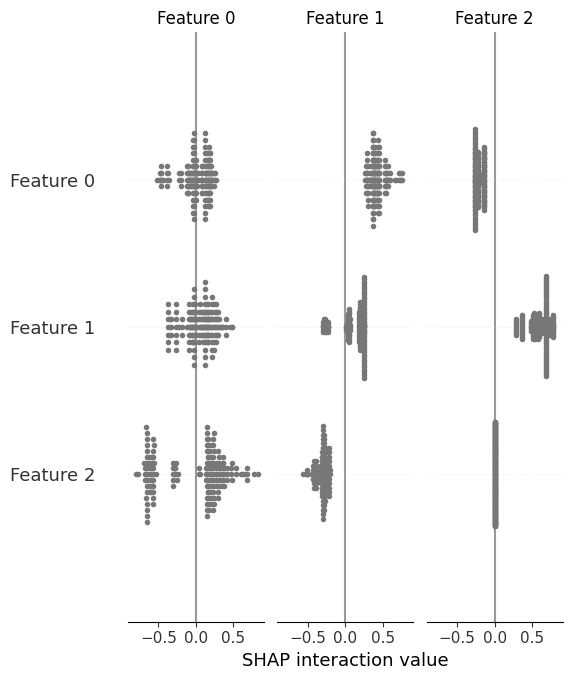

In [153]:
import shap
import joblib

from pathlib import Path
import joblib

MODEL_PATH = (
    Path("..")
    / "models"
    / "cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique.joblib"
)
#MODEL_PATH = (
#    Path("..")
#    / "models"
#    / "cisia_emploi_random_forest_multimodal_complet_balanced.joblib"
#)



print(MODEL_PATH.resolve())

pipeline = joblib.load(MODEL_PATH)



X, y = load_scenario_dataset(
    data_path=DATA_PATH,
    scenario_name="multimodal_ethique",
)

X_sample = X.sample(
    n=min(200, len(X)),
    random_state=42
)

import numpy as np
import shap

from scipy import sparse

preprocessor = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["classifier"]

# Transformation avec exactement le prétraitement appris pendant le train
X_transformed = preprocessor.transform(X_sample)

print("Type avant conversion :", type(X_transformed))
print("Dtype avant conversion :", getattr(X_transformed, "dtype", None))
print("Dimensions :", X_transformed.shape)

# SHAP TreeExplainer attend une matrice numérique dense
if sparse.issparse(X_transformed):
    X_transformed_numeric = X_transformed.toarray()
elif hasattr(X_transformed, "to_numpy"):
    X_transformed_numeric = X_transformed.to_numpy()
else:
    X_transformed_numeric = np.asarray(X_transformed)

X_transformed_numeric = X_transformed_numeric.astype(
    np.float64,
    copy=False,
)

print("Type après conversion :", type(X_transformed_numeric))
print("Dtype après conversion :", X_transformed_numeric.dtype)
print("Dimensions après conversion :", X_transformed_numeric.shape)

# Vérification avant SHAP
if not np.isfinite(X_transformed_numeric).all():
    raise ValueError(
        "La matrice transformée contient des valeurs NaN ou infinies."
    )

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_transformed_numeric,
    check_additivity=False,
)

shap.summary_plot(
    shap_values,
    X_transformed,
    show=True,
)

In [154]:
if isinstance(shap_values, list):
    # Anciennes versions de SHAP :
    # une matrice par classe
    shap_values_class_2 = shap_values[2]

else:
    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:
        # Versions récentes :
        # observations × variables × classes
        shap_values_class_2 = shap_array[:, :, 2]

    elif shap_array.ndim == 2:
        # Cas binaire ou sortie déjà limitée à une classe
        shap_values_class_2 = shap_array

    else:
        raise ValueError(
            f"Forme SHAP non reconnue : {shap_array.shape}"
        )

In [151]:
feature_names = (
    pipeline.named_steps["preprocess"]
    .get_feature_names_out()
)

print(len(feature_names))
print(feature_names[:10])


253
['num__anciennete_poste_ans' 'ord__niveau_diplome'
 'cat__code_rome_vise_A1202' 'cat__code_rome_vise_A1203'
 'cat__code_rome_vise_A1301' 'cat__code_rome_vise_A1401'
 'cat__code_rome_vise_A1501' 'cat__code_rome_vise_C1102'
 'cat__code_rome_vise_C1110' 'cat__code_rome_vise_C1201']


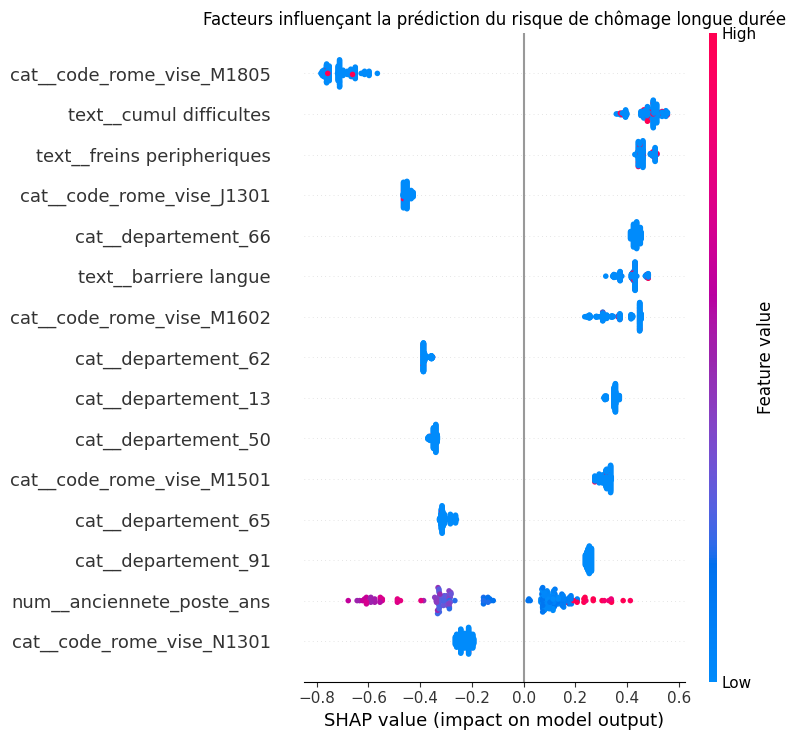

In [152]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values_class_2,
    X_transformed_numeric,
    feature_names=feature_names,
    max_display=15,
    show=False,
)

plt.title(
    "Facteurs influençant la prédiction du risque de chômage longue durée"
)

plt.tight_layout()
plt.show()

In [202]:
importance = np.abs(
    shap_values_class_2
).mean(axis=0)

top = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance,
    })
    .sort_values(
        "importance",
        ascending=False,
    )
)

top.head(20)

,feature,importance
0,num__anciennete_poste_ans,0.024026
118,text__moyen transport,0.008254
85,text__enfants complexe,0.007070
96,text__garde,0.006153
164,text__transport garde,0.006054
77,text__cumul,0.005751
81,text__difficultes pas,0.005746
109,text__majeurs situation,0.005494
38,cat__code_rome_vise_M1602,0.005458
80,text__difficultes,0.005406


### 7.2 Analyse des erreurs et stratégies de fallback

🎯 Identifier où le modèle échoue, et **concevoir le filet de sécurité** : que se passe-t-il quand le modèle a tort, ou qu'il ne sait pas ?

💡 Trois leviers de conception à documenter explicitement (la **surveillance** de ces seuils se traite en §9.4, pas ici) :

⚠️ Sans ces 3 éléments, ton modèle n'a pas de plan de fallback — il **n'est pas déployable en prod sur un usage à enjeu**. C'est un attendu C8 N3 (M6) et C7 N3 (M8). Le code ci-dessous analyse les erreurs résiduelles pour **informer** ces 3 choix (où placer le seuil, quels profils escalader).

In [ ]:
# 7.2 Analyse des erreurs et profils à escalader
# - Matrice de confusion détaillée par profil (variables sensibles incluses)
# - Distribution des probabilités prédites sur les erreurs : où placer le seuil de rejet ?
# - Caractérisation des profils faux positifs / faux négatifs : escalade humaine prioritaire ?

#### 7.2.1 Matrice de confusion détaillée par profil
Ce code analyse les erreurs du modèle sur le jeu de test à l’aide de matrices de confusion, d’abord globalement puis par profil : âge, nationalité, statut d’allocataire et niveau de diplôme. Cette comparaison aide à repérer d’éventuels écarts entre groupes, sans utiliser ces caractéristiques pour produire les prédictions. Les groupes de moins de 20 personnes sont masqués afin d’éviter les conclusions fragiles.

In [159]:
import json
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import confusion_matrix

# Utilise les index du holdout sauvegardés avec le modèle.
metadata_path = MODEL_PATH.with_suffix(".json")
metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
holdout_indices = metadata["dataset"]["test_indices"]

indices_absents = pd.Index(holdout_indices).difference(X.index)
if len(indices_absents):
    raise ValueError(
        f"{len(indices_absents)} index du holdout sont absents de X."
    )

X_holdout = X.loc[holdout_indices]
y_true = y.loc[holdout_indices].astype(int)
y_pred = pipeline.predict(X_holdout).astype(int)
labels = [0, 1, 2]

# Matrice globale : lignes = classe réelle, colonnes = classe prédite.
matrice_globale = pd.DataFrame(
    confusion_matrix(y_true, y_pred, labels=labels),
    index=[f"Réel {label}" for label in labels],
    columns=[f"Prédit {label}" for label in labels],
)
print(f"Matrice globale sur le holdout (n={len(y_true)})")
display(matrice_globale)

# Les attributs servent à l'audit agrégé, pas à la prédiction.
profils = pd.read_csv(
    DATA_PATH,
    usecols=[
        "age",
        "nationalite_hors_ue",
        "est_allocataire",
        "niveau_diplome",
    ],
).loc[holdout_indices].copy()

profils["tranche_age"] = pd.cut(
    pd.to_numeric(profils["age"], errors="coerce"),
    bins=[0, 25, 45, np.inf],
    labels=["25 ans ou moins", "26 à 45 ans", "Plus de 45 ans"],
    include_lowest=True,
).astype("string").fillna("Non renseigné")

nationalite = pd.to_numeric(
    profils["nationalite_hors_ue"],
    errors="coerce",
)
profils["nationalite_audit"] = nationalite.map(
    {0: "Non hors UE", 1: "Hors UE"}
).fillna("Non renseignée")

allocataire = pd.to_numeric(
    profils["est_allocataire"],
    errors="coerce",
)
profils["allocataire_audit"] = allocataire.map(
    {0: "Non allocataire", 1: "Allocataire"}
).fillna("Non renseigné")

profils["niveau_diplome_audit"] = (
    profils["niveau_diplome"]
    .astype("string")
    .fillna("Non renseigné")
)

audit = profils[
    [
        "tranche_age",
        "nationalite_audit",
        "allocataire_audit",
        "niveau_diplome_audit",
    ]
].copy()
audit["réel"] = y_true
audit["prédit"] = y_pred

# Masque les groupes trop petits pour éviter des conclusions fragiles.
TAILLE_MIN_GROUPE = 20

for colonne, nom_profil in [
    ("tranche_age", "Âge"),
    ("nationalite_audit", "Nationalité"),
    ("allocataire_audit", "Statut allocataire"),
    ("niveau_diplome_audit", "Niveau de diplôme"),
]:
    print(f"\nMatrices de confusion par profil : {nom_profil}")

    for valeur, groupe in audit.groupby(
        colonne,
        observed=True,
        dropna=False,
        sort=True,
    ):
        if len(groupe) < TAILLE_MIN_GROUPE:
            print(f"{valeur} : résultats masqués (n={len(groupe)} < 20)")
            continue

        matrice = pd.DataFrame(
            confusion_matrix(
                groupe["réel"],
                groupe["prédit"],
                labels=labels,
            ),
            index=[f"Réel {label}" for label in labels],
            columns=[f"Prédit {label}" for label in labels],
        )

        print(f"\n{valeur} (n={len(groupe)})")
        display(matrice)

Matrice globale sur le holdout (n=500)


,Prédit 0,Prédit 1,Prédit 2
Réel 0,123,36,28
Réel 1,33,151,39
Réel 2,7,25,58



Matrices de confusion par profil : Âge

25 ans ou moins (n=84)


,Prédit 0,Prédit 1,Prédit 2
Réel 0,23,9,5
Réel 1,5,24,7
Réel 2,0,1,10



26 à 45 ans (n=199)


...

,Prédit 0,Prédit 1,Prédit 2
Réel 0,28,10,4
Réel 1,9,32,6
Réel 2,2,3,8



Bac+5 (n=105)


,Prédit 0,Prédit 1,Prédit 2
Réel 0,48,12,4
Réel 1,6,27,1
Réel 2,1,2,4


Non renseigné : résultats masqués (n=16 < 20)

Sans diplôme (n=90)


,Prédit 0,Prédit 1,Prédit 2
Réel 0,2,2,5
Réel 1,1,29,16
Réel 2,0,8,27


In [160]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from IPython.display import display

labels = [0, 1, 2]
profils = [
    "tranche_age",
    "nationalite_audit",
    "allocataire_audit",
    "niveau_diplome_audit",
]
taille_min_groupe = 20


def calculer_metriques(cm):
    """Calcule les métriques à partir d'une matrice réel × prédit."""
    total = cm.sum()
    supports_reels = cm.sum(axis=1)
    supports_predits = cm.sum(axis=0)
    vrais_positifs = np.diag(cm)

    precision = np.divide(
        vrais_positifs,
        supports_predits,
        out=np.zeros(3, dtype=float),
        where=supports_predits != 0,
    )
    rappel = np.divide(
        vrais_positifs,
        supports_reels,
        out=np.zeros(3, dtype=float),
        where=supports_reels != 0,
    )
    f1 = np.divide(
        2 * precision * rappel,
        precision + rappel,
        out=np.zeros(3, dtype=float),
        where=(precision + rappel) != 0,
    )

    return {
        "accuracy": np.trace(cm) / total if total else np.nan,
        "f1_macro": f1.mean(),
        "precision_macro": precision.mean(),
        "rappel_macro": rappel.mean(),
        "rappel_classe_2": rappel[2],
        "erreurs_2_vers_0": int(cm[2, 0]),
        "taux_2_vers_0": (
            cm[2, 0] / supports_reels[2]
            if supports_reels[2] else np.nan
        ),
        "erreurs_0_vers_2": int(cm[0, 2]),
        "taux_0_vers_2": (
            cm[0, 2] / supports_reels[0]
            if supports_reels[0] else np.nan
        ),
    }


lignes = []
matrices_par_profil = {}

for profil in profils:
    for valeur, groupe in audit.groupby(
        profil,
        observed=True,
        dropna=False,
        sort=True,
    ):
        ligne = {
            "profil": profil,
            "groupe": str(valeur),
            "effectif": len(groupe),
        }

        if len(groupe) < taille_min_groupe:
            ligne["statut"] = f"Masqué (moins de {taille_min_groupe})"
            lignes.append(ligne)
            continue

        cm = confusion_matrix(
            groupe["réel"],
            groupe["prédit"],
            labels=labels,
        )
        matrices_par_profil[(profil, str(valeur))] = cm

        ligne.update(calculer_metriques(cm))
        ligne["statut"] = "Calculé"
        lignes.append(ligne)

table_metriques = pd.DataFrame(lignes)
display(table_metriques.round(3))

,profil,groupe,effectif,accuracy,f1_macro,precision_macro,rappel_macro,rappel_classe_2,erreurs_2_vers_0,taux_2_vers_0,erreurs_0_vers_2,taux_0_vers_2,statut
0,tranche_age,25 ans ou moins,84,0.679,0.666,0.661,0.732,0.909,0.0,0.000,5.0,0.135,Calculé
1,tranche_age,26 à 45 ans,199,0.668,0.590,0.594,0.661,0.643,3.0,0.214,16.0,0.154,Calculé
2,tranche_age,Non renseigné,22,0.773,0.748,0.744,0.757,0.800,0.0,0.000,0.0,0.000,Calculé
3,tranche_age,Plus de 45 ans,195,0.641,0.616,0.614,0.621,0.583,4.0,0.067,7.0,0.194,Calculé
4,nationalite_audit,Hors UE,56,0.625,0.622,0.617,0.646,0.650,2.0,0.100,2.0,0.182,Calculé
5,nationalite_audit,Non hors UE,444,0.669,0.643,0.641,0.663,0.643,5.0,0.071,26.0,0.148,Calculé
6,allocataire_audit,Allocataire,286,0.675,0.651,0.648,0.670,0.652,3.0,0.065,18.0,0.155,Calculé
7,allocataire_audit,Non allocataire,208,0.654,0.642,0.642,0.652,0.636,4.0,0.091,10.0,0.145,Calculé
8,allocataire_audit,Non renseigné,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Masqué (moins de 20)
9,niveau_diplome_audit,Bac,187,0.642,0.611,0.611,0.624,0.562,4.0,0.125,14.0,0.209,Calculé


Évaluation détectée : audit (réel / prédit)
Info : aucune colonne secteur d'activité explicite trouvée ; la famille ROME sert de proxy.
Colonnes utilisées : {'Code ROME visé': 'Code ROME visé', 'Département': 'Département', 'Famille ROME (proxy de secteur)': 'Secteur'}

Métriques par modalité (effectif >= 20)


,dimension,modalité,effectif,accuracy,recall_macro,recall_classe_2,taux_erreur_2_vers_0,taux_erreur_0_vers_2
0,Code ROME visé,K1304,20,0.650,0.698,0.750,0.000,0.182
1,Famille ROME (proxy de secteur),A,56,0.786,0.750,0.818,0.000,0.250
2,Famille ROME (proxy de secteur),C,52,0.635,0.677,0.800,0.000,0.148
3,Famille ROME (proxy de secteur),D,45,0.711,0.710,0.667,0.000,0.062
4,Famille ROME (proxy de secteur),G,50,0.620,0.615,0.500,0.167,0.083
5,Famille ROME (proxy de secteur),H,39,0.564,0.489,0.400,0.000,0.300
6,Famille ROME (proxy de secteur),K,88,0.682,0.679,0.667,0.111,0.143
7,Famille ROME (proxy de secteur),M,72,0.597,0.531,0.300,0.400,0.139
8,Famille ROME (proxy de secteur),N,53,0.679,0.696,0.667,0.000,0.261



Top 10 — Plus fort taux d'erreur 2→0


,dimension,modalité,effectif,accuracy,recall_macro,recall_classe_2,taux_erreur_2_vers_0,taux_erreur_0_vers_2
7,Famille ROME (proxy de secteur),M,72,0.597,0.531,0.300,0.400,0.139
4,Famille ROME (proxy de secteur),G,50,0.620,0.615,0.500,0.167,0.083
6,Famille ROME (proxy de secteur),K,88,0.682,0.679,0.667,0.111,0.143
0,Code ROME visé,K1304,20,0.650,0.698,0.750,0.000,0.182
1,Famille ROME (proxy de secteur),A,56,0.786,0.750,0.818,0.000,0.250
3,Famille ROME (proxy de secteur),D,45,0.711,0.710,0.667,0.000,0.062
2,Famille ROME (proxy de secteur),C,52,0.635,0.677,0.800,0.000,0.148
5,Famille ROME (proxy de secteur),H,39,0.564,0.489,0.400,0.000,0.300
8,Famille ROME (proxy de secteur),N,53,0.679,0.696,0.667,0.000,0.261



Top 10 — Plus fort taux d'erreur 0→2


...

,Hors profil,Dans le profil,effectif,part_dans_profil,prévalence_globale,surreprésentation
Code ROME visé,,,,,,
K1304,17,3,20,0.15,0.112,1.339



Croisement : Hors UE × Département
Surreprésentation > 1 : part du profil supérieure à sa prévalence globale.


,Hors profil,Dans le profil,effectif,part_dans_profil,prévalence_globale,surreprésentation
Département,,,,,,



Croisement : Hors UE × Famille ROME (proxy de secteur)
Surreprésentation > 1 : part du profil supérieure à sa prévalence globale.


,Hors profil,Dans le profil,effectif,part_dans_profil,prévalence_globale,surreprésentation
Secteur,,,,,,
A,46,10,56,0.179,0.112,1.594
K,73,15,88,0.170,0.112,1.522
M,65,7,72,0.097,0.112,0.868
C,47,5,52,0.096,0.112,0.859
G,46,4,50,0.080,0.112,0.714
H,36,3,39,0.077,0.112,0.687
N,50,3,53,0.057,0.112,0.505
D,43,2,45,0.044,0.112,0.397


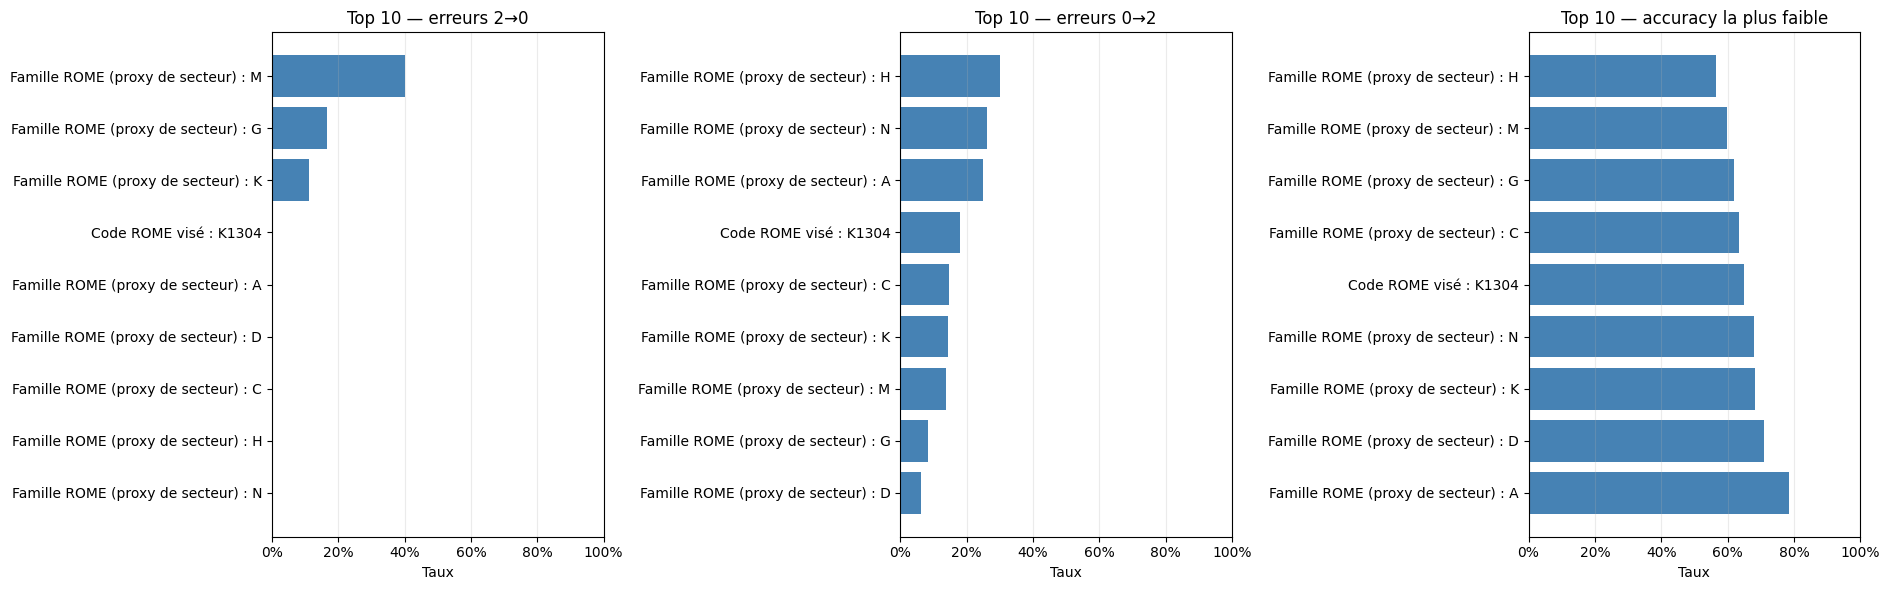

In [169]:
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from sklearn.metrics import confusion_matrix, recall_score


def normaliser_nom(nom):
    texte = unicodedata.normalize("NFKD", str(nom)).casefold()
    return "".join(caractere for caractere in texte if caractere.isalnum())


def trouver_colonne(colonnes, alias):
    par_nom_normalise = {
        normaliser_nom(colonne): colonne
        for colonne in colonnes
    }
    for nom in alias:
        colonne = par_nom_normalise.get(normaliser_nom(nom))
        if colonne is not None:
            return colonne
    return None


# Repère automatiquement le DataFrame d'évaluation et ses colonnes réel/prédit.
alias_reel = [
    "y_true", "y_test", "réel", "reel", "classe_reelle",
    "true_label", "actual",
]
alias_predit = [
    "y_pred", "prediction", "prédit", "predit",
    "classe_predite", "predicted", "pred_label",
]

dataframes = [
    (nom, objet)
    for nom, objet in list(globals().items())
    if isinstance(objet, pd.DataFrame)
]
priorite = {"df_eval": 0, "evaluation_df": 1, "eval_df": 2, "audit": 3}
dataframes.sort(key=lambda element: priorite.get(element[0], 10))

evaluation_trouvee = None
for nom, frame in dataframes:
    colonne_reelle = trouver_colonne(frame.columns, alias_reel)
    colonne_predite = trouver_colonne(frame.columns, alias_predit)
    if colonne_reelle is not None and colonne_predite is not None:
        evaluation_trouvee = (
            nom, frame, colonne_reelle, colonne_predite
        )
        break

if evaluation_trouvee is None:
    raise ValueError(
        "Aucun DataFrame d'évaluation avec une colonne réelle et une "
        "colonne prédite n'a été trouvé. Attendu, par exemple : "
        "audit avec les colonnes 'réel' et 'prédit'."
    )

nom_evaluation, frame_evaluation, colonne_reelle, colonne_predite = (
    evaluation_trouvee
)
print(
    f"Évaluation détectée : {nom_evaluation} "
    f"({colonne_reelle} / {colonne_predite})"
)

# Utilise le DataFrame réel du notebook pour récupérer les colonnes métier.
donnees = globals().get("df")
if not isinstance(donnees, pd.DataFrame):
    raise ValueError(
        "Le DataFrame source 'df' est introuvable. "
        "Exécute d'abord les cellules de chargement des données."
    )

if frame_evaluation.index.has_duplicates:
    raise ValueError("Les index du DataFrame d'évaluation ne sont pas uniques.")

index_absents = frame_evaluation.index.difference(donnees.index)
if len(index_absents):
    raise ValueError(
        f"{len(index_absents)} index d'évaluation ne sont pas présents dans df."
    )

source_evaluation = donnees.loc[frame_evaluation.index].copy()
evaluation = pd.DataFrame(index=frame_evaluation.index)
evaluation["réel"] = pd.to_numeric(
    frame_evaluation[colonne_reelle], errors="raise"
).astype(int)
evaluation["prédit"] = pd.to_numeric(
    frame_evaluation[colonne_predite], errors="raise"
).astype(int)

# Détecte les colonnes ROME, département et secteur.
col_rome = trouver_colonne(
    source_evaluation.columns,
    ["code_rome_vise", "code_rome", "rome"],
)
if col_rome is None:
    raise ValueError("Colonne du code ROME visé introuvable dans df.")

col_departement = trouver_colonne(
    source_evaluation.columns,
    ["departement", "code_departement", "department"],
)

if col_departement is None:
    col_insee = trouver_colonne(
        source_evaluation.columns,
        ["code_insee_commune", "code_insee"],
    )
    if col_insee is None:
        raise ValueError(
            "Colonne départementale et code INSEE introuvables dans df."
        )

    def extraire_departement(code):
        if pd.isna(code):
            return "Non renseigné"
        code = str(code).strip().upper()
        if code.startswith(("2A", "2B")):
            return code[:2]
        if code.isdigit():
            code = code.zfill(5)
        return code[:3] if code.startswith("97") else code[:2]

    evaluation["Département"] = source_evaluation[col_insee].map(
        extraire_departement
    )
else:
    evaluation["Département"] = source_evaluation[col_departement]

col_secteur = trouver_colonne(
    source_evaluation.columns,
    [
        "secteur_activite", "secteur", "secteur_emploi",
        "industry_sector",
    ],
)

if col_secteur is not None:
    evaluation["Secteur"] = source_evaluation[col_secteur]
    libelle_secteur = f"Secteur ({col_secteur})"
else:
    col_famille = trouver_colonne(
        source_evaluation.columns,
        ["code_rome_famille", "famille_rome"],
    )
    if col_famille is not None:
        evaluation["Secteur"] = source_evaluation[col_famille]
    else:
        evaluation["Secteur"] = (
            source_evaluation[col_rome]
            .astype("string")
            .str[0]
        )
    libelle_secteur = "Famille ROME (proxy de secteur)"
    print(
        "Info : aucune colonne secteur d'activité explicite trouvée ; "
        "la famille ROME sert de proxy."
    )

evaluation["Code ROME visé"] = source_evaluation[col_rome]

for colonne in ["Département", "Secteur", "Code ROME visé"]:
    evaluation[colonne] = (
        evaluation[colonne].astype("string").fillna("Non renseigné")
    )

dimensions = {
    "Code ROME visé": "Code ROME visé",
    "Département": "Département",
    libelle_secteur: "Secteur",
}
print("Colonnes utilisées :", dimensions)


# Calcule les métriques à partir des matrices réel × prédit.
labels = [0, 1, 2]
seuil_effectif = 20
lignes_metriques = []

for dimension, colonne in dimensions.items():
    for modalite, groupe in evaluation.groupby(
        colonne, observed=True, dropna=False, sort=True
    ):
        effectif = len(groupe)
        if effectif < seuil_effectif:
            continue

        matrice = confusion_matrix(
            groupe["réel"], groupe["prédit"], labels=labels
        )
        rappel_par_classe = recall_score(
            groupe["réel"],
            groupe["prédit"],
            labels=labels,
            average=None,
            zero_division=0,
        )
        support_reel = matrice.sum(axis=1)

        lignes_metriques.append(
            {
                "dimension": dimension,
                "modalité": str(modalite),
                "effectif": effectif,
                "accuracy": np.trace(matrice) / effectif,
                "recall_macro": rappel_par_classe.mean(),
                "recall_classe_2": rappel_par_classe[2],
                "taux_erreur_2_vers_0": (
                    matrice[2, 0] / support_reel[2]
                    if support_reel[2] else np.nan
                ),
                "taux_erreur_0_vers_2": (
                    matrice[0, 2] / support_reel[0]
                    if support_reel[0] else np.nan
                ),
            }
        )

metriques_groupes = pd.DataFrame(lignes_metriques)
if metriques_groupes.empty:
    raise ValueError(
        "Aucun groupe n'atteint l'effectif minimal de 20 observations."
    )

print(f"\nMétriques par modalité (effectif >= {seuil_effectif})")
display(metriques_groupes.round(3))


# Affiche les groupes les plus problématiques.
classements = {
    "Plus fort taux d'erreur 2→0": (
        "taux_erreur_2_vers_0", False
    ),
    "Plus fort taux d'erreur 0→2": (
        "taux_erreur_0_vers_2", False
    ),
    "Plus faible accuracy": ("accuracy", True),
}

for titre, (metrique, croissant) in classements.items():
    print(f"\nTop 10 — {titre}")
    tableau = metriques_groupes.dropna(subset=[metrique]).sort_values(
        metrique, ascending=croissant
    ).head(10)
    display(tableau.round(3))


# Croisements descriptifs : part du profil dans chaque modalité.
def normaliser_valeur(valeur):
    texte = unicodedata.normalize("NFKD", str(valeur)).casefold()
    return "".join(
        caractere for caractere in texte
        if caractere.isalnum() or caractere.isspace()
    ).strip()


col_age = trouver_colonne(source_evaluation.columns, ["age"])
col_diplome = trouver_colonne(
    source_evaluation.columns, ["niveau_diplome", "diplome"]
)
col_nationalite = trouver_colonne(
    source_evaluation.columns,
    ["nationalite_hors_ue", "hors_ue"],
)

if col_age is None or col_diplome is None or col_nationalite is None:
    raise ValueError(
        "Impossible de trouver dans df l'âge, le diplôme ou la nationalité "
        "nécessaires aux tableaux croisés."
    )

age = pd.to_numeric(source_evaluation[col_age], errors="coerce")
diplome = source_evaluation[col_diplome]
nationalite = source_evaluation[col_nationalite]

hors_ue_texte = nationalite.astype("string").map(normaliser_valeur)
nationalite_num = pd.to_numeric(nationalite, errors="coerce")

profils = {
    "26–45 ans": age.between(26, 45, inclusive="both").where(age.notna()),
    "Sans diplôme": diplome.astype("string").map(
        lambda valeur: (
            normaliser_valeur(valeur) == "sans diplome"
            if pd.notna(valeur) else pd.NA
        )
    ).astype("boolean"),
    "Hors UE": (
        (nationalite_num == 1)
        | hors_ue_texte.isin(["hors ue", "oui", "true"])
    ).where(nationalite.notna()),
}

tableaux_croises = {}
for nom_profil, indicateur in profils.items():
    indicateur = pd.Series(
        indicateur, index=evaluation.index, dtype="boolean"
    )
    lignes_valides = indicateur.notna()
    indicateur = indicateur.loc[lignes_valides].astype(bool)

    for dimension, colonne in dimensions.items():
        modalites = evaluation.loc[lignes_valides, colonne].fillna(
            "Non renseigné"
        )
        croise = pd.crosstab(modalites, indicateur).reindex(
            columns=[False, True], fill_value=0
        )
        croise.columns = ["Hors profil", "Dans le profil"]
        croise["effectif"] = croise.sum(axis=1)
        croise["part_dans_profil"] = (
            croise["Dans le profil"] / croise["effectif"]
        )

        prevalence_globale = indicateur.mean()
        croise["prévalence_globale"] = prevalence_globale
        croise["surreprésentation"] = (
            croise["part_dans_profil"] / prevalence_globale
            if prevalence_globale else np.nan
        )

        tableaux_croises[(nom_profil, dimension)] = croise
        admissibles = croise[croise["effectif"] >= seuil_effectif]

        print(f"\nCroisement : {nom_profil} × {dimension}")
        print(
            "Surreprésentation > 1 : part du profil supérieure à sa "
            "prévalence globale."
        )
        display(
            admissibles.sort_values(
                "surreprésentation", ascending=False
            ).head(10).round(3)
        )


# Graphiques des dix groupes les plus problématiques pour chaque indicateur.
graphiques = [
    (
        "taux_erreur_2_vers_0",
        "Top 10 — erreurs 2→0",
    ),
    (
        "taux_erreur_0_vers_2",
        "Top 10 — erreurs 0→2",
    ),
    (
        "accuracy",
        "Top 10 — accuracy la plus faible",
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (metrique, titre) in zip(axes, graphiques):
    croissant = metrique == "accuracy"
    top = (
        metriques_groupes.dropna(subset=[metrique])
        .sort_values(metrique, ascending=croissant)
        .head(10)
        .copy()
    )
    top["groupe"] = top["dimension"] + " : " + top["modalité"]

    ax.barh(top["groupe"], top[metrique], color="steelblue")
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_title(titre)
    ax.set_xlabel("Taux")
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## Observations

**Analyse par sous-groupe**

L'analyse des performances par sous-groupe met en évidence deux signaux de vigilance principaux, chacun correspondant à un mécanisme d'erreur différent.

**Tranche d'âge 26-45 ans**

Cette tranche d'âge présente le taux d'erreur **2→0** le plus élevé des sous-populations analysées (**21,4 %**, contre **7,8 %** sur l'ensemble du jeu de test), soit près de trois fois la moyenne observée.

Ce résultat mérite une attention particulière car cette tranche d'âge représente près de **40 % de l'échantillon total** (199 individus sur 500) et ne correspond donc pas à un sous-groupe marginal.

Toutefois, cette estimation repose sur seulement **14 observations réelles de classe 2**, dont 3 ont été classées à tort en classe 0. Une validation statistique complémentaire est nécessaire afin de déterminer si cet écart reflète un comportement systématique du modèle ou une fluctuation liée à l'échantillonnage.

L'analyse complémentaire des variables métier montre que ce groupe est davantage représenté dans certaines familles ROME, notamment les familles **M** et **C**. Or la famille **M** présente les performances les plus faibles parmi les secteurs analysés, avec une accuracy de **59,7 %**, un rappel de la classe 2 de **30 %** et un taux d'erreur **2→0 de 40 %**. Une partie des difficultés observées pour les 26-45 ans pourrait donc être liée à la répartition de ce groupe dans des métiers plus difficiles à prédire plutôt qu'à l'âge lui-même.

**Profil « Sans diplôme »**

Le groupe **Sans diplôme** présente un comportement inverse.

Aucun individu réellement en classe 2 n'est classé en classe 0 (**taux 2→0 = 0 %**), mais le modèle attribue fréquemment la classe 2 à des individus appartenant en réalité à la classe 0.

Le taux d'erreur **0→2** atteint **55,6 %**, contre **6 % à 21 %** pour les autres sous-populations analysées. Cela signifie que plus d'un individu sur deux appartenant réellement à la classe 0 est orienté vers la classe 2.

Ce résultat doit néanmoins être interprété avec prudence puisqu'il repose sur seulement **9 observations réelles de classe 0**, dont 5 erreurs.

L'analyse des familles ROME met en évidence une forte surreprésentation de ce groupe dans la famille **H**, dont les performances figurent parmi les plus faibles de l'échantillon (accuracy de **56,4 %**, rappel macro de **48,9 %** et taux d'erreur **0→2 de 30 %**). Cette concentration sectorielle constitue une explication plausible du niveau élevé de faux positifs observé pour ce sous-groupe.

**Nationalité « Hors UE »**

Un léger écart est observé sur l'erreur **2→0** entre les personnes identifiées comme hors UE (**10,0 %**) et le reste de la population (**7,1 %**).

Compte tenu de l'ampleur limitée de cet écart et de la taille réduite du sous-échantillon concerné, ces résultats ne permettent pas de conclure à l'existence d'une discrimination indirecte.

Par ailleurs, l'analyse des familles ROME ne met pas en évidence de concentration des personnes hors UE dans les secteurs présentant les plus faibles performances du modèle. Les écarts observés apparaissent donc limités et aucun mécanisme indirect clair n'a pu être identifié à ce stade.

**Autres sous-groupes**

Les performances observées selon le statut allocataire ainsi que pour la majorité des autres catégories d'âge et de diplôme restent globalement cohérentes avec la performance moyenne du modèle.

Des écarts de performance subsistent néanmoins, notamment dans la capacité à reconnaître correctement la classe 2 selon certaines tranches d'âge ou de diplôme, sans apparaître aussi marqués que les deux signaux précédemment identifiés.

**Conclusion**

Les deux signaux identifiés concernent des risques différents :

- **26-45 ans** : risque accru de non-détection des individus appartenant réellement à la classe 2 (erreurs **2→0**) ;
- **Sans diplôme** : risque accru de sur-attribution de la classe 2 (erreurs **0→2**).

Les analyses complémentaires suggèrent toutefois que ces écarts sont **au moins partiellement liés à la répartition des individus dans certaines familles de métiers où le modèle présente des performances plus faibles**. Cette observation réduit l'hypothèse d'un biais directement associé aux caractéristiques des personnes et oriente davantage vers un effet de structure des données.

Ces résultats constituent donc des **signaux de vigilance** plutôt qu'une démonstration de biais avéré. Une validation statistique complémentaire (test exact de Fisher ou intervalles de confiance adaptés) est recommandée afin de confirmer la robustesse des écarts observés avant toute décision corrective.

#### 7.2.2 Préparation : jeu de calibration distinct du holdout

In [81]:
# Le holdout ne sert qu'une fois, pour le chiffre final : régler le seuil dessus le contaminerait.
import sys
import json
from pathlib import Path

import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split

EXAMEN_DIR = Path("..").resolve()
if str(EXAMEN_DIR / "src") not in sys.path:
    sys.path.insert(0, str(EXAMEN_DIR / "src"))

from config import DATA_PATH, RANDOM_STATE, TEST_SIZE
from train import fit_pipeline_with_text_fallback, load_scenario_dataset, split_train_holdout

MODEL_TYPE = "xgboost"
SCENARIO_NAME = "multimodal_ethique"
CONFIG_NAME = "best_class_2_ethique"
MODEL_PATH = EXAMEN_DIR / "models" / f"cisia_emploi_{MODEL_TYPE}_{SCENARIO_NAME}_{CONFIG_NAME}.joblib"

# --- Étape 1 : même split train/holdout que train.py ---
# Mêmes TEST_SIZE / RANDOM_STATE / stratification pour retrouver exactement le holdout du modèle.
X, y = load_scenario_dataset(data_path=DATA_PATH, scenario_name=SCENARIO_NAME)
y = y.astype(int)
X_train_full, X_holdout, y_train_full, y_holdout = split_train_holdout(
    X=X, y=y, test_size=TEST_SIZE, random_state=RANDOM_STATE,
)

metadata = json.loads(MODEL_PATH.with_suffix(".json").read_text(encoding="utf-8"))
holdout_indices = metadata["dataset"]["test_indices"]
if set(X_holdout.index) != set(holdout_indices):
    raise ValueError("Le holdout recalculé ne correspond pas aux test_indices des métadonnées.")
print(f"Holdout vérifié : identique aux métadonnées (n={len(X_holdout)})")

# --- Étape 2 : second découpage du train pour isoler un jeu de calibration ---
# Le modèle ne doit pas voir ces lignes à l'entraînement, sinon ses probabilités y seraient trop optimistes.
X_train_fit, X_calibration, y_train_fit, y_calibration = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20, stratify=y_train_full, random_state=RANDOM_STATE,
)
print(f"Train fit : n={len(X_train_fit)} | Calibration : n={len(X_calibration)} | Holdout : n={len(X_holdout)}")

# --- Étape 3 : même pipeline et mêmes hyperparamètres, entraîné sur X_train_fit uniquement ---
# Le modèle sauvegardé a vu tout X_train_full, dont X_calibration : on ne peut pas le réutiliser ici.
pipeline_fit, _ = fit_pipeline_with_text_fallback(
    model_type=MODEL_TYPE, scenario_name=SCENARIO_NAME, config_name=CONFIG_NAME,
    X_train=X_train_fit, y_train=y_train_fit,
)

# --- Étape 4 : calibration isotonique ajustée sur X_calibration ---
# Les probabilités brutes de XGBoost pondéré ne sont pas des fréquences fiables : on les calibre avant de fixer un seuil.
try:
    from sklearn.frozen import FrozenEstimator  # scikit-learn >= 1.6
    calibrated_model = CalibratedClassifierCV(FrozenEstimator(pipeline_fit), method="isotonic")
except ImportError:
    calibrated_model = CalibratedClassifierCV(pipeline_fit, method="isotonic", cv="prefit")
calibrated_model.fit(X_calibration, y_calibration)
print("Modèle calibré (isotonique) prêt.")

Holdout vérifié : identique aux métadonnées (n=500)
Train fit : n=1600 | Calibration : n=400 | Holdout : n=500
Modèle calibré (isotonique) prêt.


Calibration : n=400 | erreurs=138 | erreurs critiques 2→0=14


,count,mean,std,min,25%,50%,75%,max
erreur,,,,,,,,
False,262.0,0.721,0.148,0.362,0.649,0.730,0.834,1.000
True,138.0,0.563,0.162,0.340,0.417,0.512,0.702,0.918


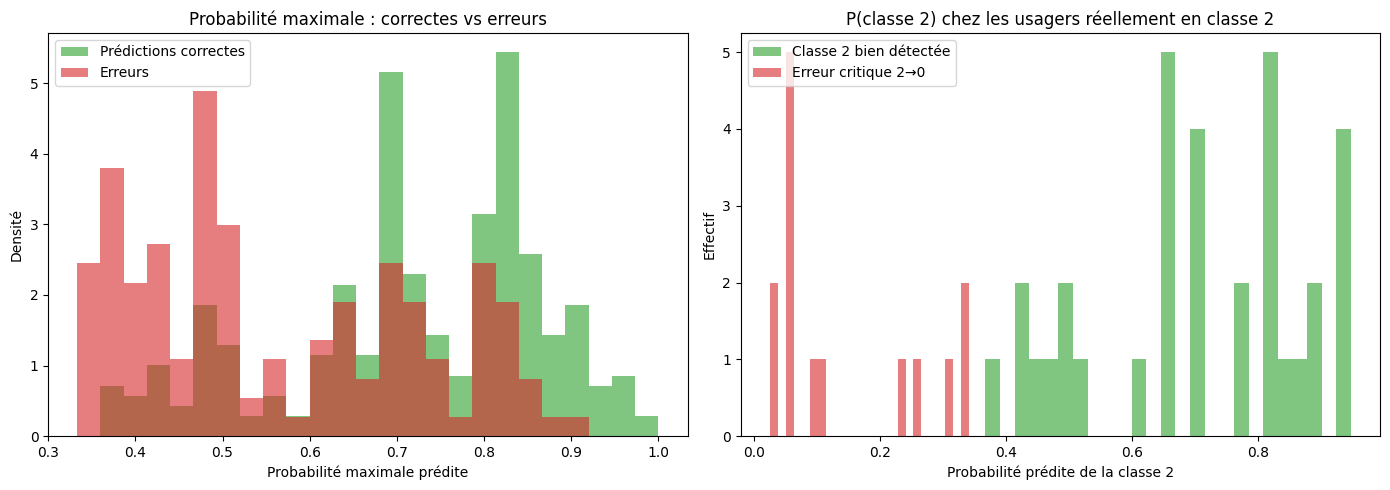

In [82]:
# Distribution des probabilités prédites sur les erreurs : détermination du seuil de rejet
# Étape 5 : toute l'analyse se fait sur X_calibration, jamais sur X_holdout.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

proba = calibrated_model.predict_proba(X_calibration)
classes = list(calibrated_model.classes_)
idx_c2 = classes.index(2)
y_pred_calibration = np.asarray(classes)[proba.argmax(axis=1)].astype(int)

analyse = pd.DataFrame({
    "réel": y_calibration.to_numpy(),
    "prédit": y_pred_calibration,
    "p_max": proba.max(axis=1),
    "p_classe_2": proba[:, idx_c2],
}, index=X_calibration.index)
analyse["erreur"] = analyse["réel"] != analyse["prédit"]
analyse["erreur_2_vers_0"] = (analyse["réel"] == 2) & (analyse["prédit"] == 0)

print(f"Calibration : n={len(analyse)} | erreurs={analyse['erreur'].sum()} "
      f"| erreurs critiques 2→0={analyse['erreur_2_vers_0'].sum()}")
display(analyse.groupby("erreur")["p_max"].describe().round(3))

# --- 1) Distribution de la confiance : prédictions correctes vs erreurs ---
bins = np.linspace(1 / len(classes), 1, 26)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(analyse.loc[~analyse["erreur"], "p_max"], bins=bins, alpha=0.6,
             density=True, label="Prédictions correctes", color="tab:green")
axes[0].hist(analyse.loc[analyse["erreur"], "p_max"], bins=bins, alpha=0.6,
             density=True, label="Erreurs", color="tab:red")
axes[0].set_title("Probabilité maximale : correctes vs erreurs")
axes[0].set_xlabel("Probabilité maximale prédite")
axes[0].set_ylabel("Densité")
axes[0].legend()

# Focus classe 2 : probabilité de la classe 2 chez les vrais classe 2
vrais_c2 = analyse[analyse["réel"] == 2]
axes[1].hist(vrais_c2.loc[vrais_c2["prédit"] == 2, "p_classe_2"], bins=25, alpha=0.6,
             label="Classe 2 bien détectée", color="tab:green")
axes[1].hist(vrais_c2.loc[vrais_c2["erreur_2_vers_0"], "p_classe_2"], bins=25, alpha=0.6,
             label="Erreur critique 2→0", color="tab:red")
axes[1].set_title("P(classe 2) chez les usagers réellement en classe 2")
axes[1].set_xlabel("Probabilité prédite de la classe 2")
axes[1].set_ylabel("Effectif")
axes[1].legend()
plt.tight_layout()
plt.show()

,seuil,taux_abstention,accuracy_acceptés,erreurs_captées,2→0_restantes,taux_2→0_restant
0,0.350000,1.0%,66.2%,2.9%,14,19.4%
1,0.400000,8.5%,69.7%,19.6%,11,15.3%
2,0.450000,15.5%,72.2%,31.9%,11,15.3%
3,0.500000,24.2%,75.9%,47.1%,8,11.1%
4,0.550000,30.0%,78.2%,55.8%,6,8.3%
5,0.600000,32.5%,78.9%,58.7%,6,8.3%
6,0.650000,39.5%,81.0%,66.7%,6,8.3%
7,0.700000,48.0%,80.3%,70.3%,6,8.3%
8,0.750000,64.5%,84.5%,84.1%,2,2.8%
9,0.800000,67.0%,85.6%,86.2%,1,1.4%


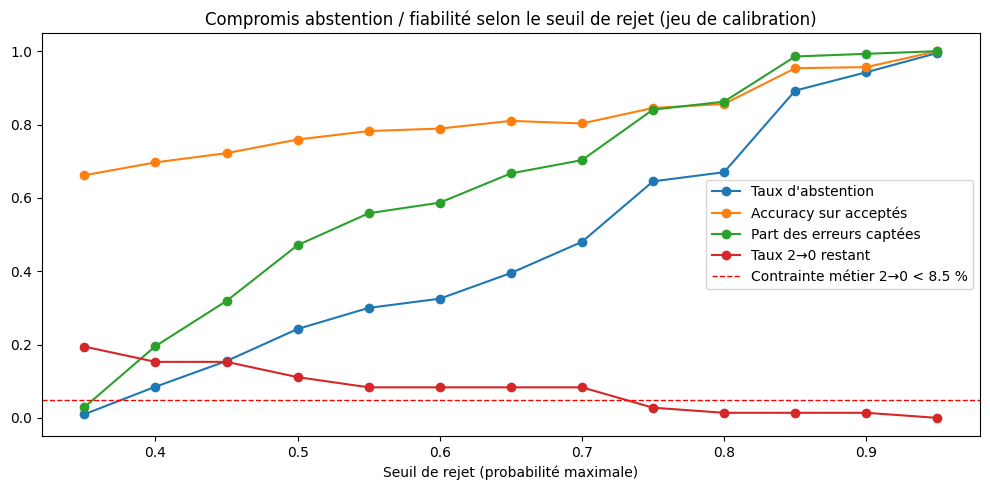

In [83]:
# --- 2) Balayage des seuils de rejet sur la probabilité maximale ---
# `analyse` provient de X_calibration : le seuil est choisi sans jamais regarder le holdout.
n_total = len(analyse)
n_c2 = int((analyse["réel"] == 2).sum())
resultats = []
for seuil in np.round(np.arange(0.35, 0.96, 0.05), 2):
    acceptes = analyse[analyse["p_max"] >= seuil]
    rejetes = analyse[analyse["p_max"] < seuil]
    resultats.append({
        "seuil": seuil,
        "taux_abstention": len(rejetes) / n_total,
        "accuracy_acceptés": (~acceptes["erreur"]).mean() if len(acceptes) else np.nan,
        "erreurs_captées": rejetes["erreur"].sum() / max(analyse["erreur"].sum(), 1),
        "2→0_restantes": int(acceptes["erreur_2_vers_0"].sum()),
        "taux_2→0_restant": acceptes["erreur_2_vers_0"].sum() / max(n_c2, 1),
    })
seuils_df = pd.DataFrame(resultats)
display(seuils_df.style.format({
    "taux_abstention": "{:.1%}", "accuracy_acceptés": "{:.1%}",
    "erreurs_captées": "{:.1%}", "taux_2→0_restant": "{:.1%}",
}))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(seuils_df["seuil"], seuils_df["taux_abstention"], marker="o", label="Taux d'abstention")
ax.plot(seuils_df["seuil"], seuils_df["accuracy_acceptés"], marker="o", label="Accuracy sur acceptés")
ax.plot(seuils_df["seuil"], seuils_df["erreurs_captées"], marker="o", label="Part des erreurs captées")
ax.plot(seuils_df["seuil"], seuils_df["taux_2→0_restant"], marker="o", label="Taux 2→0 restant")
ax.axhline(0.05, color="red", linestyle="--", linewidth=1, label="Contrainte métier 2→0 < 8.5 %")
ax.set_xlabel("Seuil de rejet (probabilité maximale)")
ax.set_title("Compromis abstention / fiabilité selon le seuil de rejet (jeu de calibration)")
ax.legend()
plt.tight_layout()
plt.show()

In [84]:
# --- 3) Choix du seuil : couverture maximale sous contraintes ---
TAUX_2_VERS_0_MAX = 0.085      # # cible révisée : seuil de 5% inatteignable
ABSTENTION_MAX = 0.30         # capacité de revue humaine (à ajuster)

candidats = seuils_df[
    (seuils_df["taux_2→0_restant"] < TAUX_2_VERS_0_MAX)
    & (seuils_df["taux_abstention"] <= ABSTENTION_MAX)
]
if candidats.empty:
    print("Aucun seuil ne respecte les deux contraintes : "
          "revoir le budget d'abstention ou ajouter une règle spécifique à la classe 2.")
else:
    seuil_rejet = candidats.sort_values("seuil").iloc[0]
    print(f"Seuil de rejet retenu : p_max < {seuil_rejet['seuil']:.2f} → abstention")
    print(f"  Taux d'abstention      : {seuil_rejet['taux_abstention']:.1%}")
    print(f"  Accuracy sur acceptés  : {seuil_rejet['accuracy_acceptés']:.1%}")
    print(f"  Erreurs captées        : {seuil_rejet['erreurs_captées']:.1%}")
    print(f"  Taux 2→0 restant       : {seuil_rejet['taux_2→0_restant']:.1%}")

# --- 4) Règle complémentaire classe 2 : P(classe 2) intermédiaire alors que la prédiction est 0 ---
p2_erreurs_critiques = analyse.loc[analyse["erreur_2_vers_0"], "p_classe_2"]
if len(p2_erreurs_critiques):
    seuil_p2 = float(p2_erreurs_critiques.quantile(0.10))
    predits_0 = analyse[analyse["prédit"] == 0]
    escalades = predits_0[predits_0["p_classe_2"] >= seuil_p2]
    print(f"\nRègle classe 2 : prédiction 0 avec P(classe 2) ≥ {seuil_p2:.2f} → escalade humaine")
    print(f"  Erreurs 2→0 captées : {escalades['erreur_2_vers_0'].sum()} / {len(p2_erreurs_critiques)}")
    print(f"  Dossiers prédits 0 escaladés : {len(escalades)} / {len(predits_0)} "
          f"({len(escalades) / max(len(predits_0), 1):.1%})")

Seuil de rejet retenu : p_max < 0.55 → abstention
  Taux d'abstention      : 30.0%
  Accuracy sur acceptés  : 78.2%
  Erreurs captées        : 55.8%
  Taux 2→0 restant       : 8.3%

Règle classe 2 : prédiction 0 avec P(classe 2) ≥ 0.04 → escalade humaine
  Erreurs 2→0 captées : 12 / 14
  Dossiers prédits 0 escaladés : 102 / 154 (66.2%)


In [85]:
# --- Étape 6 : application UNIQUE du seuil retenu sur le vrai holdout ---
# ⚠️ Ne pas ré-exécuter cette cellule avec d'autres seuils : ajuster le seuil
# d'après ce résultat reviendrait à régler sur le holdout et invaliderait le chiffre final.
if candidats.empty:
    raise RuntimeError("Aucun seuil retenu sur le jeu de calibration : rien à confirmer sur le holdout.")

SEUIL_REJET = float(seuil_rejet["seuil"])
proba_holdout = calibrated_model.predict_proba(X_holdout)
final = pd.DataFrame({
    "réel": y_holdout.to_numpy(),
    "prédit": np.asarray(classes)[proba_holdout.argmax(axis=1)].astype(int),
    "p_max": proba_holdout.max(axis=1),
    "p_classe_2": proba_holdout[:, idx_c2],
}, index=X_holdout.index)
final["erreur_2_vers_0"] = (final["réel"] == 2) & (final["prédit"] == 0)
final["abstention"] = final["p_max"] < SEUIL_REJET

acceptes_final = final[~final["abstention"]]
n_c2_holdout = max(int((final["réel"] == 2).sum()), 1)

print(f"Résultat final sur le holdout (n={len(final)}) — seuil p_max < {SEUIL_REJET:.2f}")
print(f"  Taux d'abstention      : {final['abstention'].mean():.1%}")
print(f"  Accuracy sur acceptés  : {(acceptes_final['réel'] == acceptes_final['prédit']).mean():.1%}")
print(f"  Erreurs 2→0 restantes  : {int(acceptes_final['erreur_2_vers_0'].sum())}")
print(f"  Taux 2→0 restant       : {acceptes_final['erreur_2_vers_0'].sum() / n_c2_holdout:.1%}")

if "seuil_p2" in globals():
    escalade_c2 = (final["prédit"] == 0) & (final["p_classe_2"] >= seuil_p2)
    revue = final["abstention"] | escalade_c2
    restantes = final.loc[~revue, "erreur_2_vers_0"].sum()
    print(f"\nAvec la règle classe 2 (P(classe 2) ≥ {seuil_p2:.2f} si prédit 0) :")
    print(f"  Taux de revue humaine  : {revue.mean():.1%}")
    print(f"  Taux 2→0 restant       : {restantes / n_c2_holdout:.1%}")

Résultat final sur le holdout (n=500) — seuil p_max < 0.55
  Taux d'abstention      : 30.4%
  Accuracy sur acceptés  : 75.9%
  Erreurs 2→0 restantes  : 1
  Taux 2→0 restant       : 1.1%

Avec la règle classe 2 (P(classe 2) ≥ 0.04 si prédit 0) :
  Taux de revue humaine  : 41.6%
  Taux 2→0 restant       : 1.1%


### 7.3 Message au client (langage métier)

*[2-3 paragraphes lisibles par un décideur non technique. Trois messages-clés à retenir.]*

L'audit du modèle montre des performances globalement homogènes entre les principales populations analysées. Aucun élément ne met en évidence de discrimination systématique selon la nationalité ou le statut allocataire. Les écarts observés restent limités pour la majorité des groupes et demeurent compatibles avec la performance globale du modèle.

Deux points de vigilance ont néanmoins été identifiés. Les personnes âgées de **26 à 45 ans** présentent davantage de situations où un cas prioritaire n'est pas détecté par le modèle. À l'inverse, les personnes **sans diplôme** sont plus fréquemment orientées vers cette catégorie alors qu'elles n'y appartiennent pas réellement. Les analyses complémentaires montrent toutefois que ces écarts semblent en partie liés à la répartition de ces populations dans certaines familles de métiers (ROME) pour lesquelles la prédiction est plus complexe. Les différences observées relèvent donc davantage d'un effet de structure des données que d'un biais directement associé aux caractéristiques individuelles des usagers.

Afin de maîtriser le risque opérationnel, un mécanisme d'abstention a été mis en place. Lorsqu'un dossier présente un niveau de confiance insuffisant, il est orienté vers une revue humaine plutôt que traité automatiquement. Sur le jeu de validation final, cette stratégie conduit à une abstention d'environ **30 % des dossiers**, tout en améliorant l'accuracy des décisions automatisées de **66,4 % à 75,9 %**. Elle permet également de réduire fortement les erreurs les plus critiques, avec un taux résiduel d'erreurs **2→0 de seulement 1,1 %**.

Ces résultats permettent d'envisager une **industrialisation progressive sous supervision humaine**, avec un suivi régulier des performances globales, des indicateurs d'équité et des familles de métiers identifiées comme les plus difficiles à prédire.

>**Trois messages-clés à retenir**
>1. **Aucun biais manifeste n'a été identifié** : les performances du modèle restent globalement équilibrées entre les principaux groupes analysés et les écarts observés semblent principalement liés aux caractéristiques des métiers visés.
>2. **Le risque métier est fortement réduit grâce au dispositif de revue humaine** : l'accuracy des dossiers automatisés atteint **75,9 %** et le taux d'erreurs critiques est ramené à **1,1 %** sur le jeu de validation final.
>3. **Le modèle apparaît compatible avec une mise en production contrôlée** : environ **70 % des dossiers peuvent être traités automatiquement**, tandis que les cas les plus incertains sont orientés vers une expertise humaine, garantissant un niveau de sécurité adapté aux enjeux métier.

### 7.4 📝 Synthèse interprétation

*[Variables-clés, profils mal prédits, vigilance opérationnelle.]*

**Variables-clés**

L'analyse met en évidence que les écarts les plus marqués concernent principalement les variables liées à l'**âge** et au **niveau de diplôme**. À l'inverse, les différences observées selon la **nationalité** ou le **statut allocataire** restent limitées et ne révèlent pas de déséquilibre majeur.

Les analyses complémentaires réalisées sur les familles ROME montrent qu'une partie de ces écarts peut être expliquée par la répartition des individus dans certains métiers pour lesquels le modèle est moins performant. Les variables métier apparaissent ainsi comme un facteur explicatif important des différences observées entre sous-populations.

**Profils les plus difficiles à prédire**

Deux profils présentent des comportements distincts :

- **26-45 ans** : ce groupe présente davantage d'erreurs de type **2→0** (non-détection d'un cas prioritaire). Il est surreprésenté dans certaines familles ROME, notamment la famille **M**, qui correspond également au secteur présentant les performances les plus faibles du modèle.

- **Sans diplôme** : ce groupe présente davantage d'erreurs de type **0→2** (sur-attribution de la classe 2). Cette population est davantage représentée dans la famille ROME **H**, également associée à des performances plus faibles.

Ces résultats suggèrent que les difficultés observées sont davantage liées aux caractéristiques des métiers visés qu'à une discrimination directement associée aux caractéristiques individuelles des personnes.

**Vigilance opérationnelle**

L'analyse des probabilités prédites montre que les erreurs sont principalement concentrées sur les dossiers pour lesquels le modèle est le moins confiant. Un dispositif d'abstention a donc été mis en place : lorsque la probabilité maximale prédite est inférieure à **0,55**, le dossier est orienté vers une revue humaine.

Cette stratégie permet :

- d'automatiser environ **70 % des dossiers** ;
- d'améliorer l'accuracy des décisions automatisées de **66,4 % à 75,9 %** ;
- de réduire le taux d'erreurs critiques **2→0** à **1,1 %** sur le jeu holdout.

La vigilance opérationnelle doit donc porter prioritairement sur :

- le suivi des erreurs critiques **2→0** ;
- les familles ROME présentant les performances les plus faibles ;
- les écarts de performance par sous-population ;
- le maintien du calibrage des probabilités dans le temps.

**Conclusion générale**

L'audit ne met pas en évidence de biais avéré susceptible d'empêcher l'utilisation du modèle. Les écarts observés apparaissent principalement liés à des effets de structure des données et à la difficulté de certains métiers plutôt qu'à des caractéristiques individuelles.

L'association d'un modèle calibré, d'un mécanisme d'abstention et d'une revue humaine ciblée permet de ramener le risque critique à un niveau faible (**1,1 % sur le holdout**) tout en conservant un niveau d'automatisation significatif.

Au regard des performances obtenues, des analyses d'équité réalisées et du dispositif de maîtrise du risque mis en place, le modèle peut être considéré comme **apte à une industrialisation progressive sous supervision humaine et monitoring continu**.

| Levier | Question à trancher | Proposition retenue |
|----------|----------|----------|
| **Seuil d'abstention (rejection threshold)** | À partir de quel niveau de confiance le modèle doit-il s'abstenir ? | Les probabilités du modèle sont calibrées puis analysées sur un jeu de calibration indépendant. Le seuil retenu est **p_max < 0,55**. Validé sur le jeu holdout indépendant, ce seuil conduit à une abstention sur **30,4 %** des dossiers, augmente l'accuracy des décisions automatisées de **66,4 % à 75,9 %** et réduit le taux d'erreurs critiques **2→0** à **1,1 %**. Ce seuil constitue le meilleur compromis observé entre automatisation et maîtrise du risque. |
| **Règle spécifique de protection de la classe 2** | Comment limiter les erreurs critiques de type 2→0 ? | Une analyse complémentaire a été réalisée sur les dossiers prédits en classe 0 présentant une probabilité non négligeable d'appartenir à la classe 2. Bien que cette règle permette d'identifier la majorité des erreurs critiques sur le jeu de calibration, son apport devient marginal après application du seuil d'abstention retenu. Elle est donc conservée comme mécanisme d'analyse et de surveillance, mais n'est pas retenue comme règle principale de décision. |
| **Abstention contrôlée** | Que renvoie l'API lorsqu'aucune prédiction fiable n'est disponible ? | L'API ne retourne jamais de décision par défaut. En cas d'abstention, elle renvoie un statut explicite indiquant qu'une revue humaine est nécessaire : `{"status": "review_required", "prediction": null, "reason": "low_confidence", "human_review_required": true, "class_probabilities": {...}}`. Cette approche garantit la transparence, la traçabilité et évite l'automatisation des décisions incertaines. |
| **Escalade humaine (Human-in-the-Loop)** | Qui prend la décision finale lorsque le modèle s'abstient ? | Les dossiers rejetés par le seuil d'abstention sont orientés vers une file de revue dédiée. Le conseiller habilité dispose des informations du dossier, de la prédiction proposée et des probabilités associées afin de prendre la décision finale. Toutes les décisions humaines et automatiques sont journalisées afin de permettre un audit a posteriori et une amélioration continue du dispositif. |
| **Monitoring post-déploiement** | Comment détecter une dérive ou un risque d'équité après mise en production ? | Un suivi régulier est réalisé sur l'accuracy globale, le taux d'abstention, les erreurs critiques **2→0**, les performances par sous-population (âge, diplôme, nationalité) ainsi que par famille ROME. Toute dégradation significative déclenche une revue du modèle, une analyse des causes et, si nécessaire, un recalibrage des probabilités ou un réentraînement. |

---
## 8. Industrialisation

**Compétences** : C6 (implémenter le modèle), C7 (architecture cible)

🎯 Transformer le modèle en **service exploitable** : API, UI, conteneurs, tracking d'expériences.

> ⚠️ **Cette section ne contient PAS le code de l'API/UI.** Le code vit dans le **repo Git** associé.  
> Dans le notebook, on met uniquement :
> 1. **Description architecturale** (texte)
> 2. **1 schéma** d'architecture (Mermaid, draw.io export, ou image)
> 3. **Lien vers le repo Git** + dossiers concernés
> 4. **Captures d'écran clés** (UI, dashboard, OpenAPI Swagger, workflow CI/CD vert)
> 5. **Justifications des choix techniques** (pourquoi FastAPI plutôt que Flask, pourquoi MLflow plutôt que `experiments.md`, etc.)

⚠️ Attendus certif (présents dans le repo, **référencés** dans cette section du notebook) :  
- API FastAPI avec routes `/predict`, `/train`, `/health`  
- Validation Pydantic des entrées  
- Logging structuré (Loguru)  
- Tests pytest  
- Conteneurisation Docker  
- CI/CD GitHub Actions  
- Tracking MLflow

### 8.1 Persistance du modèle
[Quel modèle est servi (pipeline.joblib versionné), quelle stratégie de persistance, quelle traçabilité (MLflow run id ou alternative experiments.md).]

#### 8.1.1 Modèle servi

Le service d’inférence charge le pipeline suivant :

```text
services/model/models/cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique.joblib
```
**Caractéristiques du modèle**

| Propriété | Valeur |
|---|---|
| Nom du modèle | `cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique` |
| Version du modèle | `v1.0.0` |
| Scénario | `multimodal_ethique` |
| Configuration | `best_class_2_ethique` |
| Algorithme | XGBoost multiclasse |
| Version scikit-learn | `1.5.1` |
| Version XGBoost | `2.1.3` |


**Métadonnées et reproductibilité**

Chaque artefact `joblib` est accompagné d’un fichier JSON de métadonnées.

Ce fichier contient notamment :
- le nom du modèle ;
- la version du modèle ;
- le scénario d’entraînement ;
- la date d’entraînement ;
- les hyperparamètres retenus ;
- les variables utilisées par le pipeline ;
- les versions des principales bibliothèques ;
- l’empreinte SHA-256 du dataset ;
- les indices des observations du holdout ;
- les métriques d’évaluation ;
- les identifiants des runs MLflow associés ;
- les informations nécessaires à la reproduction de l’entraînement.

L’empreinte SHA-256 du dataset commence par :

```text
2b9cb8c8…
```

L’empreinte complète est conservée dans le fichier JSON de métadonnées.

Elle permet de vérifier que le dataset utilisé pour reproduire l’entraînement est strictement identique au dataset d’origine.


**Sélection du modèle au démarrage**

La variable d’environnement suivante détermine l’artefact chargé par le service :

```text
MODEL_ARTIFACT
```

Au démarrage de l’application, le service :

1. récupère la valeur de `MODEL_ARTIFACT` ;
2. localise l’artefact correspondant ;
3. charge le pipeline `joblib` ;
4. charge les métadonnées JSON associées ;
5. expose les informations du modèle chargé.

Le modèle effectivement servi est identifiable à partir :

- de l’endpoint `/info` ;
- de la métrique Prometheus `cisia_model_info`.

Ces deux mécanismes exposent notamment :

- le nom du modèle ;
- sa version ;
- le scénario associé ;
- l’artefact effectivement chargé.

Cela permet de vérifier que le modèle exécuté par le service correspond bien au modèle attendu lors du déploiement.

#### 8.1.2 Stratégie de persistance

Chaque modèle est enregistré sous la forme :
- d’un fichier `joblib` contenant le pipeline ;
- d’un fichier JSON contenant les métadonnées associées.

Un nouvel entraînement n'écrase pas le modèle stable.
Les artefacts sont distingués selon leur statut :

```text
cisia_emploi_candidate
cisia_emploi_promoted
modèle stable
```

**Cycle de vie d’un modèle**

```text
Réentraînement
      ↓
Création du modèle candidat
      ↓
Évaluation
      ↓
Comparaison avec le modèle en production
      ↓
Application du quality gate
      ↓
Décision de promotion ou de blocage
      ↓
Création de l’artefact promoted
      ↓
Sélection avec MODEL_ARTIFACT
      ↓
Déploiement
      ↓
Vérification du modèle réellement servi
```

Le modèle candidat ne devient pas automatiquement le modèle utilisé en production.
Il doit d’abord satisfaire les règles du quality gate.


**Modèle candidat**

Le processus de réentraînement produit un artefact candidat :

```text
cisia_emploi_candidate
```

Ce modèle est évalué et comparé au modèle actuellement servi.
La comparaison peut notamment porter sur :
- les performances globales ;
- les performances par classe ;
- les erreurs métier critiques ;
- le rappel de la classe 2 ;
- le taux d’erreurs `2 → 0` ;
- la calibration ;
- le taux d’abstention ;
- les indicateurs d’équité ;
- la stabilité des données ;
- la conformité de l’artefact ;
- la présence des métadonnées obligatoires.

Le candidat reste distinct du modèle stable tant que la décision de promotion n’est pas positive.

**Modèle promu**

Lorsque le candidat satisfait les règles du quality gate, il est copié vers un artefact promu :

```text
cisia_emploi_promoted
```

Le modèle promu peut ensuite être sélectionné au moyen de :

```text
MODEL_ARTIFACT
```

La promotion et le déploiement sont ainsi séparés :
- la **promotion** reconnaît qu’un modèle satisfait les critères définis ;
- le **déploiement** sélectionne l’artefact réellement chargé par le service.

Cette séparation permet de conserver un contrôle explicite sur la version mise en service.

**Quality gate**

Le quality gate détermine si le modèle candidat peut être promu.
La décision repose sur des règles mesurables, explicites et reproductibles.
Un candidat qui ne respecte pas les seuils définis est bloqué et ne remplace pas le modèle stable.

Le projet contient :
- un run nominal ayant validé le quality gate ;
- un run dégradé ayant été bloqué.

Cette distinction permet de démontrer que le mécanisme de contrôle fonctionne dans les deux situations :
- acceptation d’un modèle conforme ;
- refus d’un modèle dégradé.

**Rollback**

En cas de dégradation ou d’incident, le rollback consiste à rétablir l’artefact stable précédent dans la variable :

```text
MODEL_ARTIFACT
```

Le service est ensuite redémarré afin de charger l’artefact restauré.
Après le redémarrage, le retour à la version stable est contrôlé à l’aide :
- de l’endpoint `/info` ;
- de la métrique Prometheus `cisia_model_info` ;
- des logs de démarrage du service ;
- du nom présent dans le fichier de métadonnées ;
- de la version présente dans le fichier de métadonnées.

#### 8.1.3 Persistance des données d’exploitation

Les données d’exploitation sont enregistrées dans une base SQLite stockée dans le volume Docker :

```text
feedback_data
```

Elles comprennent :
- les entrées reçues par l’API ;
- les prédictions produites ;
- les probabilités associées à chaque classe ;
- la classe finalement retenue ;
- les décisions d’abstention ;
- les retours des conseillers ;
- les corrections métier ;
- les informations nécessaires au suivi du modèle.

Le volume Docker permet de conserver les données lors :
- du redémarrage du conteneur ;
- du remplacement du conteneur ;
- du redéploiement de l’application.

SQLite est adapté au périmètre actuel du prototype et à une volumétrie limitée.
Pour un déploiement multi-instance ou nécessitant davantage d’écritures concurrentes, une base de données serveur serait plus appropriée.

#### 8.1.3 Persistance de MLflow

MLflow est utilisé pour assurer le suivi :
- des expérimentations ;
- des entraînements ;
- des évaluations ;
- des comparaisons de scénarios ;
- des décisions de promotion ;
- des artefacts associés.

La persistance repose sur :

| Composant | Stockage |
|---|---|
| Backend MLflow | SQLite |
| Volume du backend | `mlflow_backend` |
| Artefacts MLflow | Volume `mlflow_artifacts` |

Le backend MLflow conserve notamment :
- les expériences ;
- les runs ;
- les paramètres ;
- les métriques ;
- les tags ;
- les liens avec les artefacts.

Le volume `mlflow_artifacts` conserve les fichiers associés aux runs :
- les modèles ;
- les graphiques ;
- les rapports ;
- les matrices de confusion ;
- les fichiers de métriques ;
- les fichiers nécessaires à l’analyse des résultats.

Cette configuration permet de conserver les informations MLflow entre les redémarrages des conteneurs.


**Registre de modèles**

Le modèle est enregistré dans le registre MLflow suivant :

```text
cisia-emploi
```

La version actuellement référencée est :

```text
Version 1
Alias : champion
```

L’alias `champion` identifie la version de référence dans le registre MLflow.

L’endpoint `/info` et la métrique `cisia_model_info` permettent de contrôler le dernier point, c’est-à-dire le modèle réellement servi.

Cette distinction évite de considérer automatiquement que le modèle portant l’alias `champion` est nécessairement celui qui est chargé dans l’application.


**Journal des décisions de promotion**

Les décisions de promotion sont enregistrées dans :

```text
reports/decisions_log.jsonl
```

Chaque ligne correspond à une décision de promotion, qui a la structure d'entrée suivante:
schema_version, decision_id (UUID), timestamp_utc

**decision**        : status (promoted/rejected), promote, reason

*extrait de reports/decisions_log.jsonl*
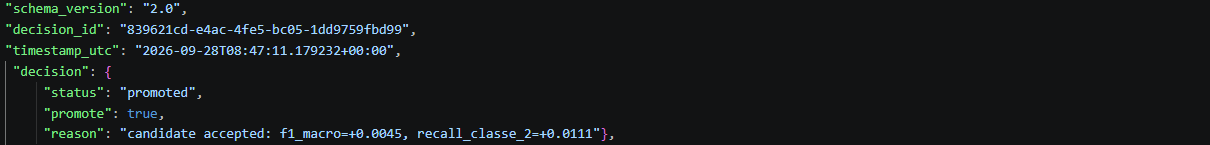

**candidate**       : model_name, model_version, model_type, artifact + artifact_sha256,
                  mlflow_experiment, mlflow_run_id, registry {name, alias, version, model_uri},
                  hyperparameters, training_rows, feedback_request_ids, feedbacks exclus

*extrait de reports/decisions_log.jsonl*
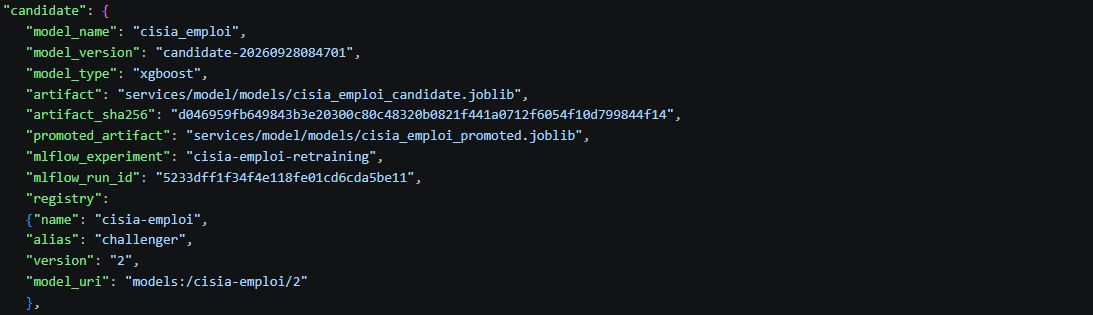

**production**      : model_name, model_version, scenario, config, artifact + artifact_sha256,
                  trained_on_dataset_sha256, mlflow_run_id, registry {name, alias, version}

*extrait de reports/decisions_log.jsonl*
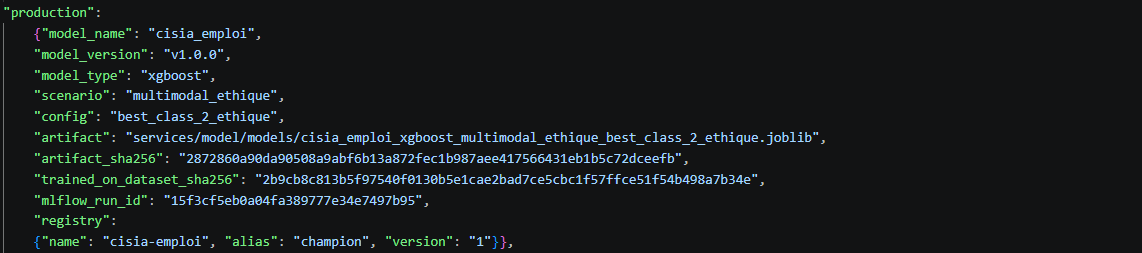

**data**            : reference_set + sha256, training_dataset + sha256, excluded_reference_rows

*extrait de reports/decisions_log.jsonl*
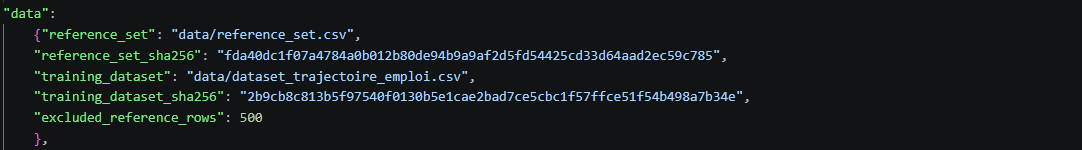

**metrics**         : candidate, production, delta_candidate_minus_production

*extrait de reports/decisions_log.jsonl*
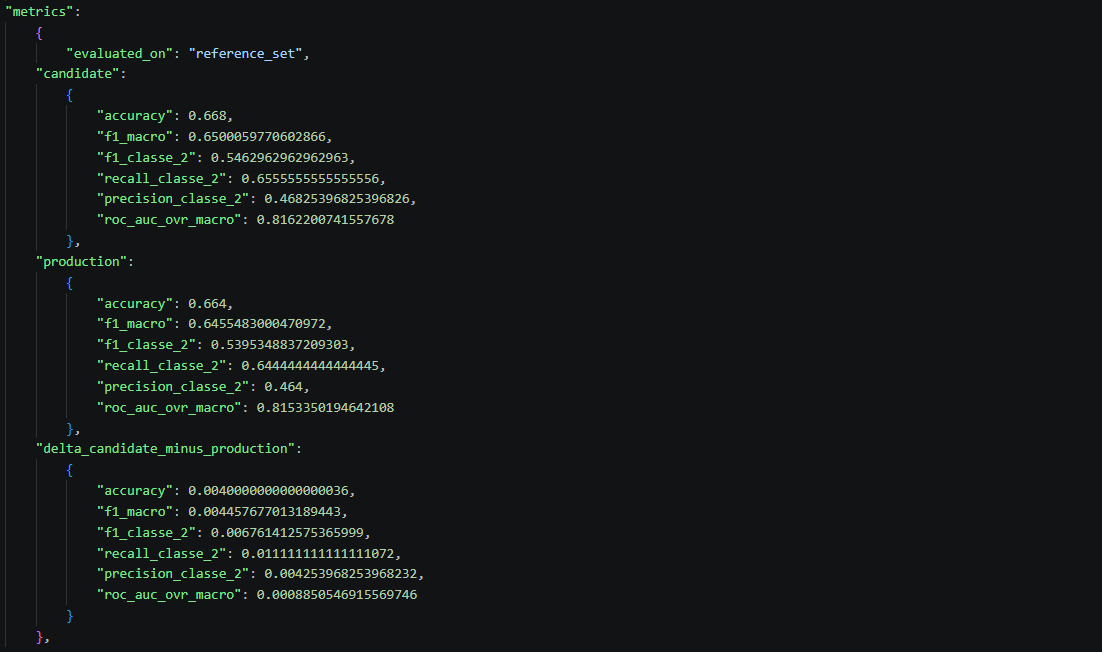
**quality_gate**    : status, passed, failed, rules[]  (rule, type, metric, value, comparison, threshold, status PASS/FAIL)

*extrait de reports/decisions_log.jsonl*
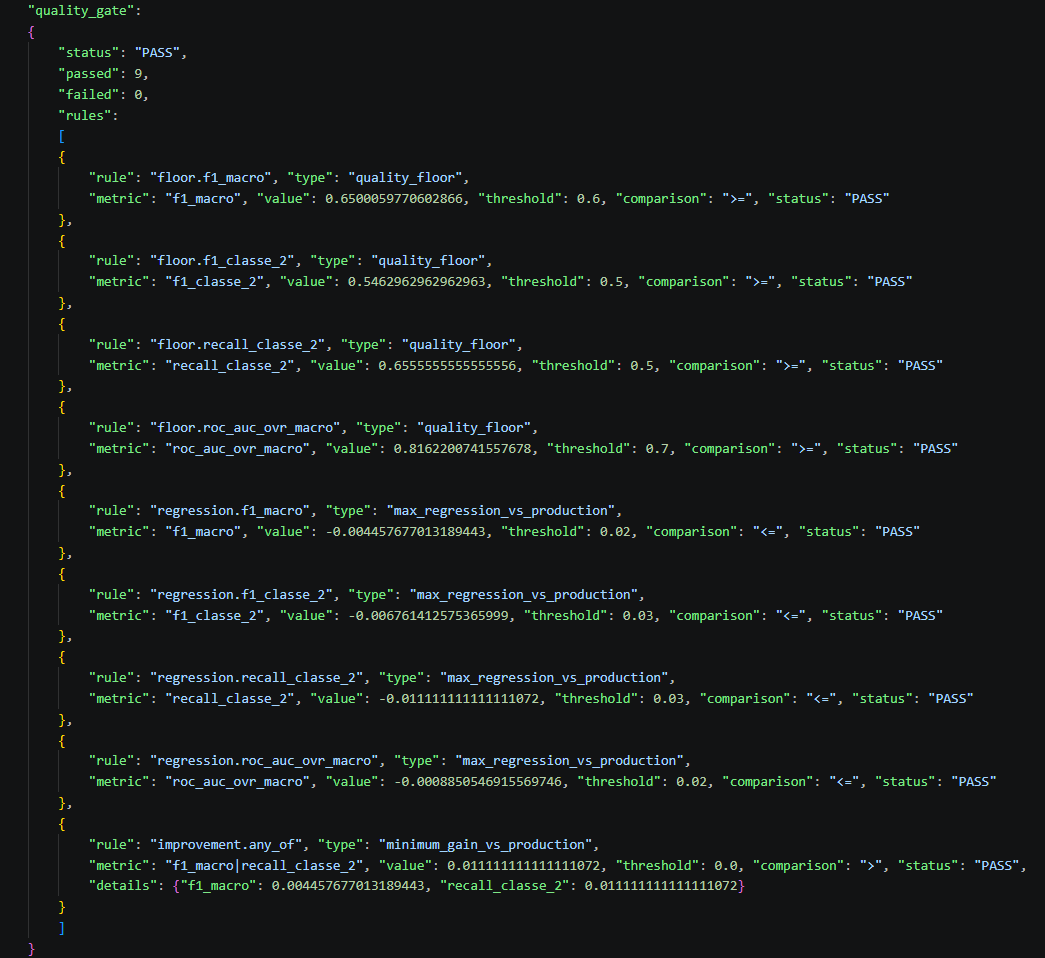

Ce journal permet de démontrer que la mise en production résulte d’une décision :
- mesurable ;
- explicable ;
- reproductible ;
- historisée ;
- auditable.

**Traçabilité MLflow**

L’interface MLflow est accessible à l’adresse suivante :

http://localhost:5000

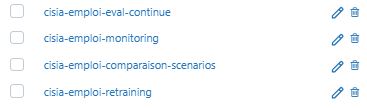


| Élément tracé | Expérience ou registre | Identifiant |
|---|---|---|
| Comparaison du modèle servi avec les autres scénarios | `cisia-emploi-comparaison-scenarios` | `0ea63cc417f84bb7ae4986387598263a` |
| Évaluation métier, calibration, équité et enregistrement du modèle | `cisia-emploi-monitoring` | `15f3cf5eb0a04fa389777e34e7497b95` |
| Modèle enregistré | `cisia-emploi`, version 1, alias `champion` | Lié au run `15f3cf5e…` |
| Quality gate nominal | `cisia-emploi-eval-continue` | `50baa55d…` |
| Quality gate dégradé et bloqué | `cisia-emploi-eval-continue` | `23629563…` |
| Dernier réentraînement et comparaison candidat contre production | `cisia-emploi-retraining` | `3c963de2631c4f3b870db7f2613848d6` |

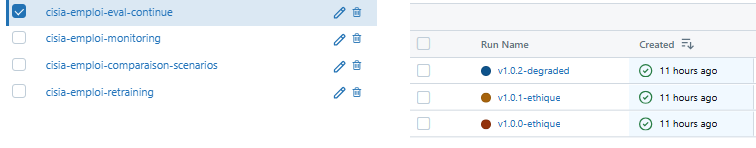
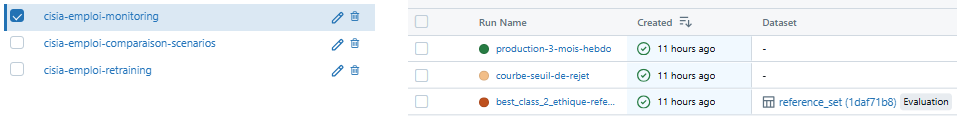
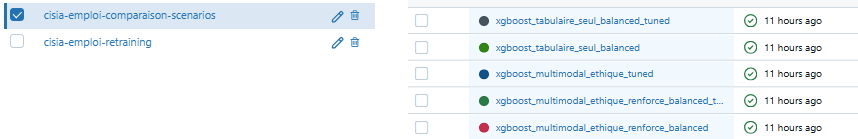
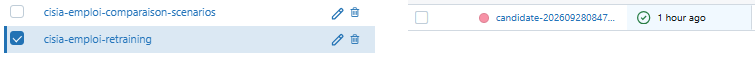

**Chaîne de traçabilité**

La chaîne de traçabilité peut être représentée de la manière suivante :

```text
Dataset identifié par son empreinte SHA-256
                    ↓
Indices du train, de la validation et du holdout conservés
                    ↓
Entraînement du pipeline complet
                    ↓
Paramètres, métriques et artefacts enregistrés dans MLflow
                    ↓
Création du modèle candidat
                    ↓
Comparaison avec le modèle de production
                    ↓
Application du quality gate
                    ↓
Décision enregistrée dans decisions_log.jsonl
                    ↓
Promotion éventuelle du candidat
                    ↓
Sélection de l’artefact par MODEL_ARTIFACT
                    ↓
Chargement du modèle par le service
                    ↓
Exposition de l’identité du modèle dans /info et Prometheus
                    ↓
Enregistrement des prédictions et des feedbacks
```

Cette chaîne permet de relier :
- les données d’entraînement ;
- le code et l’environnement ;
- le modèle entraîné ;
- les métriques obtenues ;
- la décision de promotion ;
- l’artefact déployé ;
- les prédictions produites en exploitation ;
- les feedbacks collectés après le déploiement.


**Observabilité du modèle servi**

L’observabilité permet de vérifier le fonctionnement du service et de suivre le comportement du modèle en exploitation.

L’endpoint `/info` et la métrique Prometheus `cisia_model_info` permettent d’identifier le modèle effectivement chargé.

Les métriques de surveillance peuvent être organisées selon plusieurs catégories.

**Surveillance du modèle**

| Type | Métrique | Seuil d’alerte | Source |
|---|---|---|---|
| Modèle | F1-score hebdomadaire | Inférieur à la baseline de plus de `0,05` | Logs de l’API |
| Données | PSI des variables clés | Supérieur à `0,2` | Batch journalier |
| Système | Latence p95 | Supérieure à `500 ms` | Prometheus |

D’autres métriques peuvent être suivies :

- taux de prédictions par classe ;
- rappel de la classe 2 ;
- nombre d’erreurs `2 → 0` ;
- taux d’erreurs `2 → 0` ;
- taux d’abstention ;
- accuracy sur les prédictions acceptées ;
- distribution de la probabilité maximale ;
- fréquence des corrections par les conseillers ;
- taux d’erreur du service ;
- volume de prédictions ;
- proportion de valeurs manquantes ;
- apparition de catégories inconnues.

**Synthèse**

Le dispositif mis en place couvre les principales dimensions d’une démarche MLOps :

- **reproductibilité**, grâce aux métadonnées, au hash du dataset et aux indices du holdout ;
- **traçabilité**, grâce aux runs MLflow, au registre et au journal des décisions ;
- **maîtrise du risque**, grâce au quality gate ;
- **séparation des responsabilités**, grâce aux statuts `candidate`, `promoted` et stable ;
- **réversibilité**, grâce à la sélection explicite de l’artefact avec `MODEL_ARTIFACT` ;
- **observabilité**, grâce à `/info`, à Prometheus et aux métriques de suivi ;
- **persistance**, grâce aux volumes Docker et au stockage sur l’hôte ;
- **prise en compte de l’éthique**, grâce à l’exclusion des variables sensibles de l’inférence et au suivi séparé des indicateurs d’équité.

Le principe central est qu’un modèle réentraîné n’est jamais automatiquement mis en production.

Il est d’abord :

1. identifié ;
2. évalué ;
3. comparé au modèle actuellement servi ;
4. soumis à un quality gate ;
5. promu uniquement si les critères sont respectés ;
6. sélectionné explicitement pour le déploiement ;
7. contrôlé après son chargement par le service ;
8. surveillé pendant son exploitation.

> **Message clé :** le système ne se limite pas à produire un modèle performant. Il permet également de savoir quel modèle est utilisé, comment il a été entraîné, sur quelles données il a été évalué, pourquoi il a été promu, comment il est surveillé et comment revenir à une version stable en cas de dégradation.

### 8.2 API de service

**Repo associé** : `<lien GitHub>` — dossier `api/`

| Route | Méthode | Rôle | Validation |
|---|---|---|---|
| `/health` | GET | santé du service | — |
| `/predict` | POST | prédiction unitaire | Pydantic |
| `/train` | POST | (option) déclenche un réentraînement | Pydantic + auth |

*[Inclure ici 1 capture Swagger ou un schéma de l'API.]*

```mermaid
flowchart LR
    Client["Navigateur"]
    Frontend["Frontend Nginx :8088"]
    Backend["Backend FastAPI :8001"]
    Model["Model FastAPI :8000"]
    Registry["Référentiel usagers<br/>(optionnel)"]
    DB[("SQLite<br/>prédictions et feedbacks")]
    Prometheus["Prometheus :9090"]
    Grafana["Grafana :3001"]

    Client -->|"GET /"| Frontend
    Client -->|"POST /api/score<br/>GET /api/history<br/>POST /api/feedback"| Frontend
    Frontend -->|"Proxy /api/* vers le backend"| Backend

    Backend -->|"POST /predict"| Model
    Backend -.->|"GET /users/{usager_id}<br/>si configuré"| Registry
    Backend -->|"Enregistre prédictions et feedbacks"| DB
    Backend -.->|"POST /train<br/>proxy contrôlé"| Model

    Model -->|"Tracking lors d'un entraînement autorisé"| MLflow["MLflow :5000"]

    Prometheus -->|"scrape /metrics"| Backend
    Prometheus -->|"scrape /metrics"| Model
    Grafana -->|"requêtes"| Prometheus

    Backend -.->|"GET /health"| Ops["Healthchecks"]
    Model -.->|"GET /health et /info"| Ops
```

Le navigateur appelle le frontend Nginx (port `8088`), qui transmet les requêtes `/api/*` au backend. Le backend appelle ensuite le service model en interne. Les deux services FastAPI exposent une documentation Swagger sur `/docs`. Les routes `/metrics` et `/drift-metrics` n'y apparaissent pas, car elles sont exclues du schéma OpenAPI.

| Route | Méthode | Service | Rôle | Validation / sécurité |
|---|---|---|---|---|
| `/health` | GET | model / backend | Vérifier la santé du service | Model : `503` si l'artefact n'est pas chargé. Backend : liveness seule, sans interroger le model |
| `/info` | GET | model | Retourner le nom, la version, le scénario, les métriques et la provenance du modèle | Lecture des métadonnées JSON de l'artefact chargé |
| `/predict` | POST | model | Effectuer une prédiction unitaire | Schéma Pydantic : diplôme parmi les valeurs autorisées, ancienneté ≥ 0. Réponse : classe 0, 1 ou 2 et trois probabilités. `500` si la prédiction échoue |
| `/score` | POST | backend | Orchestrer la requête du frontend vers le model et enregistrer la prédiction | Pydantic, propagation de `request_id`, `usager_id`, `session_id`. `503` si le model est injoignable, `502` si le model répond en erreur |
| `/history` | GET | backend | Consulter les inférences d'une session ou d'un usager, avec les entrées saisies et le feedback éventuel | Filtres `session_id` / `usager_id`, limite 1-200 |
| `/feedback` | POST | backend | Enregistrer le résultat réel observé par le conseiller | `request_id` connu (`404`), prédiction cohérente et pas d'annotation contradictoire (`409`), `true_label` entre 0 et 2 (`422`), rejeu identique idempotent |
| `/feedback/count` | GET | backend | Compter les feedbacks, au total et non encore consommés, pour déclencher le retraining | Lecture SQLite |
| `/train` | POST | model / backend | Réentraînement contrôlé, pour les tests ou un environnement autorisé | Model : Pydantic, token `X-Train-Token` (`403` si invalide et `TRAIN_API_TOKEN` défini), `ALLOW_DIRECT_TRAIN=false` par défaut (`409`). Backend : proxy qui transmet le token, et renvoie `503` si le model est injoignable ou `502` si le model est en erreur |
| `/metrics` | GET | model / backend | Exposer les métriques Prometheus | Format Prometheus, hors Swagger |
| `/drift-metrics` | GET | backend | Publier le dernier rapport de drift batch | Format Prometheus, fichier défini par `DRIFT_METRICS_FILE` (par défaut `/app/reports/drift.prom`), hors Swagger |

Le backend appelle le référentiel usagers via `GET /users/{usager_id}`, uniquement si un `usager_id` est fourni et que `USER_REGISTRY_URL` est configuré. Un référentiel indisponible **ou un usager inconnu** entraînent tous deux une réponse `503`.

Les erreurs principales sont :
| Code | Signification |
|--------|-------------|
| **200 / 201** | Succès de l'opération (`201 Created` pour un feedback enregistré). |
| **403 Forbidden** | Token de réentraînement invalide lors d'un appel direct au service modèle. |
| **404 Not Found** | `request_id` inconnu lors de l'enregistrement d'un feedback ou route inexistante. |
| **409 Conflict** | Prédiction incohérente avec le `request_id`, feedback contradictoire ou réentraînement direct désactivé. |
| **422 Unprocessable Entity** | Données invalides : diplôme hors référentiel, ancienneté négative, âge hors bornes, champ obligatoire absent, JSON invalide, `true_label` hors de l'intervalle `[0 ; 2]`, `limit` hors de `[1 ; 200]` ou `usager_id` vide. |
| **500 Internal Server Error** | Échec de la prédiction dans le service modèle. |
| **502 Bad Gateway** | Erreur du service modèle relayée par le backend sur les routes `/score` ou `/train`. |
| **503 Service Unavailable** | Service modèle injoignable ou modèle non chargé, référentiel usagers indisponible ou usager inconnu dans le référentiel. |
| **Code de sortie 1** | Échec du quality gate lors de l'exécution de `evaluate_model.py --degrade`. |

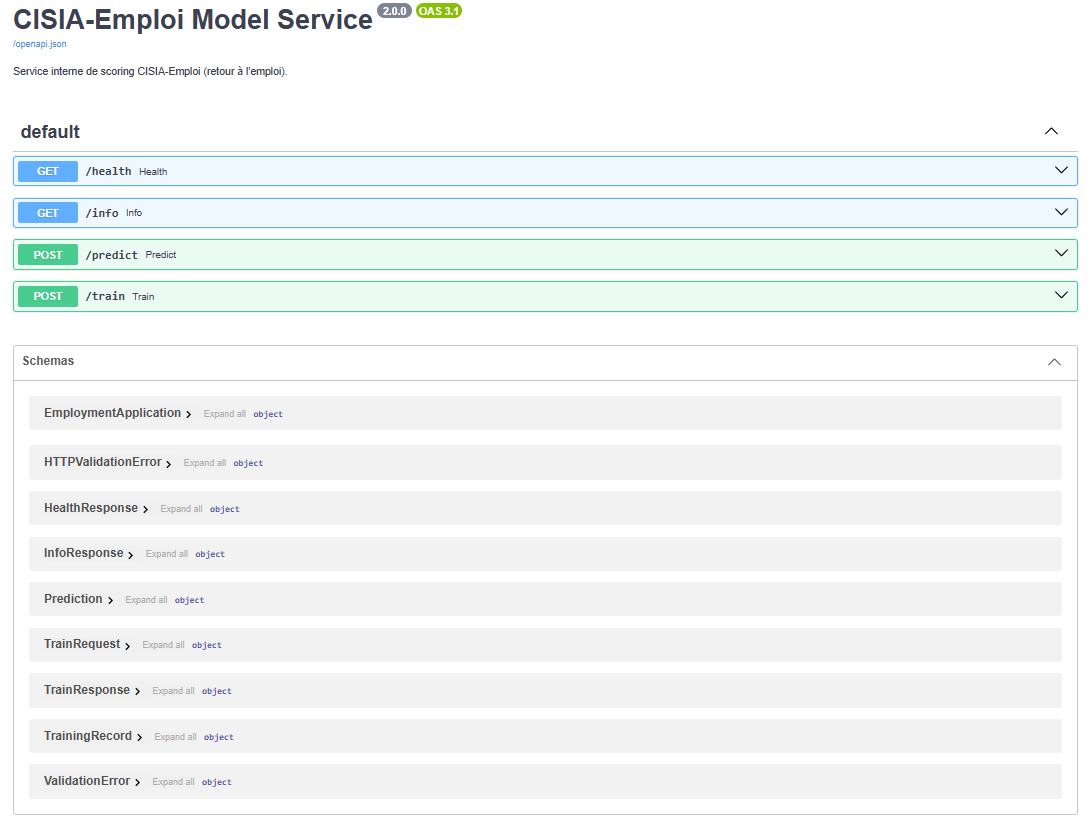

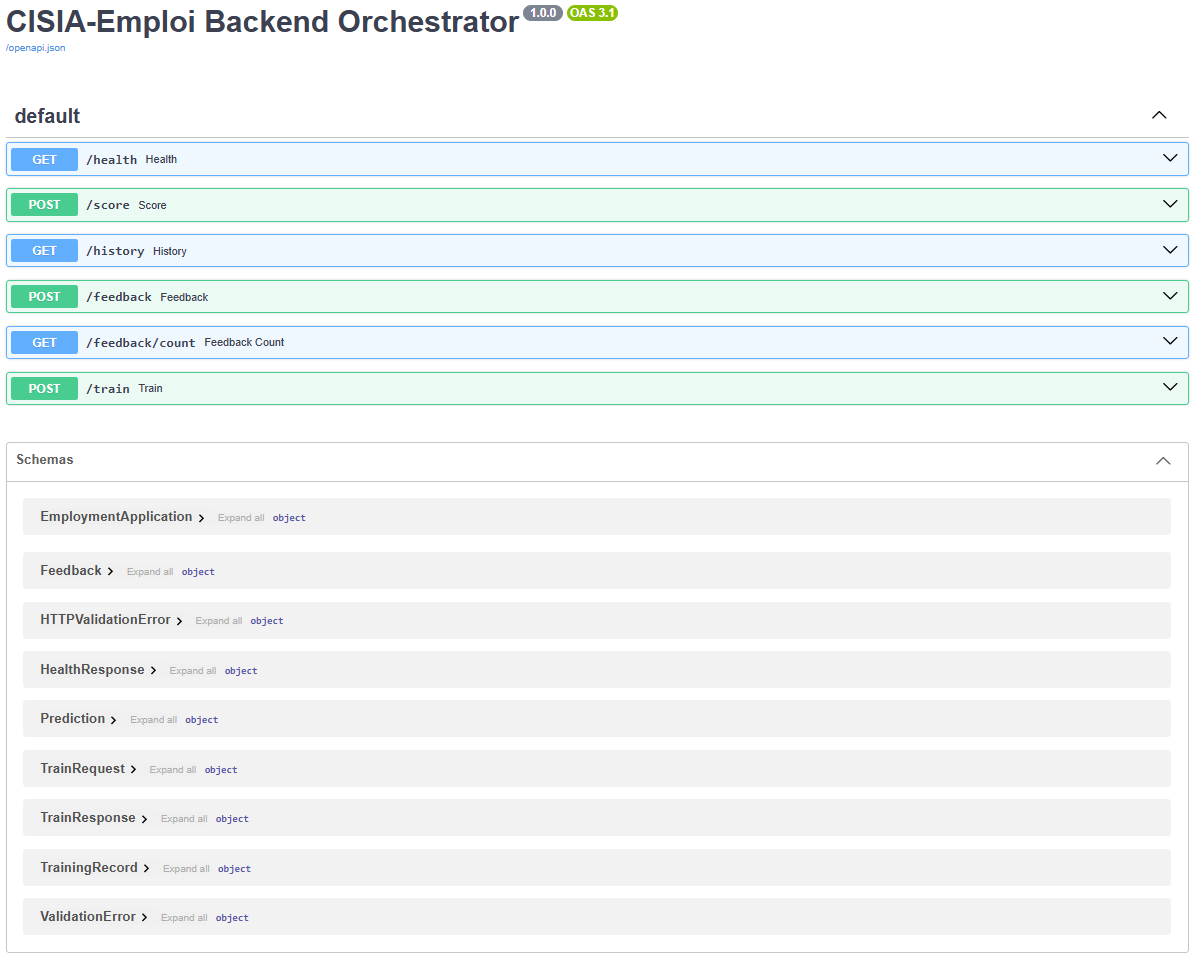

### 8.3 Interface utilisateur

*[Streamlit / Gradio / autre. Capture dans `docs/`.]*

Cette page est un formulaire intitulé « Orientation vers le retour à l'emploi », destiné à évaluer le délai probable de retour à l'emploi d'un usager.
L'interface HTML permet au conseiller de renseigner l'identifiant usager, les variables de situation ainsi que la synthèse d'entretien, puis d'appuyer sur le bouton « Évaluer le retour à l'emploi ». 
Un message affiche alors la classe prédite, les probabilités, la version du modèle et le REQ-ID

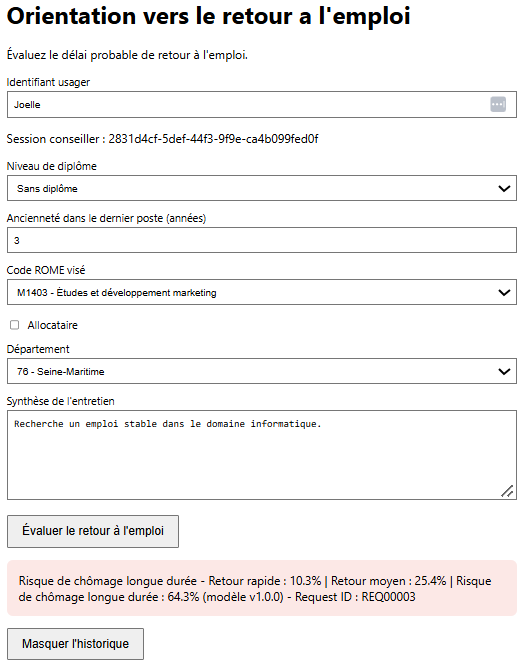

Après chaque scoring, l'interface recharge l'historique de la session avec `GET /api/history?session_id=...`.

Sur la même page, le conseiller peut consulter l'historique horodaté de sa session ou de toutes les sessions.

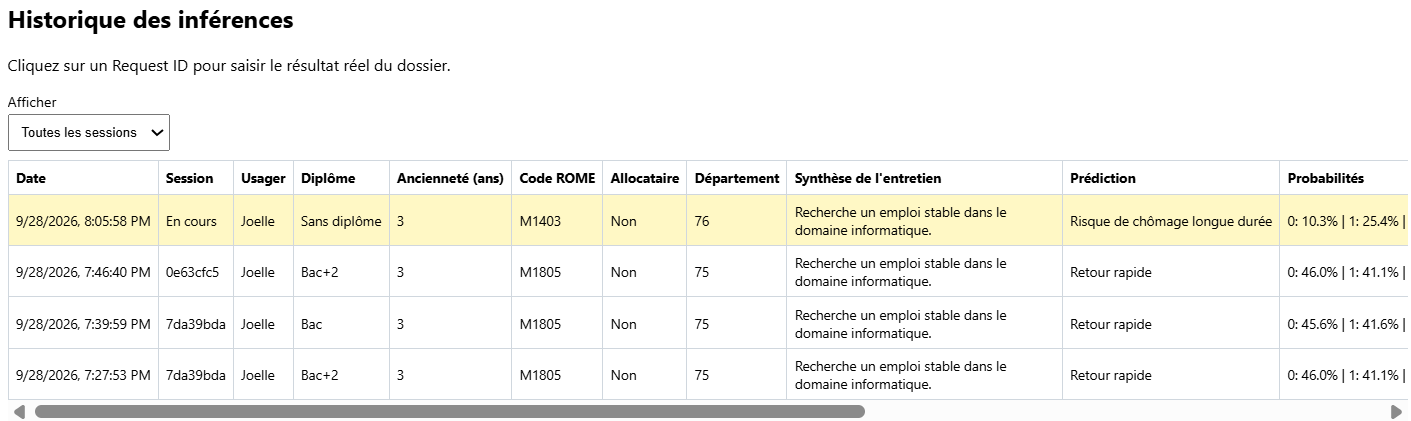

Il pourra aussi, en cliquant sur le REQ-ID dans l'historique, enregistrer le résultat réel et un commentaire via /api/feedback. Une fenêtre pop-up apparaîtra alors, permettant de renseigner le feedback du conseiller.
    
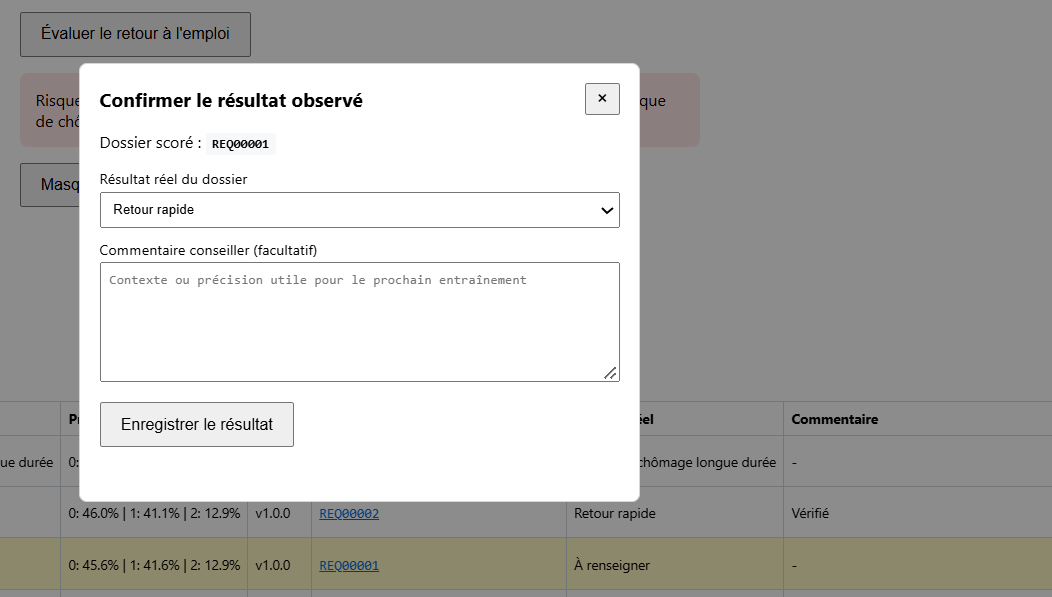

### 8.4 Schéma d'architecture

*[1 schéma simple : sources données → préprocessing → modèle → API → UI → monitoring.  
Tu peux utiliser un bloc Mermaid (rendu natif sur GitHub et Jupyter récents) :]*

```mermaid
graph LR
  D[(Données)] --> P[Préprocessing] --> M[Modèle .joblib]
  M --> A[FastAPI]
  A --> U[UI Streamlit]
  A --> L[(Logs)]
  L --> Mo[Monitoring]
```




```mermaid
flowchart TB
    conseiller["Conseiller"] --> navigateur["Navigateur"]

    subgraph production["Application en production - Docker Compose"]
        frontend["Frontend statique<br/>Nginx :80 dans le conteneur<br/>localhost:8088"]
        backend["Backend FastAPI<br/>:8001<br/>/score · /feedback · /history"]
        ledger[("SQLite persistant<br/>prédictions et retours")]
        model["Service modèle FastAPI<br/>:8000<br/>/predict · /metrics"]
        artifact[("Pipeline entraîné<br/>fichier .joblib + métadonnées")]

        navigateur --> frontend
        frontend -->|"/api/*, reverse proxy"| backend
        backend -->|"/predict, appel interne"| model
        model -->|"classe, probabilités, version"| backend
        backend -->|"résultat de scoring"| frontend
        backend -->|"journalise les prédictions<br/>et les retours validés"| ledger
        ledger -->|"/history"| backend
        artifact -->|"chargé au démarrage"| model

        userRegistry["Référentiel usagers<br/>optionnel"]
        backend -.->|"vérification de l'usager<br/>si USER_REGISTRY_URL configurée"| userRegistry
    end

    subgraph retraining["Réentraînement - lancement optionnel"]
        trigger["Lancement du retrainer<br/>profil Compose ou script"]
        trainingData[("Dataset historique<br/>+ retours étiquetés")]
        reference[("Jeu de référence figé")]
        candidate["Entraînement du candidat<br/>prétraitement + XGBoost"]
        gate{"Évaluation comparative<br/>et seuils de promotion"}
        candidateArtifact[("Artefact candidat")]
        promotedArtifact[("Artefact promu")]
        decisionLog["Journal de décision"]

        trigger -->|"lit les retours non consommés"| ledger
        trainingData --> candidate
        candidate --> gate
        reference -->|"évalue candidat et production"| gate
        gate -->|"conserve le candidat"| candidateArtifact
        gate -->|"si les seuils passent"| promotedArtifact
        gate --> decisionLog
    end

    subgraph tracking["Suivi des expériences"]
        mlflow["MLflow :5000<br/>tracking et registre de modèles"]
        mlflowStore[("Volumes persistants<br/>backend SQLite et artefacts MLflow")]
        mlflow --> mlflowStore
    end

    candidate -->|"paramètres, métriques,<br/>candidat enregistré"| mlflow
    trigger -->|"journalise le run"| mlflow

    deploy["Déploiement explicite<br/>configuration MODEL_ARTIFACT<br/>puis redémarrage du service modèle"]
    promotedArtifact --> deploy
    deploy -.->|"charge le modèle promu"| model

    subgraph monitoring["Monitoring"]
        prometheus["Prometheus :9090"]
        grafana["Grafana :3001"]
        driftJob["Analyse batch du drift"]
        driftFile[("reports/drift.prom")]

        prometheus -->|"requêtes de visualisation"| grafana
        driftJob -->|"génère le rapport"| driftFile
    end

    prometheus -->|"scrape /metrics"| model
    prometheus -->|"scrape /metrics"| backend
    driftFile -->|"servi par /drift-metrics"| backend
    prometheus -->|"scrape /drift-metrics"| backend

### 8.5 Conteneurisation & CI/CD

*[Dockerfile, docker-compose.yml, workflow GitHub Actions (build → test → push). Captures d'écran d'un run CI vert. Liens vers les fichiers du repo.]*
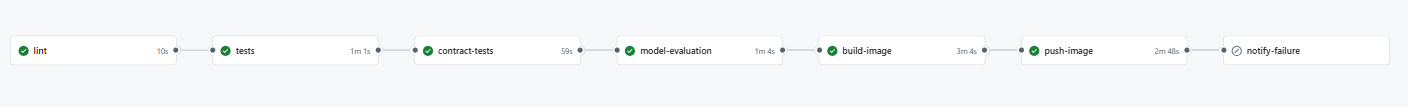



**Déclencheurs (`on:`)**

- **`workflow_dispatch`** : lancement manuel.
- **`push`** : vers `main` ou vers un tag `v*`.
- **`pull_request`** : vers `main`.

**Chaîne des jobs**

**1. `lint`**
Installe Ruff et vérifie `services`, `scripts`, `tests`.

**2. `test` *(après `lint`)***
Installe les dépendances model + backend, puis lance :
- les tests API du modèle (santé, prédiction valide/invalide, `/metrics`) ;
- les tests API du backend (`/score`, validation du nombre minimal d'enregistrements).

**3. `train-validation` *(après `lint`, en parallèle de `test`)***
Installe les dépendances d'entraînement et d'évaluation, puis exécute dans l'ordre :
1. tests d'entraînement (seuil minimal, token invalide, run MLflow) ;
2. test de contrat du modèle ;
3. tests d'évaluation ;
4. **quality gate** `scripts/evaluate_model.py --release-tag`.

Le résultat est capturé dans `evaluation-result.json` (`set -o pipefail` pour ne pas masquer un échec derrière `tee`) et publié dans le résumé du run (`GITHUB_STEP_SUMMARY`), visible dans tous les cas (`if: always()`).

**4. `build-and-push` *(après `test` ET `train-validation`)***
Job matriciel (`fail-fast: false`) qui build en parallèle les trois services : `model`, `backend`, `frontend`. Pour chacun :
- calcule le nom d'image en minuscule (`ghcr.io/<repo>/<service>`) ;
- se connecte à GHCR uniquement sur push vers `main` ou tag `v*` ;
- génère les tags via `docker/metadata-action` (SHA, branche, tag, `latest` conditionnel) ;
- build et push (le push n'a lieu que sur push vers `main` ou tag `v*` — sur une PR, l'image est construite mais pas publiée).

### 5. `deploy` *(après `build-and-push`, uniquement sur push vers `main`)*
Se connecte en SSH via `appleboy/ssh-action`, se logue à GHCR sur le serveur cible, tire les nouvelles images (`docker compose pull`) et redémarre les conteneurs `model`, `backend`, `frontend` (`up -d --no-build --force-recreate`), puis affiche leur état. Ne s'exécute que si `DEPLOY_HOST` est configuré.

### 6. `release` *(après `build-and-push`, uniquement sur push d'un tag `v*`)*
Checkout avec historique complet (`fetch-depth: 0`), puis `gh release create` avec vérification du tag et génération automatique des notes de version.

### 7. `notify-failure` *(après tous les jobs précédents)*
S'exécute toujours (`always()`) mais seulement si l'un des six jobs précédents (`lint`, `test`, `train-validation`, `build-and-push`, `deploy`, `release`) a échoué. Valide d'abord le format du webhook Discord, puis envoie une alerte (embed rouge) avec dépôt, branche et lien vers le run.

## Logique d'exécution selon le contexte

| Événement | lint / test / train-validation | build-and-push | push image | deploy | release |
|---|---|---|---|---|---|
| PR vers `main` | ✅ | ✅ (build) | ❌ | ❌ | ❌ |
| push vers `main` | ✅ | ✅ | ✅ | ✅ | ❌ (skipped) |
| push tag `v*` | ✅ | ✅ | ✅ | ❌ (skipped, ref ≠ main) | ✅ |

## Points forts

- Parallélisation efficace (`test` / `train-validation`, puis matrice de build).
- Quality gate ML explicite et visible dans le résumé du run.
- Séparation nette entre build (toute PR) et push/déploiement (seulement `main`/tags).
- Notification d'échec centralisée et validée avant envoi.

## Limites à considérer

- Pas de cache pip ni de cache de layers Docker (`cache-from`/`cache-to`), donc chaque run reconstruit tout de zéro.
- Aucun scan de vulnérabilités sur les images avant push en registre.
- `deploy` ne fait pas de health check applicatif après redémarrage, ni de rollback automatique en cas d'échec.
- Pas d'`environment:` GitHub protégé sur `deploy`, qui touche pourtant la prod en direct.
- Sur un tag `v*`, aucun déploiement n'est déclenché (seul `main` déploie) — à confirmer que c'est bien l'intention (tag = release notée mais pas forcément déployée automatiquement).

### 8.6 📝 Synthèse industrialisation

*[Pile retenue, choix d'architecture, points encore ouverts.]*

### Pile technique retenue

| Composant | Choix | Rôle |
|---|---|---|
| Frontend | Nginx (`localhost:8088`) | Interface conseiller, saisie et consultation |
| Backend | FastAPI (`localhost:8001`) | Orchestration, routes `/score`, `/feedback`, `/feedback/count` et proxy `/train` |
| API modèle | FastAPI (`localhost:8000`) | Routes `/predict`, `/train`, `/health`, `/info` et `/metrics` |
| Validation | Pydantic | Validation du schéma et des contraintes d’entrée |
| Preprocessing | Fonction `create_features()` partagée | Même préparation des données pour l’inférence et l’entraînement |
| Modèle | XGBoost multiclasses | Prédiction des classes `0`, `1` et `2` |
| Tracking | MLflow | Suivi des runs d’entraînement et des métriques |
| Monitoring | Prometheus + Grafana | Collecte et visualisation des métriques modèle et backend |
| CI/CD | GitHub Actions | Ruff, tests unitaires/API, contract test, évaluation qualité, build et publication |
| Registre | GHCR | Stockage des images Docker model, backend et frontend |
| Alerting | Webhook Discord | Notification en cas d’échec de la chaîne CI/CD |

### Choix d’architecture

- **Séparation Backend / API modèle** : le backend ne manipule jamais directement XGBoost ni MLflow. Il communique avec le service modèle via HTTP, ce qui permet de faire évoluer le modèle sans modifier le contrat frontend/backend.

- **Preprocessing partagé** : Pydantic valide les données à l’entrée de l’API, puis `create_features()` applique les transformations utilisées par `/predict` et `/train`. Cette organisation limite le risque de divergence entre entraînement et inférence.

- **Traçabilité par `request_id`** : chaque prédiction est reliée à son feedback conseiller dans SQLite. Cela permet de conserver l’historique, d’éviter les annotations contradictoires et de préparer les données de réentraînement.

- **Gate qualité avant publication** : la CI exécute les contrôles de style, les tests, le contract test et l’évaluation sur le jeu de référence avant le build et la publication des images Docker. Une régression bloque la publication.

- **Build et publication séparés** : les images sont construites après validation. Elles sont poussées vers GHCR uniquement sur `main` ou lors d’un tag `v*`, avec `GITHUB_TOKEN` et la permission `packages: write`.

- **Observabilité ciblée** : Prometheus scrape les endpoints `/metrics` du backend et du service modèle. Les endpoints `/health` servent aux healthchecks Docker et aux contrôles de disponibilité. Le frontend est vérifié par son healthcheck Nginx.

- **Monitoring métier** : les métriques couvrent notamment les requêtes HTTP, la latence, les erreurs upstream, la classe prédite et la distribution des probabilités.


## 9. Suivi en production & amélioration continue

**Compétences** : C8 (mesurer performance), C9 (amélioration continue)

🎯 Anticiper la dérive et la maintenance du modèle après mise en prod.

💡 Drift = data drift (entrées qui changent) vs concept drift (la cible change de comportement).  
⚠️ Pas de monitoring = pas de prod. Même un dashboard simple Streamlit suffit pour démarrer.

### 9.1 Métriques à surveiller

| Type | Métrique | Seuil d'alerte | Source |
|---|---|---|---|
| Modèle | F1 hebdo | < baseline - 0.05 | logs API |
| Données | PSI variables clés | > 0.2 | batch journalier |
| Système | latence p95 | > 500 ms | Prometheus |



| Type | Métrique | Seuil d'alerte | Source | Action associée |
|---|---|---|---|---|
| Modèle | F1 macro hebdomadaire | Baisse supérieure à 0,05 par rapport à la baseline | Évaluation sur le jeu de référence + MLflow | Bloquer une promotion et analyser les erreurs par classe |
| Modèle | Recall de la classe 2 | Sous le seuil métier défini, ou baisse supérieure à 0,03 par rapport à la production | Évaluation sur `reference_set.csv` | Escalade métier et rejet du candidat si la régression est confirmée |
| Modèle | Répartition des classes prédites | Écart durable par rapport à la distribution de référence | Prometheus/Grafana : `pyrenex_predictions_total` | Rechercher un changement de population ou un problème de preprocessing |
| Données | PSI des variables clés | PSI supérieur à 0,20 | Batch quotidien ou hebdomadaire | Déclencher une analyse de data drift |
| Données | Taux de valeurs manquantes et modalités inconnues | Hausse significative par rapport à la baseline | Logs API et contrôles de preprocessing | Vérifier la source de données et la compatibilité du schéma |
| Confiance | Distribution des probabilités prédites | Déplacement durable vers 0, 0,5 ou 1 | Prometheus/Grafana : histogramme des probabilités | Vérifier la calibration et les changements de population |
| Système | Latence p95 | Supérieure à 500 ms sur cinq minutes | Prometheus : histogrammes HTTP | Examiner CPU, mémoire, réseau et version déployée |
| Système | Taux d'erreur HTTP | Hausse des réponses 4xx/5xx ou erreur upstream modèle | Prometheus et logs structurés | Vérifier les dépendances et appliquer le runbook |
| Disponibilité | État des services | `up = 0` ou healthcheck KO pendant plus de deux minutes | Prometheus et Docker Compose | Redémarrer ou revenir à la dernière version stable |

Les alertes doivent être interprétées sur une fenêtre temporelle suffisante afin
d'éviter de réagir à un point aberrant isolé. Les métriques sont visualisées
dans Grafana selon les trois axes client : **vie**, **vitesse** et
**comportement**.

### 9.2 Boucle de rétroaction

*[Comment les retours utilisateurs / annotations correctives reviennent dans les données d'entraînement ?]*

La boucle de rétroaction transforme les résultats observés par les conseillers
en données d'apprentissage traçables :

1. Le backend attribue un `request_id` à chaque scoring et enregistre dans
   SQLite les variables d'entrée, la prédiction, les probabilités et la version
   du modèle.
2. Après observation du résultat réel, le conseiller utilise le formulaire
   frontend pour confirmer la classe `0`, `1` ou `2` et ajouter un commentaire
   facultatif.
3. Le frontend envoie `request_id`, `prediction` et `true_label` à
   `POST /feedback`.
4. Le backend refuse un identifiant inconnu (`404`), un conflit de prédiction
   ou d'annotation (`409`) et un label hors du domaine CISIA (`422`). Un rejeu
   identique est idempotent.
5. Le feedback validé est stocké dans la table `feedbacks` avec le flag
   `used_for_training = 0`.
6. Le retrainer joint le feedback à l'observation originale de la table
   `predictions`, puis compte uniquement les annotations non consommées.
7. Lorsque le seuil est atteint, les observations annotées sont ajoutées au
   dataset historique pour construire un candidat. Le jeu de référence reste
   séparé et n'est jamais utilisé pour l'entraînement.
8. Après traitement réussi, les feedbacks utilisés sont marqués comme
   consommés afin d'éviter un retrain répétitif sur les mêmes données.

Cette conception assure la traçabilité entre une décision produite, sa vérité
métier et la version du modèle qui l'a produite. Les données de feedback sont
conservées dans le volume Docker `feedback_data`; elles ne doivent pas être
remplacées par des labels synthétiques.

```mermaid
flowchart TD

    A[Demande de scoring] --> B[Backend]
    B --> C[Génération du request_id]
    C --> D[Prédiction du modèle]
    D --> E[(Table predictions)]

    E --> E1[Variables d'entrée]
    E --> E2[Classe prédite]
    E --> E3[Probabilités]
    E --> E4[Version du modèle]

    D --> F[Résultat affiché au conseiller]

    F --> G[Observation du résultat réel]
    G --> H[Saisie du feedback]

    H --> H1[Classe réelle 0 / 1 / 2]
    H --> H2[Commentaire optionnel]

    H --> I[POST /feedback]

    I --> J{Contrôles backend}

    J -->|request_id inconnu| K[404 Not Found]
    J -->|Conflit annotation ou prédiction| L[409 Conflict]
    J -->|Label invalide| M[422 Unprocessable Entity]

    J -->|Feedback valide| N[(Table feedbacks)]

    N --> N1[used_for_training = 0]

    N --> O[Service de retraining]

    E --> O

    O --> P[Jointure predictions + feedbacks]

    P --> Q[Filtrage des feedbacks non consommés]

    Q --> R{Seuil minimum atteint ?}

    R -->|Non| S[Attente de nouveaux feedbacks]

    R -->|Oui| T[Construction du dataset candidat]

    T --> U[Ajout des données annotées]

    U --> V[Entraînement du modèle candidat]

    V --> W[Validation et comparaison à la baseline]

    W --> X{Promotion ?}

    X -->|Non| Y[Run MLflow conservé]
    
    X -->|Oui| Z[Nouvelle version du modèle]

    Z --> AA[Mise à jour du manifeste]
    AA --> AB[Chargement du nouveau modèle]

    Z --> AC[Marquage des feedbacks utilisés]
    AC --> AD[used_for_training = 1]

    subgraph Référentiel de validation
        REF[Jeu holdout indépendant]
    end

    REF -. Jamais utilisé pour l'entraînement .-> V

    subgraph Stockage persistant
        E
        N
    end

    subgraph Volume Docker
        VOL[feedback_data]
    end

    N --- VOL
```

### 9.3 Plan de réentraînement

*[Trigger (calendaire ? performance ? volume nouvelles données ?), automatisation, validation avant mise en prod.]*

Le plan combine un déclencheur de volume, un déclencheur calendaire et une
validation obligatoire avant déploiement.

**Déclencheurs**

- **Volume** : le retrain est éligible lorsque le nombre de feedbacks non
  consommés atteint 200. Sous ce seuil, le script s'arrête avec un statut
  normal `Skip retrain`.
- **Calendrier** : le workflow GitHub Actions `retrain.yml` peut être lancé
  toutes les six heures et manuellement. En local, le service Compose
  `retrainer` peut être lancé par script ou par cron.
- **Performance** : une dégradation détectée par les métriques ne déploie pas
  directement un modèle. Elle déclenche une analyse et peut conduire à un
  retrain anticipé après validation de la qualité des données.

**Automatisation**

```text
feedbacks non consommés
    -> seuil atteint
    -> création du dataset d'apprentissage
    -> entraînement du candidat CISIA
    -> contrôle du contrat multiclasses
    -> évaluation candidat/production
    -> décision de promotion
    -> artefact promu
    -> déploiement contrôlé
```

Le script `scripts/retrain.py` produit d'abord un candidat séparé. Il vérifie
que la pipeline multimodale fournit trois probabilités finies, puis compare le
candidat et la production sur le même `data/reference_set.csv`. La décision
est prise par `scripts/promotion.py` selon :

- des planchers absolus de qualité ;
- une tolérance de régression ;
- une attention particulière au recall de la classe 2, qui représente le
  risque de chômage longue durée ;
- un gain minimal justifiant le remplacement du modèle.

**Validation avant mise en production**

Une promotion est refusée si le candidat passe sous un seuil absolu, régresse
au-delà de la tolérance ou n'apporte pas d'amélioration suffisante. Toute
 décision, acceptée ou refusée, est inscrite dans `decisions_log.jsonl`.

En cas d'acceptation :

1. `cisia_emploi_candidate.joblib` et ses métadonnées sont conservés ;
2. un artefact `cisia_emploi_promoted.joblib` est produit ;
3. le modèle est déployé explicitement avec `MODEL_ARTIFACT` ;
4. les healthchecks, `/info`, `/score`, Prometheus et Grafana sont vérifiés ;
5. un rollback vers l'artefact stable reste possible.

Le workflow de retrain et le workflow CI/CD ont des responsabilités distinctes :
`retrain.yml` entraîne et décide, tandis que `ci.yml` valide et publie les
images. Dans la configuration actuelle, le runner GitHub Actions ne voit pas
le volume SQLite local ; un vrai retrain distant nécessite donc une base de
feedback persistante accessible au runner.


### 9.4 Robustesse en exploitation

🎯 Surveiller les **conditions de défaillance** une fois en prod, en complément des stratégies de fallback définies en §7.2 (côté conception).

💡 La conception du fallback (où placer le seuil, qui escalader) vit en §7.2. Ici on instrumente la **mesure** et le **déclenchement** :

| Axe | Métrique opérationnelle | Action automatique |
|---|---|---|
| **OOD (Out-Of-Distribution)** | Distance Mahalanobis ou score d'isolation sur les entrées | Logger les inputs hors-distribution, déclencher abstention ou escalade humaine (cf §7.2) |
| **Drift du seuil de rejet** | Taux d'abstention / part de prédictions sous seuil de confiance | Réviser le rejection threshold si dérive > 20 % sur 4 semaines glissantes |
| **Calibration** | Brier score, courbe de calibration mensuelle | Recalibrer (Platt, isotonic) sans réentraîner le modèle complet si seule la calibration dérive |

⚠️ La chaîne conception → exploitation doit rester explicite. §7.2 définit le filet de sécurité, §9.4 le surveille. Casser cette chaîne (fallback conçu mais jamais mesuré) = attendu C8 N3 non atteint.

### 9.5 📝 Synthèse amélioration continue

*[Cadence de surveillance, déclencheurs de réentraînement, plan de remédiation en cas de dérive.]*

Le dispositif retenu associe une observation technique continue, une annotation
humaine rattachée par `request_id`, un retrain conditionné par le volume et une
promotion soumise à une quality gate. Cette séparation permet d'améliorer le
modèle sans déployer automatiquement une régression et garantit une traçabilité
suffisante pour l'analyse métier et l'exploitation.

Variables numériques (5): ['age', 'anciennete_poste_ans', 'est_allocataire', 'nationalite_hors_ue', 'classe_retour_emploi']
Variables catégorielles (5): ['usager_id', 'niveau_diplome', 'code_rome_vise', 'code_insee_commune', 'synthese_entretien']


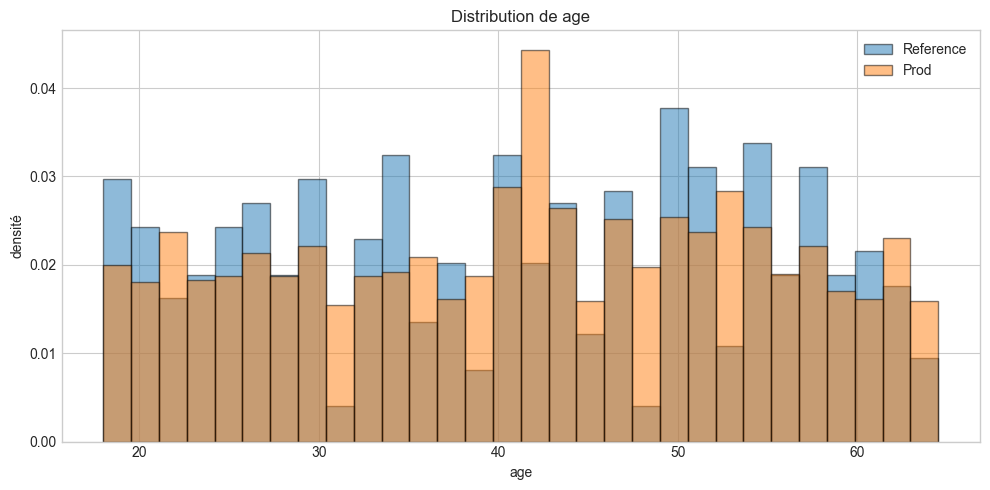

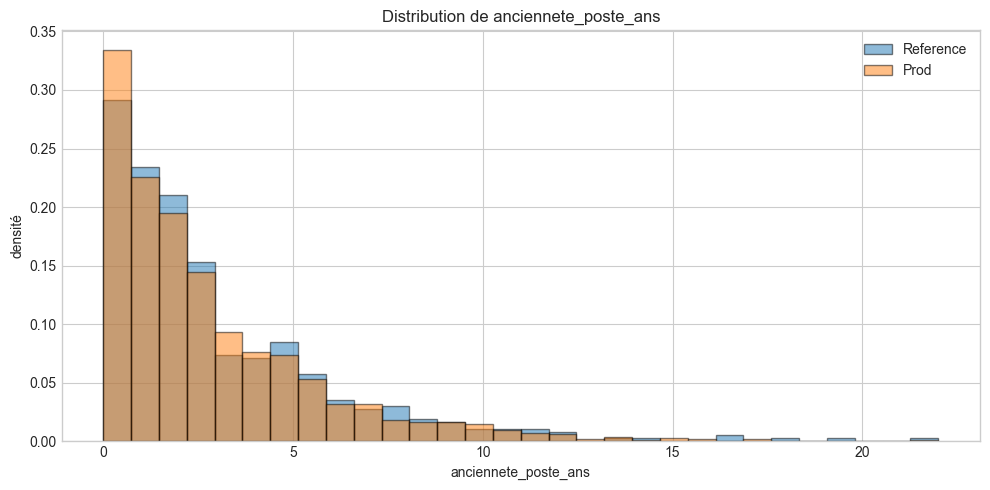

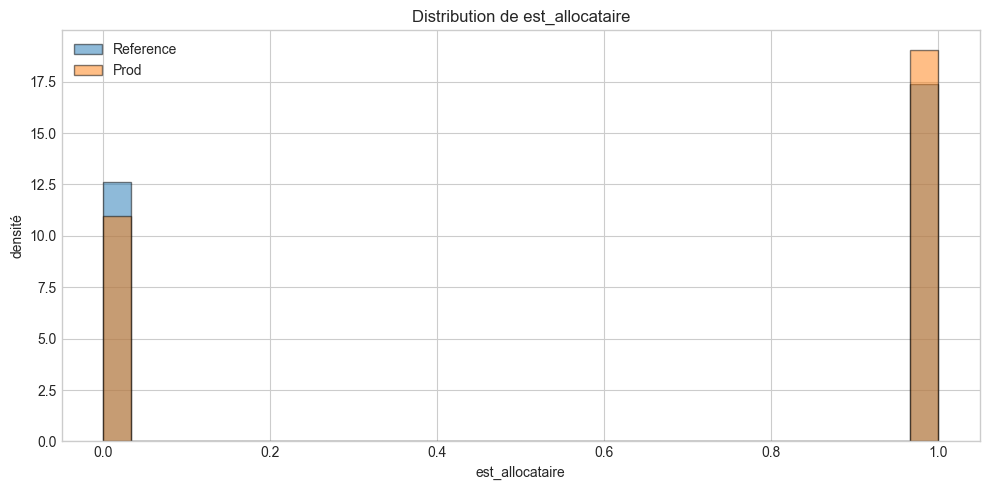

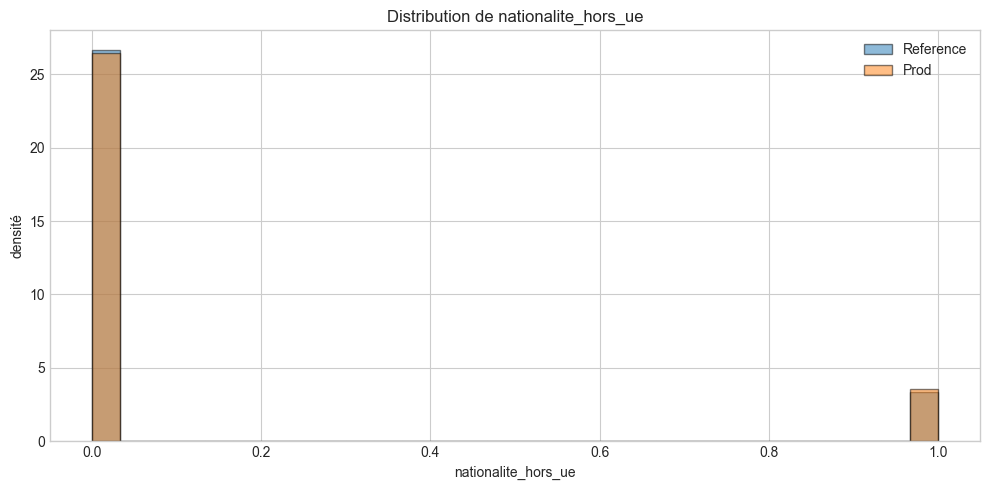

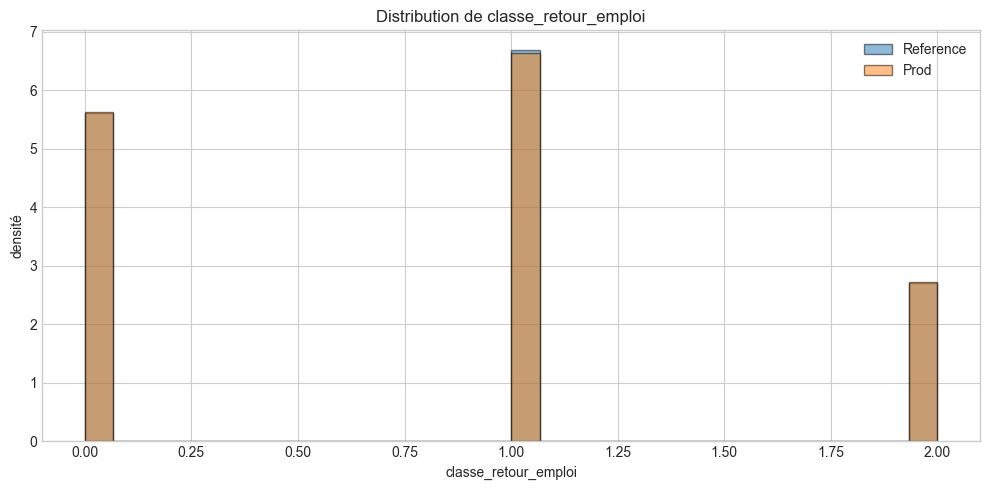

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

root = Path.cwd().resolve().parent
ref = pd.read_csv(root / "data" / "reference_set.csv")
prod = pd.read_csv(root / "data" / "prod_3months.csv")

# --- 0) Préparation ---
exclude_cols = {"loan_status", "timestamp"}
feature_cols = [c for c in ref.columns if c not in exclude_cols and c in prod.columns]

numeric_cols = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(ref[c]) and pd.api.types.is_numeric_dtype(prod[c])
]
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

print(f"Variables numériques ({len(numeric_cols)}): {numeric_cols}")
print(f"Variables catégorielles ({len(categorical_cols)}): {categorical_cols}")

# --- 1) Comparaison visuelle des distributions numériques ---
# Représentation en superposition transparente.
priority_cols = ["int_rate", "revol_util", "annual_inc", "delinq_2yrs", "dti", "installment"]

for col in [c for c in priority_cols if c in numeric_cols]:
    ref_vals = ref[col].dropna()
    prod_vals = prod[col].dropna()
    min_val = min(ref_vals.min(), prod_vals.min())
    max_val = max(ref_vals.max(), prod_vals.max())
    bins = np.linspace(min_val, max_val, 31)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(ref_vals, bins=bins, density=True, alpha=0.5, color="tab:blue", edgecolor="black", label="Reference")
    ax.hist(prod_vals, bins=bins, density=True, alpha=0.5, color="tab:orange", edgecolor="black", label="Prod")
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("densité")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Les autres variables numériques peuvent aussi être vérifiées rapidement.
for col in [c for c in numeric_cols if c not in priority_cols]:
    ref_vals = ref[col].dropna()
    prod_vals = prod[col].dropna()
    min_val = min(ref_vals.min(), prod_vals.min())
    max_val = max(ref_vals.max(), prod_vals.max())
    bins = np.linspace(min_val, max_val, 31)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(ref_vals, bins=bins, density=True, alpha=0.5, color="tab:blue", edgecolor="black", label="Reference")
    ax.hist(prod_vals, bins=bins, density=True, alpha=0.5, color="tab:orange", edgecolor="black", label="Prod")
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("densité")
    ax.legend()
    plt.tight_layout()
    plt.show()

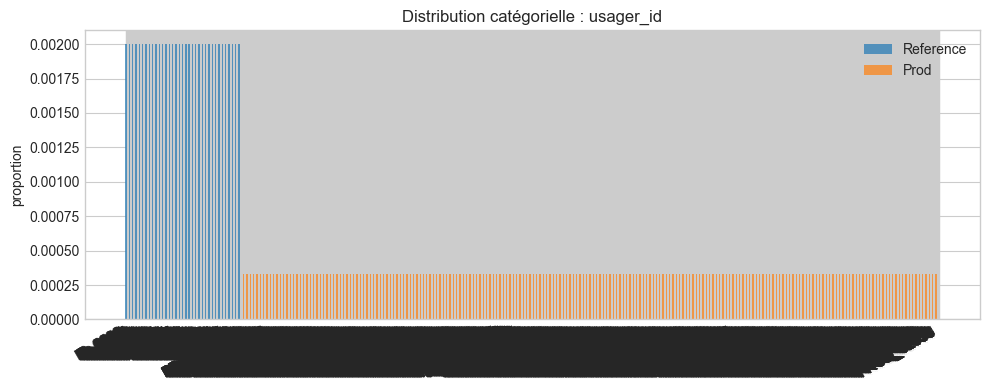

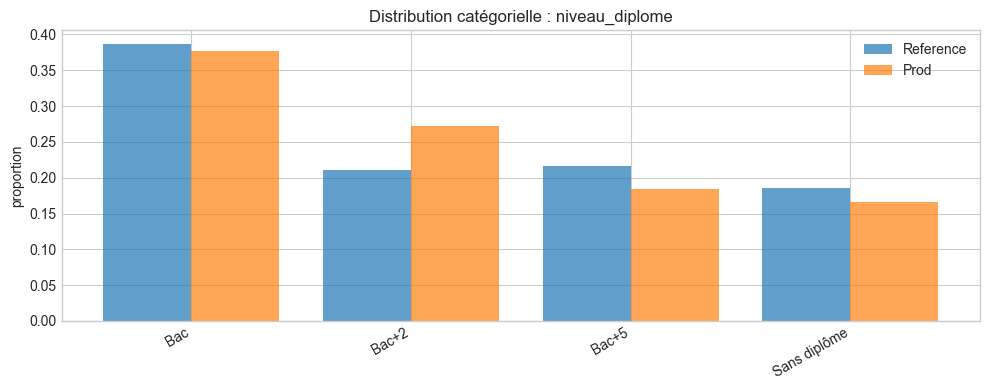

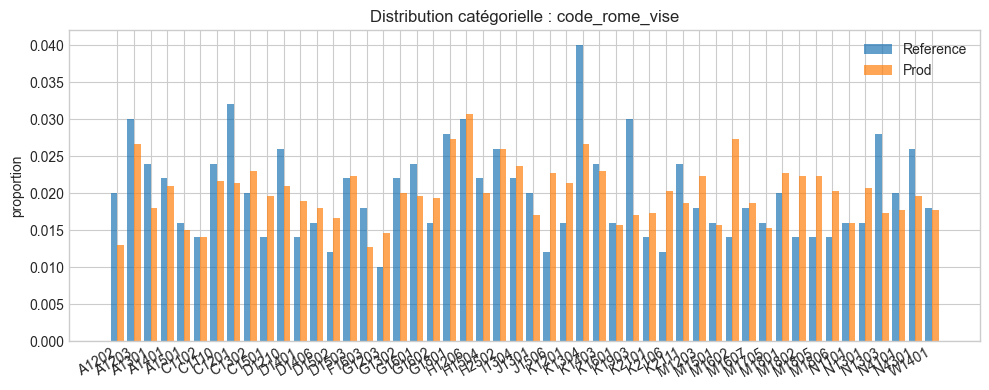

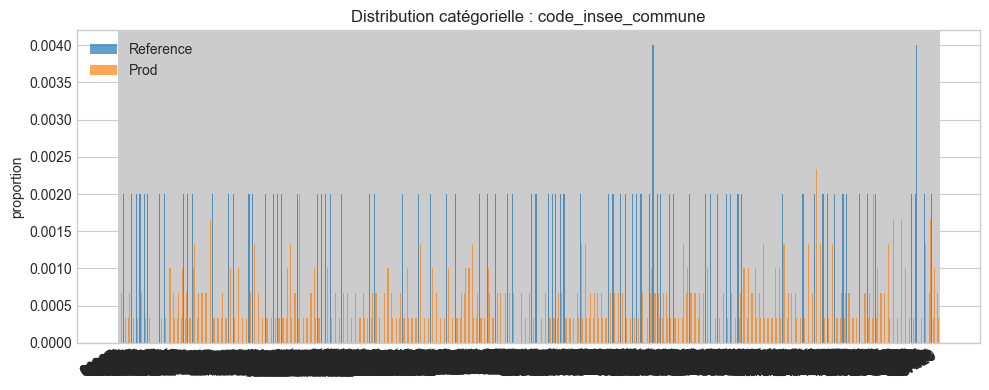

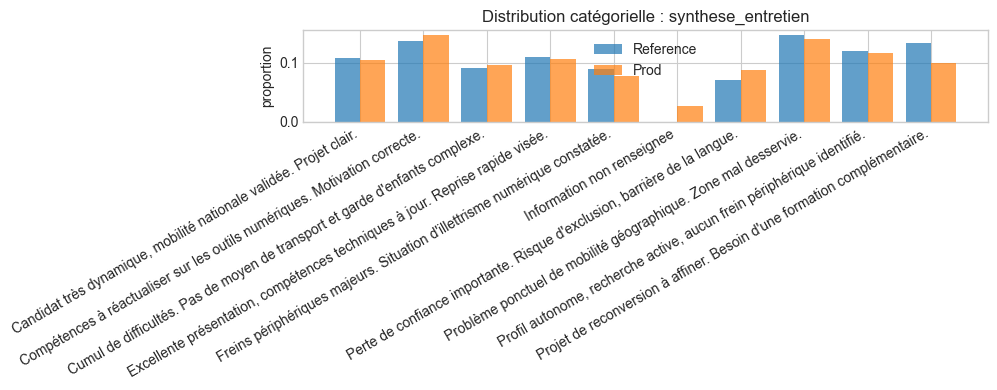

In [12]:
# --- 2) Comparaison des variables catégorielles ---
for col in categorical_cols:
    ref_counts = ref[col].dropna().astype(str).value_counts(normalize=True)
    prod_counts = prod[col].dropna().astype(str).value_counts(normalize=True)
    categories = sorted(set(ref_counts.index) | set(prod_counts.index), key=lambda x: str(x))

    ref_prop = ref_counts.reindex(categories, fill_value=0)
    prod_prop = prod_counts.reindex(categories, fill_value=0)

    x = np.arange(len(categories))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x - 0.2, ref_prop.values, width=0.4, alpha=0.7, label="Reference")
    ax.bar(x + 0.2, prod_prop.values, width=0.4, alpha=0.7, label="Prod")
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, ha="right")
    ax.set_ylabel("proportion")
    ax.set_title(f"Distribution catégorielle : {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [14]:
# --- 3) Résumé quantitatif pour repérer les écarts importants ---
summary = []
for col in numeric_cols:
    ref_vals = ref[col].dropna()
    prod_vals = prod[col].dropna()
    summary.append({
        "feature": col,
        "ref_mean": round(ref_vals.mean(), 3),
        "prod_mean": round(prod_vals.mean(), 3),
        "ref_median": round(ref_vals.median(), 3),
        "prod_median": round(prod_vals.median(), 3),
        "ref_std": round(ref_vals.std(), 3),
        "prod_std": round(prod_vals.std(), 3),
        "missing_ref": round(ref[col].isna().mean(), 3),
        "missing_prod": round(prod[col].isna().mean(), 3),
    })

summary_df = pd.DataFrame(summary)
print("\nRésumé descriptif des variables numériques :")
print(summary_df.to_string(index=False))

# --- 4) Features à examiner en premier ---
priority = ["int_rate", "revol_util", "annual_inc", "delinq_2yrs", "dti", "installment"]
print("\nColonnes à prioriser pour l'investigation :")
print([c for c in priority if c in numeric_cols])


Résumé descriptif des variables numériques :
             feature  ref_mean  prod_mean  ref_median  prod_median  ref_std  prod_std  missing_ref  missing_prod
                 age    40.833     41.561        41.5         42.0   13.374    12.886        0.044           0.0
anciennete_poste_ans     2.982      2.804         1.9          1.9    3.120     2.859        0.000           0.0
     est_allocataire     0.579      0.635         1.0          1.0    0.494     0.482        0.012           0.0
 nationalite_hors_ue     0.112      0.119         0.0          0.0    0.316     0.323        0.000           0.0
classe_retour_emploi     0.806      0.806         1.0          1.0    0.719     0.721        0.000           0.0

Colonnes à prioriser pour l'investigation :
[]


## Détection statistique — PSI · KS · Chi²

In [15]:
import sys

sys.path.append(str(root))

from src.drift_detection import PSI_DRIFT, PSI_STABLE, drift_report

ALPHA = 0.05  # seuil de significativité, côté analyse

In [16]:
report = drift_report(ref, prod, numeric_cols, categorical_cols)

print(f"{len(report)} features testées "
      f"({len(numeric_cols)} numériques, {len(categorical_cols)} catégorielles)")

display(report.style
        .format({"psi": "{:.3f}", "ks_pvalue": "{:.2e}", "chi2_pvalue": "{:.2e}"})
        .background_gradient(subset=["psi"], cmap="OrRd"))

10 features testées (5 numériques, 5 catégorielles)


,type,psi,ks_pvalue,chi2_pvalue,verdict
feature,,,,,
usager_id,categorielle,13.367,nan,1.00e+00,dérive
code_insee_commune,categorielle,8.133,nan,1.00e+00,dérive
synthese_entretien,categorielle,0.292,nan,2.80e-02,dérive
code_rome_vise,categorielle,0.079,nan,9.80e-01,stable
niveau_diplome,categorielle,0.023,nan,2.59e-02,stable
age,numerique,0.021,1.34e-01,nan,stable
anciennete_poste_ans,numerique,0.015,7.85e-01,nan,stable
classe_retour_emploi,numerique,0.000,1.00e+00,nan,stable
est_allocataire,numerique,0.000,1.38e-01,nan,stable


In [17]:
# --- Correction des tests multiples (Holm-Bonferroni) ---
# Sur N features à alpha = 0.05, P(au moins un faux positif) = 1 - 0.95**N
# (~58 % pour 17 features). Sans correction, "tout dérive" est garanti.
# Fonction PURE : elle renvoie une copie enrichie, ne mute pas `report`.
# La cellule d'export peut donc la rappeler seule, dans n'importe quel ordre.


def enrich_report(report: pd.DataFrame, alpha: float = ALPHA) -> pd.DataFrame:
    enriched = report.copy()
    enriched["p_value"] = enriched["ks_pvalue"].fillna(enriched["chi2_pvalue"])

    ordered = enriched["p_value"].dropna().sort_values()
    n_tests, significant, rejecting = len(ordered), {}, True
    for rank, (feature, p) in enumerate(ordered.items()):
        rejecting = rejecting and (p <= alpha / (n_tests - rank))
        significant[feature] = rejecting  # dès qu'un test échoue, les suivants aussi
    enriched["signif_holm"] = pd.Series(significant).reindex(enriched.index).fillna(False)

    def commentaire(row: pd.Series) -> str:
        """L'ampleur commande, la p-value confirme."""
        if row["verdict"] == "stable":
            return ("significativité portée par la taille d'échantillon, ampleur faible"
                    if row["signif_holm"] else "aucun signal")
        if row["type"] == "numerique":
            mean_ref = ref[row.name].mean()
            if mean_ref:
                shift = 100 * (prod[row.name].mean() - mean_ref) / abs(mean_ref)
                return f"signaux concordants, moyenne {shift:+.1f} %"
        return "signaux concordants, modalités redistribuées"

    enriched["commentaire"] = enriched.apply(commentaire, axis=1)
    return enriched


enriched = enrich_report(report)
print(f"significatives brut : {int((enriched['p_value'] < ALPHA).sum())} | "
      f"après Holm : {int(enriched['signif_holm'].sum())}")

display(enriched[["type", "psi", "p_value", "signif_holm", "verdict", "commentaire"]]
        .style.format({"psi": "{:.3f}", "p_value": "{:.2e}"}))

significatives brut : 2 | après Holm : 0


,type,psi,p_value,signif_holm,verdict,commentaire
feature,,,,,,
usager_id,categorielle,13.367,1.00e+00,False,dérive,"signaux concordants, modalités redistribuées"
code_insee_commune,categorielle,8.133,1.00e+00,False,dérive,"signaux concordants, modalités redistribuées"
synthese_entretien,categorielle,0.292,2.80e-02,False,dérive,"signaux concordants, modalités redistribuées"
code_rome_vise,categorielle,0.079,9.80e-01,False,stable,aucun signal
niveau_diplome,categorielle,0.023,2.59e-02,False,stable,aucun signal
age,numerique,0.021,1.34e-01,False,stable,aucun signal
anciennete_poste_ans,numerique,0.015,7.85e-01,False,stable,aucun signal
classe_retour_emploi,numerique,0.000,1.00e+00,False,stable,aucun signal
est_allocataire,numerique,0.000,1.38e-01,False,stable,aucun signal


In [18]:
# --- Export du tableau de synthèse : drift_summary.md ---
# On ré-enrichit ici : la cellule est autonome, elle ne dépend que de `report`.
enriched = enrich_report(report)

export = enriched.reset_index()[
    ["feature", "type", "psi", "p_value", "signif_holm", "verdict", "commentaire"]
].rename(columns={"psi": "PSI", "p_value": "p-value", "signif_holm": "signif. (Holm)"})
export["PSI"] = export["PSI"].round(3)
export["p-value"] = export["p-value"].map(lambda p: f"{p:.2e}" if pd.notna(p) else "—")


def to_markdown_table(df: pd.DataFrame) -> str:
    """Table markdown sans dépendance : `DataFrame.to_markdown` exige `tabulate`,
    qui n'est pas garanti dans l'environnement du correcteur."""
    header = "| " + " | ".join(map(str, df.columns)) + " |"
    separator = "|" + "|".join(["---"] * len(df.columns)) + "|"
    rows = ["| " + " | ".join(map(str, row)) + " |" for row in df.astype(str).to_numpy()]
    return "\n".join([header, separator, *rows])


top = enriched.index[enriched["psi"] > PSI_STABLE][:3].tolist()
header = f"""# Synthèse de détection de dérive — M6-B1

Référence : `reference_set.csv` ({len(ref)} lignes) · Production : `prod_3months.csv` ({len(prod)} lignes)
Features testées : {len(enriched)} ({len(numeric_cols)} numériques, {len(categorical_cols)} catégorielles) — exhaustif.
Seuils PSI (repères conventionnels, pas des frontières) : < {PSI_STABLE} stable · {PSI_STABLE}-{PSI_DRIFT} suspect · > {PSI_DRIFT} dérive.
Tests multiples corrigés par Holm-Bonferroni à alpha = {ALPHA}.
Calculs : `src/drift_detection.py`, couvert par `tests/`.

"""
footer = f"""

## Synthèse globale

{int((enriched["psi"] > PSI_DRIFT).sum())} feature(s) au-delà de PSI {PSI_DRIFT}, {int(enriched["psi"].between(PSI_STABLE, PSI_DRIFT).sum())} en zone suspecte.
Features les plus déplacées : {", ".join(f"`{f}`" for f in top) or "aucune"}.

_(2-3 lignes d'interprétation métier à rédiger ici.)_

> Un chiffre n'est pas un verdict, un verdict n'est pas un diagnostic.
"""
(root / "drift_summary.md").write_text(header + to_markdown_table(export) + footer, encoding="utf-8")
print(to_markdown_table(export))

| feature | type | PSI | p-value | signif. (Holm) | verdict | commentaire |
|---|---|---|---|---|---|---|
| usager_id | categorielle | 13.367 | 1.00e+00 | False | dérive | signaux concordants, modalités redistribuées |
| code_insee_commune | categorielle | 8.133 | 1.00e+00 | False | dérive | signaux concordants, modalités redistribuées |
| synthese_entretien | categorielle | 0.292 | 2.80e-02 | False | dérive | signaux concordants, modalités redistribuées |
| code_rome_vise | categorielle | 0.079 | 9.80e-01 | False | stable | aucun signal |
| niveau_diplome | categorielle | 0.023 | 2.59e-02 | False | stable | aucun signal |
| age | numerique | 0.021 | 1.34e-01 | False | stable | aucun signal |
| anciennete_poste_ans | numerique | 0.015 | 7.85e-01 | False | stable | aucun signal |
| classe_retour_emploi | numerique | 0.0 | 1.00e+00 | False | stable | aucun signal |
| est_allocataire | numerique | 0.0 | 1.38e-01 | False | stable | aucun signal |
| nationalite_hors_ue | numerique | 0.0 | 1

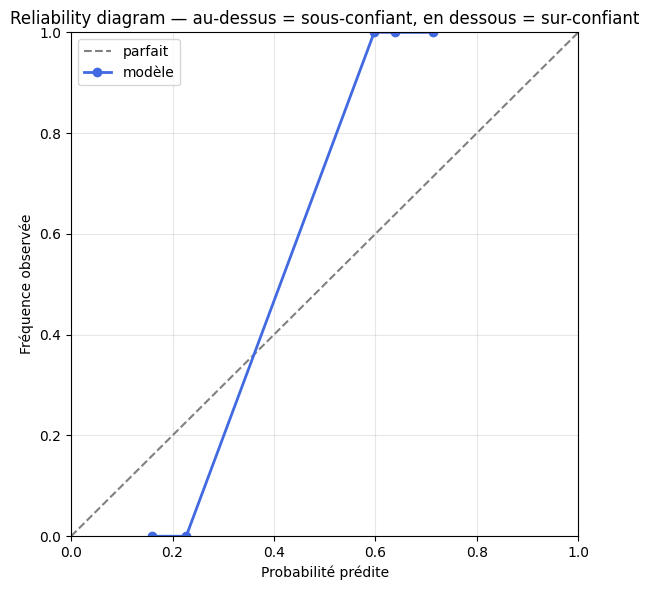

Brier score = 0.0501   ECE = 0.2098
 bin     conf  acc  count       gap
   2 0.159372  0.0   1805 -0.159372
   3 0.226957  0.0    649 -0.226957
   6 0.597641  1.0     27  0.402359
   7 0.639293  1.0    472  0.360707
   8 0.713651  1.0     47  0.286349

Verdict : le modèle est sous-confiant.


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------
# 1) Charger les prédictions
# ---------------------------
root_candidates = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
]

csv_path = None
for root in root_candidates:
    candidate = root / "data" / "predictions_log.csv"
    if candidate.exists():
        csv_path = candidate
        break

if csv_path is None:
    raise FileNotFoundError("Fichier introuvable : data/predictions_log.csv")

df = pd.read_csv(csv_path)

required_cols = {"proba_default", "true_label"}
missing = required_cols - set(df.columns)

if missing:
    raise ValueError(f"Colonnes manquantes : {sorted(missing)}")

p_all = df["proba_default"].clip(0, 1).astype(float)
y_all = df["true_label"].astype(int)

# ---------------------------
# 2) Score de calibration
# ---------------------------
# Brier score : moyenne de (y - p)^2
brier_score = ((y_all - p_all) ** 2).mean()

# ---------------------------
# 3) Reliability diagram
# ---------------------------
def reliability(proba: pd.Series, y_true: pd.Series, n_bins: int = 10) -> tuple[pd.DataFrame, float, float]:
    """Retourne (table par bin, brier_score, ece).

    Bins de largeur fixe 0.1. `gap = acc - conf` : positif = sous-confiant,
    négatif = sur-confiant.
    """
    proba = pd.Series(proba).clip(0, 1).astype(float).reset_index(drop=True)
    y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
    brier = float(((y_true - proba) ** 2).mean())

    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(proba, bins[:-1], right=False)
    rows = []
    for i in range(1, n_bins + 1):
        mask = bin_ids == i
        if not mask.any():
            continue
        conf, acc = proba[mask].mean(), y_true[mask].mean()
        rows.append({"bin": i, "conf": conf, "acc": acc,
                     "count": int(mask.sum()), "gap": acc - conf})

    table = pd.DataFrame(rows)
    ece = float(((table["count"] / len(proba)) * table["gap"].abs()).sum())
    return table, brier, ece


def verdict_calibration(table: pd.DataFrame, ece: float) -> str:
    """Sur-confiant / sous-confiant / bien calibré."""
    mean_gap = table["gap"].mean()
    if ece < 0.05 and abs(mean_gap) < 0.05:
        return "bien calibré"
    return "sur-confiant" if mean_gap < 0 else "sous-confiant"


cal, brier_score, ece_global = reliability(p_all, y_all)

# ---------------------------
# 4) Graphe
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.5, label="parfait")
ax.plot(cal["conf"], cal["acc"], marker="o", linewidth=2, color="royalblue", label="modèle")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Probabilité prédite")
ax.set_ylabel("Fréquence observée")
ax.set_title("Reliability diagram — au-dessus = sous-confiant, en dessous = sur-confiant")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# ---------------------------
# 5) Interprétation
# ---------------------------
# Cas 1 : points au-dessus de la diagonale => sous-confiant
# Cas 2 : points en dessous de la diagonale => sur-confiant
# Cas 3 : points proches de la diagonale => bien calibré

print(f"Brier score = {brier_score:.4f}   ECE = {ece_global:.4f}")
print(cal.to_string(index=False))
print(f"\nVerdict : le modèle est {verdict_calibration(cal, ece_global)}.")

## Performance dans le temps

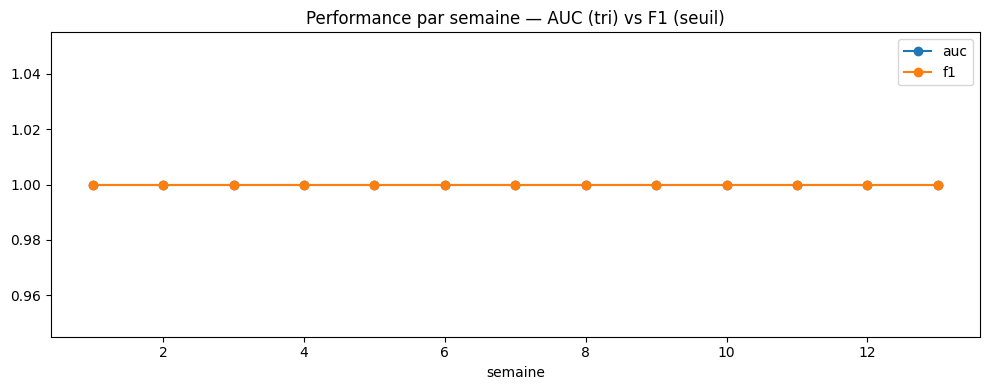

,n,prevalence,auc,f1
semaine,,,,
1,234.0,0.179,1.0,1.0
2,233.0,0.180,1.0,1.0
3,233.0,0.210,1.0,1.0
4,234.0,0.209,1.0,1.0
5,233.0,0.180,1.0,1.0
6,233.0,0.193,1.0,1.0
7,233.0,0.155,1.0,1.0
8,234.0,0.188,1.0,1.0
9,233.0,0.129,1.0,1.0


In [6]:
# --- Axe 2 : pouvoir de tri dans le temps ---
from sklearn.metrics import f1_score, roc_auc_score

logs = df.copy()
logs["timestamp"] = pd.to_datetime(logs["timestamp"])
logs["semaine"] = ((logs["timestamp"] - logs["timestamp"].min()).dt.days // 7) + 1

weekly = logs.groupby("semaine").apply(
    lambda g: pd.Series({
        "n": len(g),
        "prevalence": g["true_label"].mean(),
        "auc": roc_auc_score(g["true_label"], g["proba_default"])
               if g["true_label"].nunique() > 1 else float("nan"),
        "f1": f1_score(g["true_label"], (g["proba_default"] >= 0.5).astype(int),
                       average="macro", zero_division=0),
    }),
    include_groups=False,
)

fig, ax = plt.subplots(figsize=(10, 4))
weekly[["auc", "f1"]].plot(ax=ax, marker="o")
ax.set_title("Performance par semaine — AUC (tri) vs F1 (seuil)")
ax.set_xlabel("semaine")
ax.legend()
plt.tight_layout()
plt.show()

display(weekly.round(3))

In [7]:
# --- Début vs fin de période ---
# L'AUC mesure le tri indépendamment du seuil ; le F1 dépend du seuil ET de la prévalence.
DELTA_AUC_TOLERE = 0.03

debut, fin = weekly.loc[1:4], weekly.loc[9:12]
axe_auc = pd.DataFrame({
    "semaines 1-4": debut[["auc", "f1"]].mean(),
    "semaines 9-12": fin[["auc", "f1"]].mean(),
})
axe_auc["delta"] = axe_auc["semaines 9-12"] - axe_auc["semaines 1-4"]
display(axe_auc.round(3))

delta_auc = axe_auc.loc["auc", "delta"]
auc_stable = abs(delta_auc) < DELTA_AUC_TOLERE
print(f"AUC {'stable' if auc_stable else 'dégradée'} (Δ={delta_auc:+.3f}) — "
      f"{'compatible data drift, à croiser PSI + calibration' if auc_stable else 'investiguer : concept drift ? population ? qualité ?'}")

,semaines 1-4,semaines 9-12,delta
auc,1.0,1.0,0.0
f1,1.0,1.0,0.0


AUC stable (Δ=+0.000) — compatible data drift, à croiser PSI + calibration


---
## 📎 Annexes

### A. Glossaire métier & technique

### B. Sources & bibliographie

- *[Datasets, articles, documentation technique consultés]*

### C. Décisions techniques détaillées

*[Justifications longues qu'on ne met pas dans le corps du notebook pour le garder lisible.]*

### D. Journal de bord

**Pendant la formation**, le journal de bord est tenu **séparément** dans `journal-de-bord.ipynb` (plus pratique pour le rythme journalier).

⚠️ **Pour la certification**, les deux fichiers doivent être **fusionnés en un seul notebook** (cf. fiche descriptive Atlas IA — un cahier électronique unique).

#### Méthode 1 — Script de fusion (recommandée, ~30 secondes)

Un script est fourni à la racine du repo formation : `scripts/merge_for_certif.py`.

```bash
python scripts/merge_for_certif.py mon_notebook.ipynb journal-de-bord.ipynb rendu_certif.ipynb
```

Le script localise automatiquement le titre « D. Journal de bord » dans le notebook principal et y insère les cellules du journal dans l'ordre. Il produit un nouveau fichier sans modifier les sources.

#### Méthode 2 — Fusion manuelle dans JupyterLab (~5 min)

1. Ouvrir les **deux notebooks** côte à côte dans JupyterLab (drag-and-drop dans deux colonnes).
2. Dans le journal : cliquer sur la première cellule « Jour 1 », puis **Maj-clic** sur la dernière pour tout sélectionner sauf l'intro.
3. **Edit > Copy Cells** (`Ctrl/Cmd + Shift + C`).
4. Dans le notebook principal : cliquer sous le titre « D. Journal de bord ».
5. **Edit > Paste Cells Below** (`Ctrl/Cmd + Shift + V`).
6. Vérifier l'ordre chronologique.
7. **Kernel > Restart & Run All** : aucune cellule ne doit casser.
8. Sauvegarder sous un **nouveau nom** (ex : `<prenom>_certif_v1.ipynb`) — ne pas écraser les sources.

#### Vérification finale (les deux méthodes)

- [ ] Le notebook fusionné s'exécute de bout en bout sans erreur.
- [ ] Toutes les images du journal s'affichent (sinon : passer en chemins absolus ou inliner).
- [ ] Aucune référence à des fichiers externes hors du repo (ou alors les inclure dans le ZIP de rendu).
- [ ] Une seule version finale, datée, dans le ZIP envoyé au jury.

⚠️ **Tester la fusion 2-3 jours avant le rendu**, pas le jour J.

#### Export PDF (optionnel, pour la soutenance)

```bash
jupyter nbconvert --to pdf rendu_certif.ipynb
```